# 9장 — 지식 그래프 위의 머신러닝: 입문적 접근

| | |
| --- | --- |
| **책** | Alessandro Negro 외, *Knowledge Graphs and LLMs in Action* (Manning) **9장** |
| **해설 원본** | [09_..._ko_explained.md 열기](../../09_machine_learning_on_knowledge_graphs_a_primer_approach_ko_explained.md) |
| **원서 원문** | [09_....md 열기](../../09_machine_learning_on_knowledge_graphs_a_primer_approach.md) |
| **이 폴더** | [tasks.py](./tasks.py) · [analysis/](./analysis) · [requirements.lock](./requirements.lock) · [Makefile](./Makefile) |
| **원서 저장소** | [alenegro81/.../chapters/ch11 열기](https://github.com/alenegro81/knowledge-graphs-and-llms-in-action/tree/main/chapters/ch11) |
| **리스팅 번호** | **오프셋으로 표현할 수 없다.** `listings/` 디렉터리가 없고 번호 접두사가 붙은 파일도 없다. 책 리스팅 10건 중 8건은 [`analysis/`](./analysis) 의 파이썬 파일 **두 개** 안의 함수·줄 범위에 흩어져 있다(9.7·9.9 는 출력 예시라 저장소에 코드가 없다). 그래서 `study.toml` 이 번호 대신 `path` + `symbol` 로 선언한다 (아래 헬퍼 셀이 출력하는 대조표 참고) |
| **외부 서비스** | **없다.** Neo4j·도커·API 키가 하나도 필요 없다. 근거는 아래 「실행 환경」 절에 있다 |

---

3\~8장은 **지식 그래프를 만드는** 이야기였다. 온톨로지에서 그래프를 세우고, 여러 소스를 통합하고, 비정형 텍스트에서 엔티티를 뽑아 붙였다. 9장은 방향을 튼다. 다 만든 그래프를 **입력으로 받아 예측을 하는** 이야기다. 그래서 이 노트북에는 Cypher 가 한 줄도 없고 `nx.karate_club_graph()` 와 `scikit-learn` 이 있다.

이 장은 4부(9\~12장)의 문을 여는 **입문(primer)** 장이다. 그래서 다루는 방식이 앞 장들과 다르다. 절 셋이 각각 **왜 · 무엇을 · 어떻게** 라는 한 단어짜리 질문에 답하고, 마지막 절에서만 코드가 나온다. 34개 노드짜리 장난감 그래프 하나로 **특징화 → 분류 → 평가 → 특징 재설계 → 군집화** 를 처음부터 끝까지 한 바퀴 돌린다. 규모가 작은 것이 약점이 아니라 의도다 — 알고리즘의 성능이 아니라 **특징을 어떻게 만드느냐가 결과를 좌우한다** 는 것을 보이려면 알고리즘 쪽 변수를 다 지워야 하기 때문이다.

| 절 | 내용 | 이 절이 답하는 질문 | 리스팅 |
| --- | --- | --- | --- |
| 9.1 | 그래프 위의 머신러닝: 왜? — 그래프를 택하는 세 가지 이유 | 왜 굳이 그래프 위에서 ML 을 하나 | — |
| 9.2 | 그래프 위의 머신러닝: 무엇을? — 노드 중심 과제와 그래프 중심 과제 | 그래프 위의 ML 과제에는 무엇이 있나 | — |
| 9.3 | 그래프 위의 머신러닝: 어떻게? — 전용 알고리즘이냐, 특징 공학이냐 | 실제로 어떻게 구현하나 | 9.1\~9.10 |
| 9.3.1 | 노드 분류와 링크 예측 — 특징화부터 로지스틱 회귀까지 | 특징을 어떻게 만들고 무엇이 결과를 바꾸나 | 9.1\~9.9 |
| 9.3.2 | 그래프 분류 — 노드가 아니라 그래프 전체의 특징 | 데이터 점이 그래프일 때는 무엇이 달라지나 | — |
| 9.3.3 | 그래프 군집화 — 변환 없이 그래프를 바로 나누기 | 특징화를 아예 건너뛰는 과제도 있나 | 9.10 |
| — | 실습 9-A · 9-B · 9-C · 요약 | | |

> **한 문장 요약** — 그래프 위의 ML 은 서로 얽힌 데이터를 **노드 분류 · 링크 예측 · 커뮤니티 탐지 · 그래프 분류** 라는 몇 가지 표준 과제로 환원하고, 그 대부분은 그래프를 **특징 벡터로 바꾸는 단계**(featurization)를 거쳐 고전적 ML 알고리즘에 넘기는데 — 같은 로지스틱 회귀에 같은 34노드 그래프를 주고도 특징을 `[차수]` 에서 `[차수, Mr. Hi 이웃 수, Officer 이웃 수]` 로 바꾸는 것만으로 F1 이 **0.43 → 0.93** 으로 뛴다.

### 11장과의 관계 — 9장이 어디까지 하고 11장이 무엇을 더하나

이 장은 [11장(그래프 표현 학습과 GNN)](../../../chapter_11_graph_representation_learning_and_graph_neural_networks/src/ch11/11_chapter_guide.ipynb) 의 **전신** 이다. 두 장이 같은 가라테 클럽 네트워크에 같은 Node2Vec 을 쓰기 때문에 겹쳐 보이지만, 묻는 질문이 다르다.

| | **9장 (이 노트북)** | **11장** |
| --- | --- | --- |
| 특징을 만드는 주체 | **사람** — 차수·이웃 차수를 손으로 고안한다 | **모델** — 인코더가 학습으로 알아낸다 |
| Node2Vec 의 위치 | 손으로 만든 특징과 **비교되는 기준선** 하나 | 얕은 임베딩(shallow embedding)의 **대표 사례**, 그 한계를 해부하는 대상 |
| 이론 틀 | 없음. 과제 분류와 흐름도가 전부 | **인코더–디코더** 라는 통합 틀 |
| 코드의 성격 | 완결된 파이프라인 (특징화 → 학습 → 평가) | `nn.Module` 조각들의 순전파 |
| 이 장의 결론 | 도메인 지식이 담긴 특징이 자율 임베딩을 **이긴다** | 그 수작업이 규모에서 무너지므로 **학습으로 대체** 한다 |
| 학습 프레임워크 | `scikit-learn` (로지스틱 회귀) | `torch` |

핵심 연결은 이렇다. **9장은 "특징 공학이 결정적이다"를 실측으로 증명하고, 11장은 "그래서 그 결정적인 일을 사람이 계속할 수는 없다"로 받는다.** 이 노트북이 `[차수, Mr. Hi 이웃 수, Officer 이웃 수]` 라는 세 칸 벡터를 만들려면 "이 그래프가 두 파벌로 갈라졌고 동종선호가 작동한다"는 사실을 사람이 미리 알아야 했다. 노드가 100만 개이고 관계 종류가 수십 가지인 지식 그래프에서는 그 사전 지식을 매번 확보할 수 없다. 10장이 그 수작업을 **반자동** 으로 밀고, 11장이 **자동** 으로 넘긴다.

이 장은 **이론이 아니라 실측 비교** 가 무게중심이다. 리스팅 열 개 중 둘(9.7 · 9.9)은 코드가 아니라 **출력 표** 이고, 그 두 표를 나란히 놓는 것이 이 장의 결론 그 자체다. 그래서 이 노트북은 세 가지 특징화를 같은 파이프라인에 넣어 같은 지표로 재고, 어느 수치가 재현되고 어느 수치가 실행마다 달라지는지까지 구분해 적었다.


---
## 실행 환경 — 9장은 Neo4j 가 필요 없다

**외부 서비스가 하나도 없다.** 데이터베이스도, 도커 컨테이너도, API 키도, 내려받을 데이터셋도 없다. 근거는 두 가지다.

| 근거 | 확인 방법 |
| --- | --- |
| 책이 직접 밝힌다 | 원문 9.3.1 절: *"For this example, we won't store anything in Neo4j. The network is very small, and it is available out of the box in many network analysis tools"* |
| 저장소 코드가 Neo4j 에 접속하지 않는다 | [`analysis/simple_classification_example.py`](./analysis/simple_classification_example.py) 가 `from util.graphdb_base import GraphDBBase` 를 임포트하지만 **한 번도 인스턴스화하지 않는다.** `GraphDBBase.__init__` 이 `config.ini` 를 읽고 드라이버를 만드는데, 생성자가 호출되지 않으므로 연결도 일어나지 않는다. 임포트만으로 실패하지 않도록 `neo4j` 패키지 자체는 필요한데, 그것은 교재 공용 `base_packages` 에 이미 들어 있다 |

데이터도 내려받지 않는다. 가라테 클럽 네트워크(34개 노드)는 `networkx` 에 **상수로 내장** 되어 있어 `nx.karate_club_graph()` 한 줄이면 끝이다. 이 챕터에는 `data-manifest.toml` 항목이 없다.

### 설치

교재 루트의 `.venv`(Python 3.10) 커널에서 돌아간다. 처음이면 교재 루트에서 [`setup_env.py`](../../../setup_env.py) 를 한 번 실행한다.

```bash
python3 setup_env.py
```

그다음 **이 챕터 폴더에서** 챕터별 의존성을 설치한다. 챕터마다 `requirements.lock` 이 다른 버전을 pin 하므로, 다른 챕터를 돌리다 왔다면 이 장의 `init` 을 다시 돌린다.

```bash
cd "source/Alessandro Negro - Knowledge Graphs and LLMs in Action/chapter_09_machine_learning_on_knowledge_graphs_a_primer_approach/src/ch09"
python tasks.py --list      # 태스크 목록 (업스트림 Makefile 에는 init 하나뿐이다)
python tasks.py init        # requirements.lock 설치
```

### ⚠️ `requirements.lock` 이 불완전하다

[`requirements.lock`](./requirements.lock) 에 적힌 것은 **네 개** 뿐이다.

```text
networkx
matplotlib
numpy
node2vec
```

그런데 [`analysis/simple_classification_example.py`](./analysis/simple_classification_example.py) 는 `sklearn` 과 `pandas` 를 임포트한다. **둘 다 lock 에 없다.** `python tasks.py init` 만 돌린 깨끗한 환경에서는 이 파일이 `ModuleNotFoundError` 로 죽는다. 업스트림 누락이다. 이 저장소의 `.venv` 에는 3\~8장·10\~12장 작업 때문에 둘이 이미 들어 있어 문제가 드러나지 않지만, 새 환경을 만들 사람은 알아 둬야 한다. **업스트림 파일은 고치지 않는다** — 대신 아래 환경 점검 셀이 두 패키지를 함께 검사하고 없으면 무엇을 설치해야 하는지 알려 준다.

| 패키지 | `requirements.lock` | 쓰는 곳 |
| --- | --- | --- |
| `networkx` | ✅ | `karate_club_graph()`, `spring_layout`, `louvain_communities` |
| `matplotlib` | ✅ | 그래프·커뮤니티 그림 |
| `numpy` | ✅ | 라벨 배열, 차수 배열 |
| `node2vec` | ✅ | 책 9.3 의 랜덤 워크 임베딩 (`gensim` 을 함께 끌어온다) |
| `scikit-learn` | ❌ **누락** | 책 9.4\~9.6 의 `StandardScaler` · `LogisticRegressionCV` · `train_test_split` · `precision_recall_fscore_support` · `confusion_matrix` |
| `pandas` | ❌ **누락** | 책 9.6 의 `DataFrame` |
| `neo4j` | ❌ (교재 `base_packages`) | `util.graphdb_base` 임포트만 통과시키기 위해. 연결은 하지 않는다 |
| `pygraphviz` | ❌ (**설치 불필요**) | `simple_classification_example.py` L6 이 `from networkx.drawing.nx_agraph import graphviz_layout` 를 임포트하지만 **한 번도 쓰지 않는다.** `networkx` 가 `pygraphviz` 를 지연 임포트하므로 이 줄만으로는 실패하지 않는다 — 그냥 죽은 임포트다 |

### 실행 시간 감각

| 셀 | 하는 일 | 실측 |
| --- | --- | --- |
| 환경 점검 | import 확인 | 1초 미만 |
| 책 9.1 · 9.6 · 9.8 → 9.9 재현 | 스크립트 전체 실행 (그림 1장 + 학습 + 평가) | **0.9초** |
| 책 9.7 재현 (degree · Node2Vec) | Node2Vec 200 워크 × 길이 30 학습이 대부분 | **약 4초** |
| 책 9.10 Louvain | 그림 5장 (전체 + 커뮤니티 4개) | **3.8초** |
| 실습 9-A | 세 임베딩 비교 | 4초 |
| 실습 9-B | Node2Vec 을 8회 재학습 | **약 15초** — 이 노트북에서 가장 오래 걸린다 |
| 실습 9-C | 노드 8 교차 분석 (계산만) | 1초 미만 |

**전체가 30초 안에 끝난다.** 오래 걸리는 셀도, 건너뛰기 가드가 필요한 셀도 없다. 시간을 잡아먹는 것은 학습이 아니라 `plt.savefig(..., dpi=1000)` 이다 — 리스팅이 SVG·PNG 를 dpi 1000 으로 저장하는데, 그림 한 장당 0.7초쯤 든다.

> **리스팅이 만드는 파일을 저장소에 남기지 않는다.** 책 9.1 과 9.10 은 `plt.savefig("Karate_Graph*.svg"/".png")` 로 그림을 **현재 폴더에 쓴다.** 주피터의 cwd 는 이 챕터 폴더이므로 그대로 돌리면 `src/ch09/` 에 SVG·PNG 가 7쌍 생긴다. 업스트림 파일을 고칠 수는 없으니, 아래 코드 셀들은 실행 중에만 `plt.savefig` 를 임시 폴더로 돌리는 컨텍스트 매니저를 쓴다. `plt.show()` 는 건드리지 않으므로 그림은 노트북에 그대로 인라인으로 뜬다.


In [1]:
"""환경 점검 — 이 셀이 통과하면 이후 모든 셀을 돌릴 수 있다.

9장은 Neo4j·도커·API 키·내려받을 데이터가 하나도 없다. 그래서 검사할 것은
"이 커널에서 필요한 패키지가 임포트되는가" 하나뿐이다.

주의: requirements.lock 이 scikit-learn 과 pandas 를 빠뜨렸다(위 절 참고).
그래서 lock 의 네 개만 보는 것이 아니라 **실제로 임포트되는 것 전부** 를 검사한다.
"""
import importlib
import platform
import warnings
from pathlib import Path

from studykit import config

STUDY = config.load()     # 위로 올라가며 study.toml 을 찾는다
HERE = Path.cwd()         # 주피터는 노트북 폴더를 cwd 로 둔다
REPO_DIR = "ch09"         # 소스 폴더 = 책 장 번호 (업스트림 MEAP 에서는 ch11)
UPSTREAM_DIR = STUDY.upstream_dirs[REPO_DIR]   # "ch11" — study.toml 이 정본이다

assert (HERE / "analysis").is_dir(), f"cwd 가 챕터 폴더가 아니다: {HERE}"

print("교재      :", STUDY.title)
print("파이썬    :", platform.python_version(), "(study.toml 고정:", STUDY.python + ")")
print("작업 폴더 :", HERE.name, " (책 9장 ↔ 업스트림", UPSTREAM_DIR + ")")

# 이 장이 실제로 요구하는 것. 오른쪽 끝의 표시는 requirements.lock 등재 여부다.
REQUIRED = {
    "networkx":     ("karate_club_graph() · spring_layout · louvain_communities", True),
    "matplotlib":   ("그래프·커뮤니티 그림", True),
    "numpy":        ("라벨·차수 배열", True),
    "node2vec":     ("책 9.3 의 랜덤 워크 임베딩", True),
    "gensim":       ("node2vec 내부의 Word2Vec", False),
    "sklearn":      ("책 9.4~9.6 의 스케일러·로지스틱 회귀·분할·지표", False),
    "pandas":       ("책 9.6 의 DataFrame", False),
    "neo4j":        ("util.graphdb_base 임포트 통과용 — 연결은 하지 않는다", False),
}

missing = []
print()
print(f"  {'패키지':<14}{'버전':<14}{'lock':<6}쓰는 곳")
for module_name, (why, in_lock) in REQUIRED.items():
    lock_mark = "✓" if in_lock else "—"
    try:
        module = importlib.import_module(module_name)
    except ImportError:
        missing.append(module_name)
        print(f"  ✗ {module_name:<12}{'없음':<14}{lock_mark:<6}{why}")
    else:
        version = getattr(module, "__version__", "?")
        print(f"  ✓ {module_name:<12}{version:<14}{lock_mark:<6}{why}")

if missing:
    from_lock = [m for m in missing if REQUIRED[m][1]]
    extra = [m for m in missing if not REQUIRED[m][1]]
    hint = []
    if from_lock:
        hint.append("      python tasks.py init          # requirements.lock 의 " + ", ".join(from_lock))
    if extra:
        pip_names = {"sklearn": "scikit-learn"}
        hint.append("      pip install " + " ".join(pip_names.get(m, m) for m in extra)
                    + "   # requirements.lock 에 없는 것 (업스트림 누락)")
    raise RuntimeError("패키지가 없다: " + ", ".join(missing) + "\n" + "\n".join(hint))

# graphviz_layout 은 저장소 파일이 임포트만 하고 쓰지 않는 죽은 의존이다.
# pygraphviz 가 없어도 이 임포트는 성공한다 — 그 사실을 눈으로 확인해 둔다.
from networkx.drawing.nx_agraph import graphviz_layout  # noqa: F401,E402
try:
    importlib.import_module("pygraphviz")
    pygraphviz_note = "설치됨"
except ImportError:
    pygraphviz_note = "없음 — 그래도 문제없다 (지연 임포트이고, 저장소 코드가 쓰지 않는다)"
print(f"\n  pygraphviz : {pygraphviz_note}")

# 외부 서비스가 없다는 것을 근거와 함께 확인한다.
CLASSIFICATION = HERE / "analysis" / "simple_classification_example.py"
source_text = CLASSIFICATION.read_text(encoding="utf-8")
print("\n  Neo4j 연결 여부 —",
      "GraphDBBase 임포트 있음:" , "GraphDBBase" in source_text, "/",
      "인스턴스화(GraphDBBase() 호출) 있음:", "GraphDBBase(" in source_text)
print("    -> 임포트만 하고 생성자를 부르지 않으므로 드라이버가 만들어지지 않는다."
      " 이 장에 데이터베이스는 없다.")

# 그림·학습 재현성에 관한 설정. 시드 고정의 한계는 실습 9-B 에서 실측한다.
SEED = 0                 # 책 9.3·9.6 이 쓰는 값과 같게 둔다
warnings.filterwarnings("ignore", category=FutureWarning)   # sklearn multi_class 폐기 예고

MEASURED = {}            # 아래 셀들이 실측값을 여기 모으고, 요약 셀이 그대로 인용한다

print("\n준비 완료. 이 장은 Neo4j·도커·API 키·데이터 다운로드가 필요 없다.")


교재      : Knowledge Graphs and LLMs in Action
파이썬    : 3.10.18 (study.toml 고정: 3.10)
작업 폴더 : ch09  (책 9장 ↔ 업스트림 ch11)

  패키지           버전            lock  쓰는 곳
  ✓ networkx    3.4.2         ✓     karate_club_graph() · spring_layout · louvain_communities
  ✓ matplotlib  3.10.9        ✓     그래프·커뮤니티 그림
  ✓ numpy       1.26.4        ✓     라벨·차수 배열


  ✓ node2vec    0.5.0         ✓     책 9.3 의 랜덤 워크 임베딩
  ✓ gensim      4.4.0         —     node2vec 내부의 Word2Vec
  ✓ sklearn     1.7.2         —     책 9.4~9.6 의 스케일러·로지스틱 회귀·분할·지표
  ✓ pandas      2.3.3         —     책 9.6 의 DataFrame
  ✓ neo4j       5.28.4        —     util.graphdb_base 임포트 통과용 — 연결은 하지 않는다

  pygraphviz : 없음 — 그래도 문제없다 (지연 임포트이고, 저장소 코드가 쓰지 않는다)

  Neo4j 연결 여부 — GraphDBBase 임포트 있음: True / 인스턴스화(GraphDBBase() 호출) 있음: False
    -> 임포트만 하고 생성자를 부르지 않으므로 드라이버가 만들어지지 않는다. 이 장에 데이터베이스는 없다.

준비 완료. 이 장은 Neo4j·도커·API 키·데이터 다운로드가 필요 없다.


<교재>/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
"""리스팅 접근 헬퍼 — 이 챕터에는 `listings/` 디렉터리가 없다.

3~8장·10장의 골격은 `listings/` 안의 확장자 없는 Cypher 파일을 번호로 찾아 읽는
cypher.read("9.1") 을 썼다. 9장에는 그것이 통째로 맞지 않는다. 세 가지가 다르다.

  1. `listings/` 폴더가 존재하지 않는다. 코드는 analysis/ 의 파이썬 파일 두 개뿐이고
     파일명에 리스팅 번호가 붙어 있지 않다. 즉 "번호로 파일을 찾는" 경로가 없다.
     (studykit.cypher.listings() 는 '.py' 를 명시적으로 제외하기도 한다.)
  2. 그래서 [mapping.listing_offsets] 에 ch09 를 넣으면 안 된다 — 가리킬 파일이 없다.
  3. 파일 하나가 리스팅 여러 개를 담는다. simple_classification_example.py 한 파일에
     책 9.1~9.6·9.8 이 함수 단위로 흩어져 있다.

그래서 study.toml 의 [mapping.listings.ch09] 은 번호 대신 path + symbol 로 선언한다.

    "9.2" = { source = "repo-file",
              path = "analysis/simple_classification_example.py",
              symbol = "compute_degree_embeddings" }

**위치의 정본은 study.toml 하나이고, 그 선언을 해석하는 일은 공용 리더
`studykit.listing_source` 가 한다.** 이 셀은 대응표도 ast 헬퍼도 들고 있지 않다 —
전에는 같은 표와 같은 파싱 코드를 챕터 노트북마다 복사해 두어서 정본이 이름만
정본이었다. 줄 번호는 어디에도 저장하지 않고 리더가 매번 ast 로 다시 찾는다: 소스가
갱신되면 줄 번호는 조용히 어긋나지만 함수명은 그렇지 않다. 함수 경계와 맞지 않는
조각(책 9.6 = __main__ 블록의 일부)만 예외적으로 start/end 줄 범위로 선언한다.
심볼 · 파일 전체(책 9.10) · 줄 범위(책 9.6)를 구분해 표기하는 일도 리더가 한다
(ListingChunk.whole_file · origin()), 그래서 이 셀에는 그 분기도 없다. 리스팅 제목도
리더가 원서 md 캡션에서 뽑아 주고, 캡션이 유실된 9.5 만 study.toml 이 title 로 채운다.

실행은 저장소 파일을 **한 글자도 고치지 않고** runpy.run_path 로 이 커널 안에서 한다.
tasks.py 로는 별도 프로세스가 되어 학습된 객체를 노트북으로 가져올 수 없고 그림도
창으로 뜬다. 아래 셀들이 그렇게 실행한다.
"""
import contextlib
import tempfile

import matplotlib.pyplot as plt

from studykit import listing_source

CLS = "analysis/simple_classification_example.py"
CLU = "analysis/simple_clustering_example.py"

# 선언된 리스팅 열 건을 책 번호 순서로 한 벌 받아 둔다. 제목·위치·종류가 모두 여기서
# 나온다 — 제목은 리더가 원서 md 의 `Listing N.M` 캡션에서 자동으로 붙이고, 캡션이
# 유실된 번호(이 챕터는 9.5)만 study.toml 의 title 선언을 쓴다. 그래서 이 셀에는
# 제목 표도 없다.
LISTING_ROWS = listing_source.cross_reference(STUDY, REPO_DIR)
TITLES = {row.number: row.title for row in LISTING_ROWS}

# 저장소에 있지만 책 리스팅 번호가 붙지 않은 조각. 파일을 열었을 때 무엇이 책이고
# 무엇이 아닌지 구분하지 못하면 책에 없는 코드를 책 내용으로 오해한다.
NOT_NUMBERED = {
    (CLS, "set_club_colors"):
        "책 9.1 이 함께 싣는 헬퍼. 리스팅 안에 있지만 별도 번호는 없다",
    (CLS, "EvaluateEmbedding"):
        "train·evaluate 를 담은 클래스. 클래스 선언 자체는 책에 실려 있지 않다",
}


def _symbol_chunk(rel_path: str, symbol: str):
    """번호 없는 조각을 읽는다. 공용 리더에 즉석 선언을 넘긴다 (study.toml 밖)."""
    spec = listing_source.parse({"source": "repo-file", "path": rel_path, "symbol": symbol})
    return listing_source.read(spec, HERE)


def show(book_no: str, head: int | None = None) -> None:
    """책 리스팅 원문을 출력한다. head 를 주면 앞부분만 본다."""
    book_no = str(book_no)
    print(f"── 책 Listing {book_no}  {TITLES.get(book_no) or '—'}")
    try:
        chunk = listing_source.chunk_for(STUDY, REPO_DIR, book_no)
    except listing_source.ListingSpecError as exc:
        # 9.7·9.9 처럼 정본이 해설판인 리스팅(출력 예시)이면 여기로 온다.
        print(f"   ({exc})")
        return
    print(f"   ({chunk.origin()})")
    lines = chunk.text.splitlines()
    for line in (lines[:head] if head else lines):
        print("   ", line)
    if head and len(lines) > head:
        print(f"    ... (전체 {len(lines)}줄, head={head} 로 잘랐다)")


def show_symbol(rel_path: str, symbol: str, label: str = "") -> None:
    """책 리스팅 번호가 없는(또는 유실된) 저장소 조각을 보여준다.

    책 9.1 이 함께 싣는 set_club_colors, 그리고 캡션이 유실된 책 9.5(evaluate)를
    본문 흐름에 맞춰 실을 때 쓴다.
    """
    chunk = _symbol_chunk(rel_path, symbol)
    print(f"── {chunk.origin()}" + (f"   — {label}" if label else ""))
    for line in chunk.text.splitlines():
        print("   ", line)


def load_module(rel_path: str, name: str):
    """저장소 파일을 모듈로 임포트한다. `__main__` 블록은 실행되지 않는다.

    스크립트 전체를 돌리고 싶을 때는 runpy.run_path(..., run_name="__main__") 를 쓴다.
    여기서는 함수만 꺼내 쓰기 위해 임포트만 한다 — 원본 파일은 수정하지 않는다.
    """
    import importlib.util

    path = HERE / rel_path
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module


@contextlib.contextmanager
def savefig_to_tmp():
    """실행 중에만 plt.savefig 를 임시 폴더로 돌린다.

    책 9.1 과 9.10 은 그림을 cwd 에 SVG·PNG 로 저장한다. 주피터의 cwd 는 이 챕터
    폴더이므로 그대로 두면 저장소에 파일이 쌓인다. **업스트림 파일은 고치지 않고**
    savefig 만 임시 폴더로 보낸다. plt.show() 는 그대로이므로 그림은 인라인으로 뜬다.
    """
    real_savefig = plt.savefig
    with tempfile.TemporaryDirectory() as tmp:
        written = []

        def redirected(fname, *args, **kwargs):
            target = Path(tmp) / Path(str(fname)).name
            written.append(target.name)
            return real_savefig(target, *args, **kwargs)

        plt.savefig = redirected
        try:
            yield written
        finally:
            plt.savefig = real_savefig


# ---- 책 리스팅 -> 저장소 위치 대조표 (study.toml 선언 그대로) -------------------
# row.note 는 공용 리더가 채운 종류 힌트다 — 심볼명 · "파일 전체"(9.10) ·
# "줄 범위 (함수 경계 아님)"(9.6) · explainer 의 reason(9.7·9.9).
print(f"{'책':<7}{'제목':<58}저장소 위치")
for row in LISTING_ROWS:
    where = f"{row.where}  {row.note}" if row.note else row.where
    title = row.title or "— (원서 캡션 없음: study.toml 에 title 선언이 필요하다)"
    print(f"{row.number:<7}{title:<58}{where}")

print("\n책 리스팅 번호가 붙지 않은 저장소 코드:")
for (rel_path, symbol), why in NOT_NUMBERED.items():
    chunk = _symbol_chunk(rel_path, symbol)
    print(f"    {chunk.path.name}  L{chunk.start:>3}-L{chunk.end:<4} {symbol:<20} {why}")

print("\n⚠️  책 9.5 는 원서 md 에서 캡션이 유실됐다 (위치·제목을 study.toml 이 선언해 위 표에 있다)")
print("  원서 원문 md 에는 'Listing 9.5' 라는 문자열이 없다. 9.4 다음이 9.6 이다.")
print("  그러나 9.4(train) 와 9.6(전체 과정) 사이에 캡션 없는 코드 블록이 하나 있고,")
print("  그 내용이 EvaluateEmbedding.evaluate 와 같다. PDF→md 변환에서 캡션 줄이")
print("  유실된 것이다 — 해설판은 이를 '리스팅 9.5 평가 함수' 로 복원해 실었다.")
print("  게이트(book_listings)는 원문 문자열만 보므로 9.5 를 요구하지 않는다.")
print("  이 노트북은 그 코드를 9.4 와 나란히 보여 준다 (책 9.6 이 호출하는 짝이므로).")

print("\n실행 방법:")
print("    python tasks.py init                              # 의존성 설치 (유일한 Makefile 타깃)")
print("    python analysis/simple_classification_example.py  # 책 9.1·9.6·9.8 -> 9.9 출력")
print("    python analysis/simple_clustering_example.py      # 책 9.10")
print("  이 노트북은 결과 객체를 다시 쓰기 위해 runpy 로 커널 안에서 직접 실행한다.")


책      제목                                                        저장소 위치
9.1    Creating and drawing a karate club network                analysis/simple_classification_example.py  L80-L88  draw_and_save_graph_picture
9.2    Representing each node by its degree                      analysis/simple_classification_example.py  L60-L64  compute_degree_embeddings
9.3    Using Node2Vec as an embedding technique                  analysis/simple_classification_example.py  L74-L78  compute_complex_embeddings
9.4    Training function                                         analysis/simple_classification_example.py  L25-L33  EvaluateEmbedding.train
9.5    Evaluation function                                       analysis/simple_classification_example.py  L35-L49  EvaluateEmbedding.evaluate
9.6    The full node classification process                      analysis/simple_classification_example.py  L96-L112  줄 범위 (함수 경계 아님)
9.7    Results for the two embeddings                            해설판 본문  book

---
### 9.1 그래프 위의 머신러닝: 왜? — 그래프를 택하는 세 가지 이유

이 장이 처음 답해야 하는 질문은 "**왜 굳이 그래프인가**"다. 지금까지 3\~8장에서 공들여 지식 그래프를 세웠는데, 그 위에서 머신러닝을 하는 것이 표를 만들어 기존 알고리즘에 넣는 것보다 왜 나은가. 해설판은 이유를 세 가지로 정리한다.

| 이유 | 무슨 말인가 | 이 장에서 어떻게 나타나나 |
| --- | --- | --- |
| **데이터 표현**(data representation) | 현실 데이터는 행렬·텐서·시퀀스·시계열로 형태가 제각각인데, 그래프는 그 전부를 담을 수 있는 **보편적 데이터 표현** 이다 | 34명의 사교 관계라는 비정형 관측을 노드 34개·엣지 78개로 담는다 |
| **문제 모델링**(problem modeling) | 겉보기에 전혀 달라 보이는 문제들이 그래프 위의 **작은 계산 과제 집합** 으로 수렴한다 | 이상 노드 탐지와 환자 약물 추천이 둘 다 **노드 분류**, 추천 생성과 상호작용 식별이 둘 다 **관계 예측** 이다 |
| **데이터 항목 간 의존성**(data item dependency) | 전통적 ML 은 데이터가 **i.i.d.** 라고 가정하지만 현실 데이터는 서로 연결돼 있고, 그 관계를 버리면 답이 틀어진다 | 이 장의 가라테 클럽에서 어떤 회원이 어느 파벌로 갈지는 **그 사람의 친구들이 어디로 갔는지** 에 달려 있다 |

세 번째가 이 장 전체의 축이다. "회원 A 가 어느 클럽에 갈까"를 A 의 속성만 보고 맞히려 하면 실패한다 — 실제로 아래에서 A 의 **차수 하나** 만 특징으로 쓰면 F1 이 0.43 에 그친다. A 의 **이웃이 어느 클럽 사람인지** 를 특징에 넣으면 0.93 이 된다. i.i.d. 가정을 버리는 것이 성능으로 돌아온다는 이야기다.

#### GNN 과 LLM 의 상보성 — 이 책 전체의 주제가 9장에 나타나는 방식

해설판은 이 절 끝에서 이 책의 큰 주제로 연결한다. GNN 은 복잡한 **구조적 패턴** 을 탐지하고, LLM 은 **자연어** 를 이해·생성한다. 개인 맞춤 의료를 예로 들면, GNN 이 환자 유사도 네트워크와 생물학적 경로 그래프를 처리하는 동시에 LLM 이 의학 문헌과 임상 지침을 종합해 치료 근거를 의학 용어로 설명한다.

이 책이 계속 쓰는 비유로 옮기면 이렇다. **LLM 은 아는 것이 많지만 없는 사실을 그럴듯하게 지어내는 달변가** 이고, **KG 는 검증된 사실만 적어 둔 사실 대장** 이다. 4부(9\~12장)가 하는 일은 그 사실 대장을 **학습 가능한 형태** 로 바꾸는 것이다. GNN 이 대장에서 숨은 연결을 짚어내고, 달변가가 그것을 사람이 알아듣는 말로 풀어 준다.

> **ML 은 문제가 이끄는 학문이다**(problem-driven). 해설판이 이 절을 닫는 문장이 그것이다. 그래프 위의 ML 이 언제나 최선인 것은 아니고, 이 장이 다룰 시나리오들에서 "화살통 속 가장 좋은 화살"이 된다는 조건부 주장이다. 실제로 아래 실습 9-B 에서 Node2Vec 이라는 정교한 도구가 손으로 만든 세 칸 벡터에 지는 것을 보게 된다 — 도구의 정교함이 아니라 문제와의 궁합이 결과를 정한다.

#### 4부(9\~12장)의 지도

이 장이 4부의 첫 장이므로 앞으로 무엇이 오는지 미리 그려 둔다.

| 장 | 하는 일 | 특징을 만드는 주체 |
| --- | --- | --- |
| **9장 (이 노트북)** | KG 위 ML 의 기본 개념과 동기. 왜 그래프 기반 접근이 현실의 의존 관계를 더 잘 반영하나 | **사람** (손으로) |
| 10장 ([`ch10`](../../../chapter_10_graph_feature_engineering_manual_and_semiautomated_approaches/src/ch10)) | 수동·반자동 특징 공학. 그래프 지표와 구조적 패턴을 어떻게 포착하나 | 사람 + 그래프 알고리즘 |
| 11장 ([`ch11`](../../../chapter_11_graph_representation_learning_and_graph_neural_networks/src/ch11/11_chapter_guide.ipynb)) | GNN 이 그래프 구조로부터 최적 표현을 **자동 학습** 하는 방법 | **모델** |
| 12장 ([`ch12`](../../../chapter_12_node_classification_and_link_prediction_with_gnns/src/ch12)) | 실제 사례 두 개(노드 분류·링크 예측)로 실행. 해석 가능성을 유지하며 비즈니스 문제를 푸는 방법 | 모델 (실제 데이터로 학습) |

해설판이 짚는 흥미로운 점 하나 — **표현 학습 기법의 상당수가 현대 언어 모델의 접근과 닮아 있다.** 이 평행선은 이 장의 Node2Vec 에서 이미 드러난다. `window`·`batch_words`·`min_count` 같은 인자 이름이 전부 Word2Vec 에서 왔다.


---
### 9.2 그래프 위의 머신러닝: 무엇을? — 노드 중심 과제와 그래프 중심 과제

9.1 절이 "왜"에 답했으니 이제 "**무엇을**"이다. 고전적 ML 은 보통 **지도(supervised) / 비지도(unsupervised)** 로 나눈다. 데이터에 라벨이 일부 붙어 있고 나머지를 맞히는 것이 지도(스팸 필터), 라벨이 전혀 없이 패턴만 뽑는 것이 비지도(군집화)다.

그래프 위의 ML 도 이 구분이 **유효하기는 하다.** 노드 분류는 지도 쪽, 커뮤니티 탐지는 비지도 쪽이다. 다만 해설판은 이 잣대가 **가장 유용한 잣대는 아니라고** 말한다. 뒤에 나오듯 노드 분류는 지도라고 딱 부르기도 어렵다. 그래서 그래프 위의 ML 과제는 보통 **입력이 그래프 하나인가 여러 개인가** 로 나눈다.

| 범주 | 데이터셋의 모양 | 데이터 점은 무엇인가 | 이 장의 과제 |
| --- | --- | --- | --- |
| **노드 중심 과제**(node-focused) | 전체가 **하나의 그래프** | **노드와 관계** | 9.2.1 노드 분류 · 9.2.2 링크 예측 · 9.2.3 커뮤니티 탐지 |
| **그래프 중심 과제**(graph-focused) | **여러 그래프의 집합** | **그래프 하나 전체** | 9.2.4 그래프 분류 |

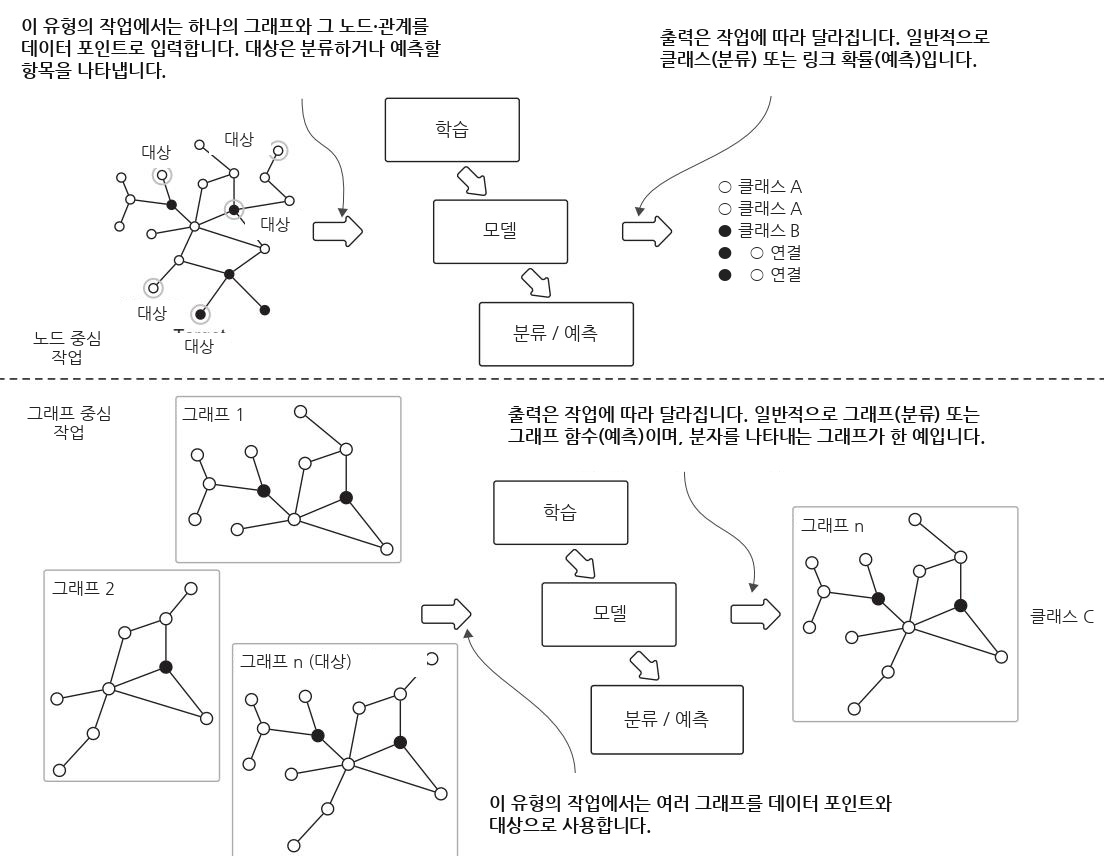

*그림 9.1 — 노드 중심 과제(위)와 그래프 중심 과제(아래)를, 훈련과 예측 단계에서 각각 기대되는 입력·출력의 관점으로 나타낸 것. 위쪽에서는 그래프 **하나** 가 들어가고 그 안의 Target 노드들에 대해 클래스나 링크 확률이 나온다. 아래쪽에서는 Graph 1·2·…·n 이 각각 데이터 점으로 들어가고 그래프 하나에 클래스 하나가 나온다. 이 노트북이 실제로 실행하는 것은 전부 **위쪽**(노드 중심)이다 — 34노드 그래프 하나로 노드 분류와 커뮤니티 탐지를 한다.*

---

#### 9.2.1 노드 분류 — 개별 노드에 라벨을 붙이는 과제

수백만 사용자를 거느린 소셜 네트워크에 봇이 섞여 있다고 하자. 손으로 전부 식별하는 것은 불가능하고, **손으로 라벨을 붙인 소수의 예시** 만으로 나머지를 봇/정상으로 가르는 모델을 원한다. 이것이 노드 분류의 전형이다.

형식적으로는 이렇다. 그래프의 노드 집합 $V$ 안에서 라벨 없는 노드 $u$ 의 라벨 $y_u$ 를 예측하는데, 주어진 것은 $V$ 의 작은 부분집합인 훈련 노드 집합 $V_{\mathrm{train}}$ 위의 알려진 라벨뿐이다.

$$y_{u}, \quad V_{\mathrm{train}}$$

| 기호 | 뜻 | 이 장의 가라테 클럽에서 |
| --- | --- | --- |
| $V$ | 그래프의 **노드 전체 집합** | 클럽 회원 34명 |
| $u$ | 라벨이 아직 없는 **개별 노드** | 어느 파벌로 갈지 모르는 회원 |
| $y_u$ | 노드 $u$ 에 대해 예측하려는 **라벨** | `0`(Mr. Hi 쪽) 또는 `1`(Officer 쪽) |
| $V_{\mathrm{train}}$ | 정답 라벨이 알려진 $V$ 의 **작은 부분집합** | `train_test_split(test_size=0.4)` 이 남긴 20명 |

노드 분류의 다른 예로는 인터랙톰에서 단백질의 기능을 분류하는 일, 하이퍼링크나 인용 그래프로 문서의 주제를 분류하는 일이 있다.

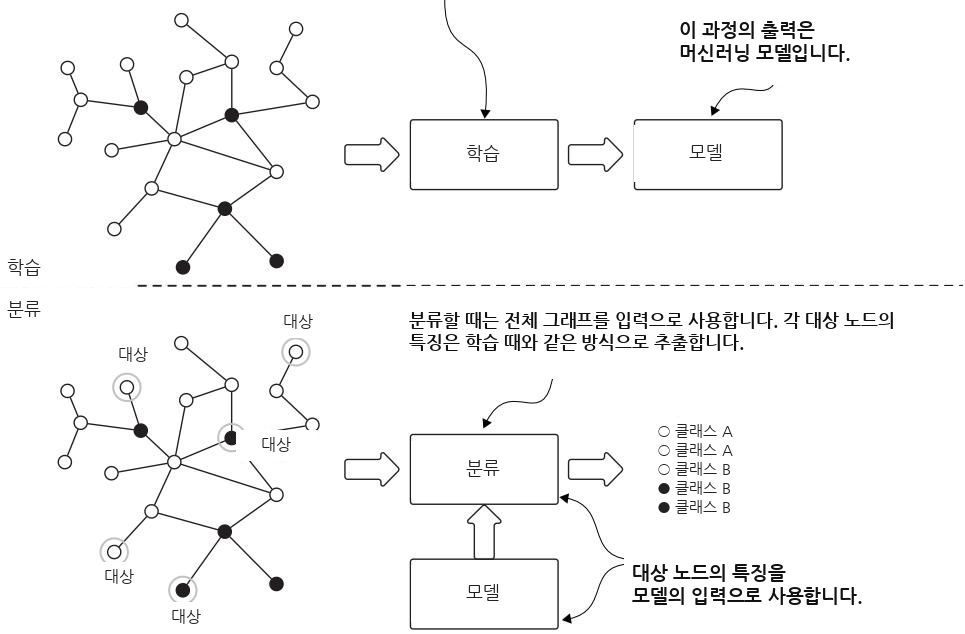

*그림 9.2 — 노드 분류의 전형적인 흐름. 많은 지도 ML 과제처럼 **훈련** 과 **예측**(여기서는 분류되지 않은 노드를 분류하는 일) 두 단계를 가진다. 아래쪽 그림의 주석 "During classification, the full graph is used as input. For each target node, features are extracted using the same approach used during the training" 이 이 장에서 가장 중요한 제약이다 — 특징화는 훈련과 예측에서 **같아야** 한다. 아래 책 9.4·9.5 가 `self.scaler` 를 재사용하는 이유가 정확히 이것이다.*

##### 왜 이것이 표준 지도 분류의 단순한 변형이 아닌가 — i.i.d. 가정의 붕괴

보통 지도 ML 모델을 세울 때 우리는 두 가지를 가정한다. 각 데이터 점이 다른 모든 데이터 점과 **통계적으로 독립** 이고, 데이터 점들이 **동일하게 분포** 한다는 것이다(그래야 보지 못한 데이터에도 일반화된다). 노드 분류는 이 **i.i.d. 가정을 산산조각 낸다.** i.i.d. 데이터 점들의 집합이 아니라 **서로 얽힌 노드들의 네트워크** 를 모델링하기 때문이다.

그래프 종류마다 이 얽힘이 다른 모양으로 나타난다.

| 패턴 | 뜻 | 어디서 두드러지나 |
| --- | --- | --- |
| **동종선호**(homophily) | 노드가 **비슷한** 것끼리 연결되려 한다. 이웃과 관심사·속성·행동을 공유한다 | 소셜 네트워크. **이 장의 리스팅 9.8 이 정확히 이 성질을 특징으로 만든다** |
| **구조적 등가성**(structural equivalence) | 이웃 **구조** 가 비슷한 노드는 기능적 성질도 비슷하다 | 단백질 상호작용 네트워크 |
| **이종선호**(heterophily) | 노드가 자신과 **다른** 특성의 노드와 연결되기를 선호한다 | 위 둘의 반례. 현실 데이터가 i.i.d. 를 얼마나 자주 어기는지 보여 준다 |

결론은 하나다. **좋은 모델은 노드 자신의 특징과 그 네트워크 관계를 함께 고려해야 한다.** 노드를 독립적인 데이터 점으로 취급하면 그래프에 담긴 관계 정보를 통째로 버리는 것이다.

##### 노드 분류는 지도 학습인가, 비지도 학습인가?

원문이 별도 박스로 다루는데 답이 딱 떨어지지 않아 흥미롭다. 많은 연구자가 노드 분류를 **준지도 학습**(semisupervised)으로 본다. 모델을 훈련할 때 우리는 보통 **라벨 없는 노드(테스트 노드)까지 포함한 전체 그래프** 에 접근할 수 있고, 놓치고 있는 것은 오직 그 노드들의 **라벨** 뿐이기 때문이다. 즉 테스트 노드의 이웃 구조 같은 정보는 훈련 중에 써서 모델을 개선할 수 있다. 라벨 없는 데이터 점이 훈련 중에 아예 관측되지 않는 통상적 지도 학습과 다른 점이다.

다만 함정이 있다. **준지도 학습의 표준 정식화는 i.i.d. 가정을 요구하는데, 노드 분류에서는 그 가정이 성립하지 않는다.** 저자들도 이 정의를 놓고 여전히 고민한다고 솔직히 밝힌다. 그래프 위의 ML 과제가 고전적 범주에 왜 쉽게 들어맞지 않는지를 보여 주는 대목이다.

노드 분류는 한 노드에 여러 라벨을 주는 **다중 라벨 노드 분류**(multilabel node classification)로 확장된다. 이미지 호스팅 플랫폼 [Flickr](https://www.flickr.com) 가 그 예다 — 사용자끼리 팔로우해 네트워크를 이루고, 각 사용자가 여러 관심 그룹을 구독하므로 그 구독 정보가 곧 여러 개의 라벨이 된다. 아직 구독하지 않은 그룹을 예측하는 문제가 다중 라벨 노드 분류다.


---
#### 9.2.2 링크 예측 — 노드 사이의 미래 연결을 맞히는 과제

**링크 예측**(link prediction)은 노드들 사이에 앞으로 생길 법한 연결을 찾아내는 과제다. 연구 논문 데이터베이스([PubMed](https://pubmed.ncbi.nlm.nih.gov), [DBLP](https://dblp.org) 등)로부터 **공저 그래프** 를 만든다고 하자. 저자가 노드이고, 두 저자가 논문을 함께 썼으면 엣지를 놓는다. 링크 예측 과제는 **아직 함께 일해 본 적 없는 저자들 사이의 미래 협업** 을 예측하는 것이다.

현실의 그래프는 엣지가 빠져 있어 불완전한 경우가 많은데, 그 이유는 대개 둘 중 하나다.

| 이유 | 설명 |
| --- | --- |
| **관측되지 않았다** | 연결이 실제로 존재하지만 기록되지 않았거나 — 네트워크의 핵심 인물들이 **일부러 감춰 둔** 것이다 (법 집행·보안 응용이 여기서 나온다) |
| **계속 진화한다** | 그래프가 본래 자라난다. 저자는 새 논문을 쓰면서 언제든 새 협업 관계를 맺는다 |

응용은 무수히 많다 — 친구 추천, 상품 추천, **KG 완성**(completion), 약물 부작용 예측, 관계형 데이터베이스에서 새로운 사실 추론, 단백질-단백질 상호작용 발견, 범죄 정보 분석.

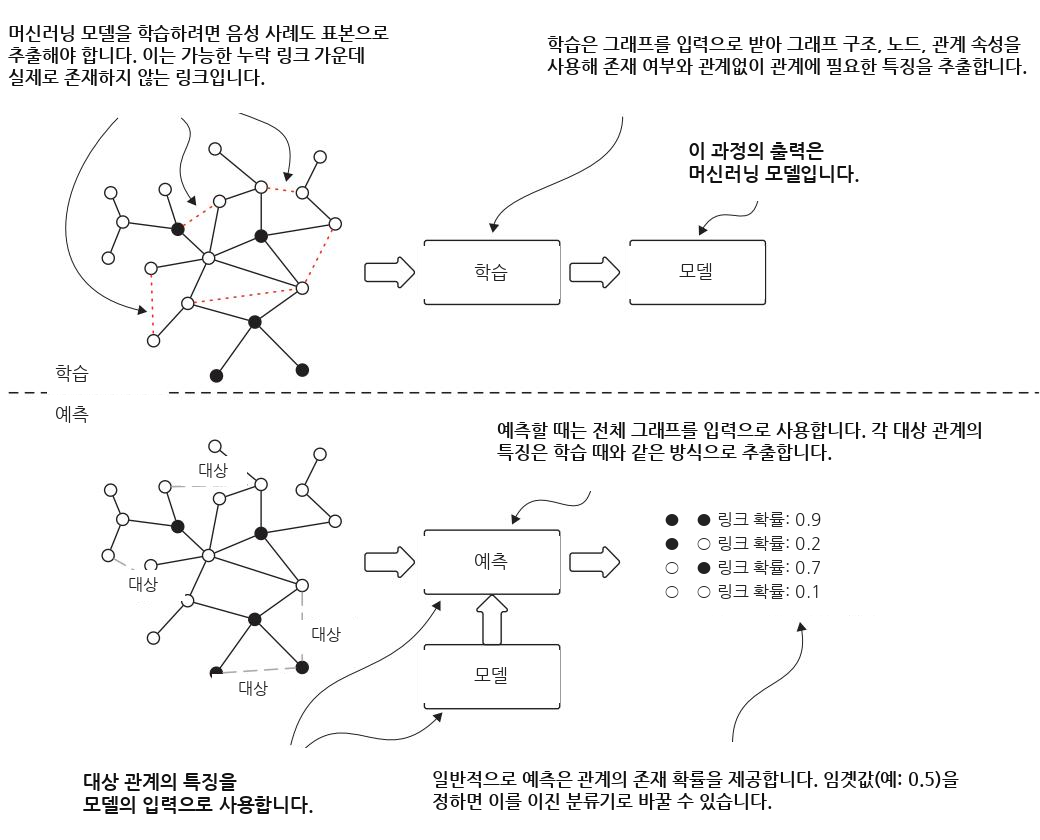

*그림 9.3 — 전형적인 링크 예측 흐름. 훈련 단계는 그래프를 입력으로 받아 어떤 링크가 존재하는지 판별하도록 모델을 훈련하고, 예측 단계는 대상 노드 쌍마다 **그 관계가 존재할 확률** 을 내놓는다. 왼쪽 위 주석이 노드 분류와 결정적으로 다른 점을 짚는다 — **부정 표본을 뽑아야 한다.** 존재하지 않는 링크는 존재하는 링크보다 압도적으로 많으므로 그 전부를 쓸 수 없고 일부를 표집해야 한다. 오른쪽 아래 주석대로 임계값(예: 0.5)을 정하면 확률을 이진 분류기로 바꿀 수 있다.*

##### 링크 예측 과제를 부르는 여러 이름

같은 과제가 응용 분야에 따라 다른 이름으로 불린다.

| 이름 | 초점 |
| --- | --- |
| **링크 예측**(link prediction) | 두 노드 사이에 연결이 **존재하는지**. 관계 유형은 하나로 고정돼 있고 미리 정해져 있다 |
| **관계 예측**(relationship prediction) | 존재뿐 아니라 **관계의 유형까지** 짚어낸다 |
| 그래프 완성(graph completion) · 관계 추론(relational inference) | 같은 과제의 다른 이름 |

이 책은 앞의 두 용어를 서로 바꿔 가며 쓴다. 노드 분류와 마찬가지로 링크 예측도 대개 **준지도** 로 접근한다 — 특정 쌍의 링크가 빠져 있어도 이미 존재하는 연결의 예시와 노드 수준 정보를 함께 써서 잠재 관계를 추론할 수 있기 때문이다.

---

#### 9.2.3 군집화와 커뮤니티 탐지 — 촘촘하게 뭉친 무리를 찾는 과제

공저 그래프를 들여다보면 모두가 서로 협업할 확률이 똑같은 촘촘한 "털 뭉치(hairball)"가 보이지는 않을 것이다. 오히려 연구 분야·소속 기관·지리적 요인으로 묶인 **뚜렷한 노드 군집** 들로 나뉘어 있다. 같은 대학의 두 연구자가 협업할 성향은 멀리 떨어진 동료들끼리보다 높다. 이 자연스러운 군집 행동이 **커뮤니티 탐지**(community detection)의 이론적 토대다.

커뮤니티 탐지는 **네트워크의 나머지 부분과의 연결에 비해 내부 연결이 더 촘촘한 노드 무리** 를 식별한다. 커뮤니티 내부의 **실제 엣지 밀도** 와 **기대 엣지 밀도** 의 차이를 최적화함으로써 **모듈성**(modularity)을 극대화한다. 쉽게 말해 "안쪽은 빽빽하고 바깥과는 성긴" 무리를 최대한 잘 갈라내는 것이다.

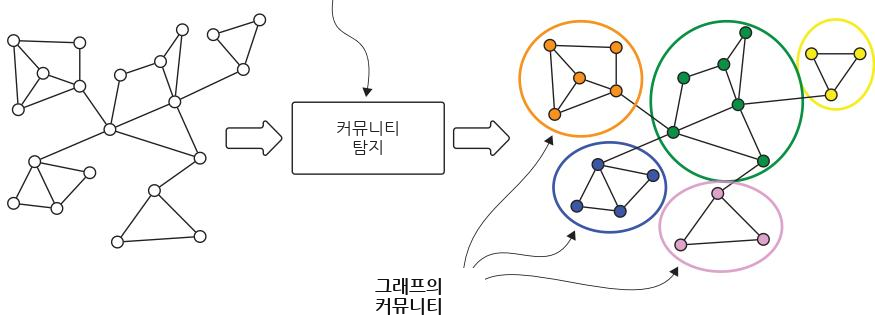

*그림 9.4 — 커뮤니티 탐지의 흐름. 입력은 그래프이고 출력은 **노드와 그룹 사이의 대응 관계**(그림에서 원으로 묶인 부분)다. 앞의 그림 9.2·9.3 과 결정적으로 다른 점이 두 가지 눈에 보인다 — **Training 상자가 없고, 벡터 표현으로 바꾸는 단계도 없다.** 그래프가 그대로 들어가 그룹 배정이 그대로 나온다. 이 성질이 9.3.3 절에서 다시 다뤄지고, 이 노트북은 책 9.10 으로 그것을 실제 실행한다.*

응용은 유전자 상호작용 네트워크에서 기능적 모듈을 식별하는 일부터 금융 거래 네트워크에서 사기 사용자 무리를 탐지하는 일까지 이른다. 특히 강력한 응용 하나는 **그래프 기술(description)과 요약(summarization)** 이다. 촘촘하게 연결된 영역을 찾아내면 네트워크 구성에 대한 **더 높은 수준의 조망** 이 생긴다. 직접 시각화하거나 손으로 전부 분석하기가 불가능한 대규모 그래프에서 특히 값지다.

##### 커뮤니티 탐지 vs 전통적 군집화

네트워크 분석에서 커뮤니티 탐지와 그래프 군집화는 서로 바꿔 쓰이지만, K-means·DBSCAN 같은 전통적 군집화와는 **근본적으로 다르다.**

| | **전통적 군집화** | **그래프 군집화** |
| --- | --- | --- |
| 다루는 데이터 | **벡터 공간 안의 독립적인 데이터 점** | 노드 사이의 **관계** 가 그룹 소속을 결정하는 얽힌 데이터 |
| K-means | $n$ 개 점을 $k$ 개 군집으로. 각 점을 가장 가까운 중심(centroid)에 반복 배정하고 중심을 갱신. **$k$ 를 미리 지정해야 한다** | — |
| DBSCAN | 빽빽하게 모인 점들을 묶고 밀도가 낮은 영역의 점은 이상치로 표시. **군집 개수를 미리 정할 필요가 없다** | — |
| Louvain · LPA | — | **모듈성** 같은 목적함수를 최적화한다. 개수를 미리 정하지 않는다 |

그래프 군집화는 일반적으로 **비지도** 다. 커뮤니티 구조를 찾는 데 라벨이 필요 없다. 다만 **라벨 전파**(label propagation) 같은 일부 접근은 기존 라벨을 반영해 커뮤니티 배정을 이끌 수 있어, 지도와 비지도 사이의 간극을 메운다.

여기까지의 세 과제(노드 분류 · 링크 예측 · 커뮤니티 탐지)는 모두 **노드 중심** 이다. 다음은 그래프 중심 과제다.

---

#### 9.2.4 그래프 분류 — 그래프 하나 전체에 라벨을 붙이는 과제

화학 분자의 독성과 용해도를 예측하는 과제를 생각해 보자. 이런 성질은 개별 원자만으로 결정되는 것이 아니라 **원자들이 어떻게 연결되어 분자를 이루는지** 에서 비롯된다. 각 분자를 하나의 그래프(원자 = 노드, 화학 결합 = 엣지)로 표현하면 **그래프 분류**(graph classification)를 적용해 여러 성질을 동시에 예측할 수 있다.

노드 분류와의 차이가 결정적이다.

| | **노드 분류** (9.2.1) | **그래프 분류** (9.2.4) |
| --- | --- | --- |
| 데이터셋 | 그래프 **하나** | **여러 개의 독립적인 그래프** |
| 데이터 점 | 노드 | **그래프 하나 전체** (예: 분자 하나) |
| 라벨 | 노드마다 | 그래프마다 (예: "이 분자가 독성인가") |
| **i.i.d. 가정** | **깨진다** — 노드끼리 얽혀 있다 | **다시 성립한다** — 그래프끼리는 서로 독립이다 |

마지막 줄이 흥미롭다. 9.2.1 절에서 산산조각 났던 i.i.d. 가정이 그래프 수준에서 되살아난다.

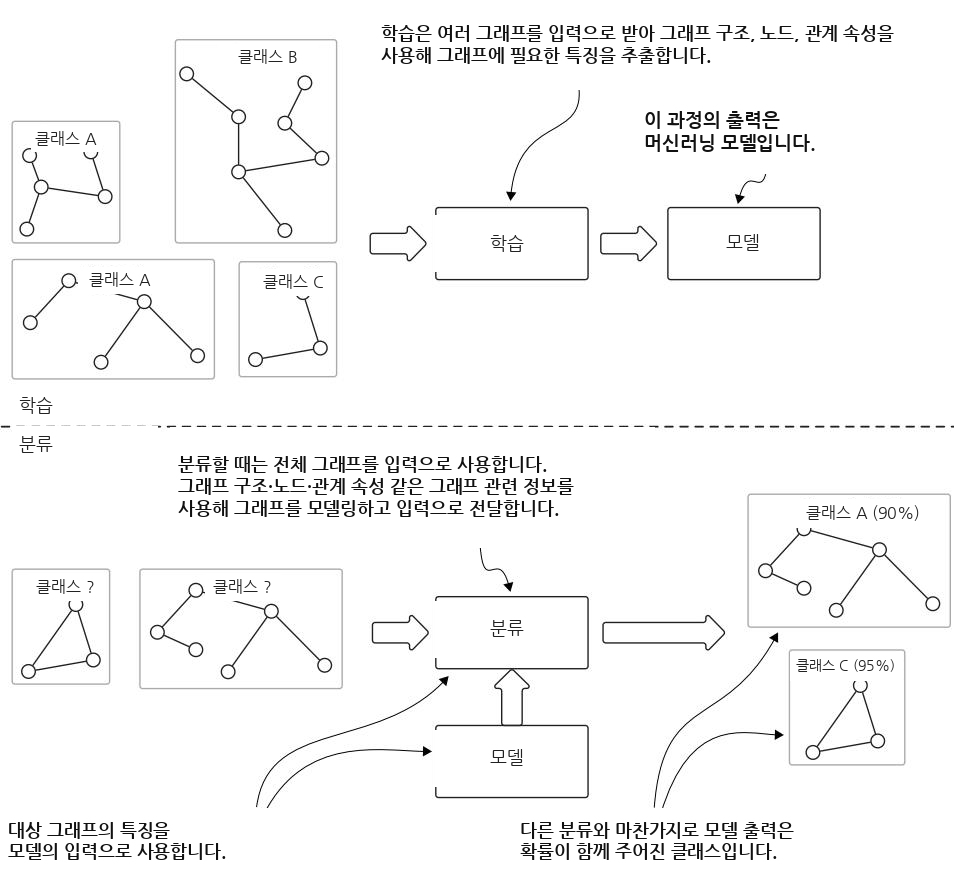

*그림 9.5 — 그래프 분류의 흐름. 훈련 단계에서는 클래스가 달린 **여러 그래프** 를 학습하고, 예측 단계에서는 라벨 없는 그래프의 클래스를 예측한다. 오른쪽 아래 주석대로 출력은 다른 분류와 마찬가지로 **클래스 + 확신도** 다. 위 표의 마지막 줄이 이 그림에서 눈에 보인다 — 훈련 입력이 서로 겹치지 않는 독립된 상자들이다.*

목표는 라벨 달린 그래프들의 훈련 집합으로 **"그래프 하나 전체 → 라벨"** 로 가는 사상을 배우는 것이다. 가장 큰 난관은 **각 그래프의 내부 구조와 그 구성 요소의 성질을 함께 효과적으로 포착하는 특징을 개발하는 일** 이다. 이 문장이 9.3 절로 넘어가는 다리다.

응용 예: **효소**(enzyme) 판별 — 단백질을 그래프(아미노산 = 노드, 일정 거리보다 가까우면 엣지)로 표현해 어떤 단백질이 효소인지 예측한다. 또는 **악성코드 분류기** — 프로그램의 구문과 데이터 흐름을 그래프로 표현해 악의적인지 탐지한다.


---
### 9.3 그래프 위의 머신러닝: 어떻게? — 전용 알고리즘이냐, 특징 공학이냐

"왜"와 "무엇을"이 끝났으니 **"어떻게"** 다. 해법의 방향은 크게 둘이다.

| 접근 | 하는 일 | 대가 |
| --- | --- | --- |
| **① 그래프 전용 알고리즘** (예: **집단 분류**, collective classification) | 그래프 구조를 **직접** 처리한다. 노드의 특징과 이웃 관계를 동시에 고려해 예측한다 | 중간 변환이 없어 깔끔하지만, 쓸 수 있는 알고리즘이 그래프용으로 따로 만들어진 것에 국한된다 |
| **② 특징 공학 후 전통적 ML** | 그래프 구조를 먼저 **특징 벡터** 로 바꾼다. 그러면 딥러닝을 포함한 **기존 ML 알고리즘 생태계 전체** 를 쓸 수 있다 | 난관이 "노드·엣지·그래프의 본질적 특성을 담아내는 적절한 특징을 정의하는 문제"로 **옮겨 간다** |

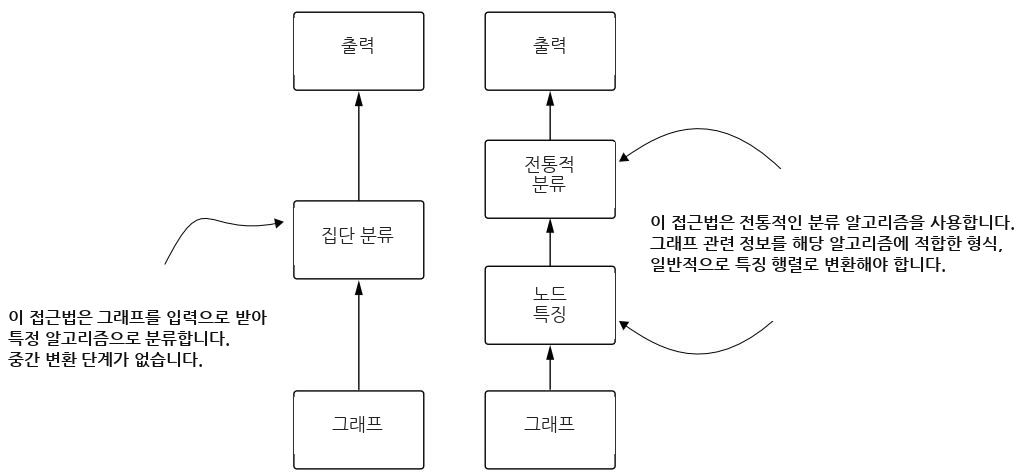

*그림 9.6 — 그래프 기반 분류 접근(집단 분류, 왼쪽) 대 분류를 위한 전통적 알고리즘(오른쪽). 왼쪽 주석은 "그래프를 입력으로 받아 전용 알고리즘으로 분류한다. **중간 단계가 없다**", 오른쪽 주석은 "전통적 분류 알고리즘을 쓴다. 그래프 관련 정보를 그 알고리즘에 맞는 형식(일반적으로 **특징 행렬**)으로 변환해야 한다"고 적혀 있다. 두 흐름의 차이는 상자 하나 — `Node features` 다. 이 책의 4부는 **오른쪽** 을 택하고, 그 상자를 채우는 방법이 9장(수동) → 10장(반자동) → 11장(자동)의 줄기다.*

책의 이 부분은 **②** 를 택한다. 순서는 이렇다. 먼저 **수동 특징 추출** 을 보며 그것이 얼마나 철저한지, 동시에 얼마나 **지루한** 작업인지 보인다(9장·10장). 그다음 **반자동** 으로 나아가고(10장), 마지막에 자동 특징 학습의 강력한 해법으로 **GNN** 에 뛰어든다(11장·12장). GNN 은 구조적 패턴과 노드 성질을 함께 포착하는 데 뛰어나 **특히 불완전한 KG 에 유용** 하다.

---

#### 9.3.1 노드 분류와 링크 예측 — 특징화부터 로지스틱 회귀까지, 실제 코드로

이제 코드가 나온다. 먼저 훈련과 예측의 전체 흐름을 두 장의 그림으로 확정한다.

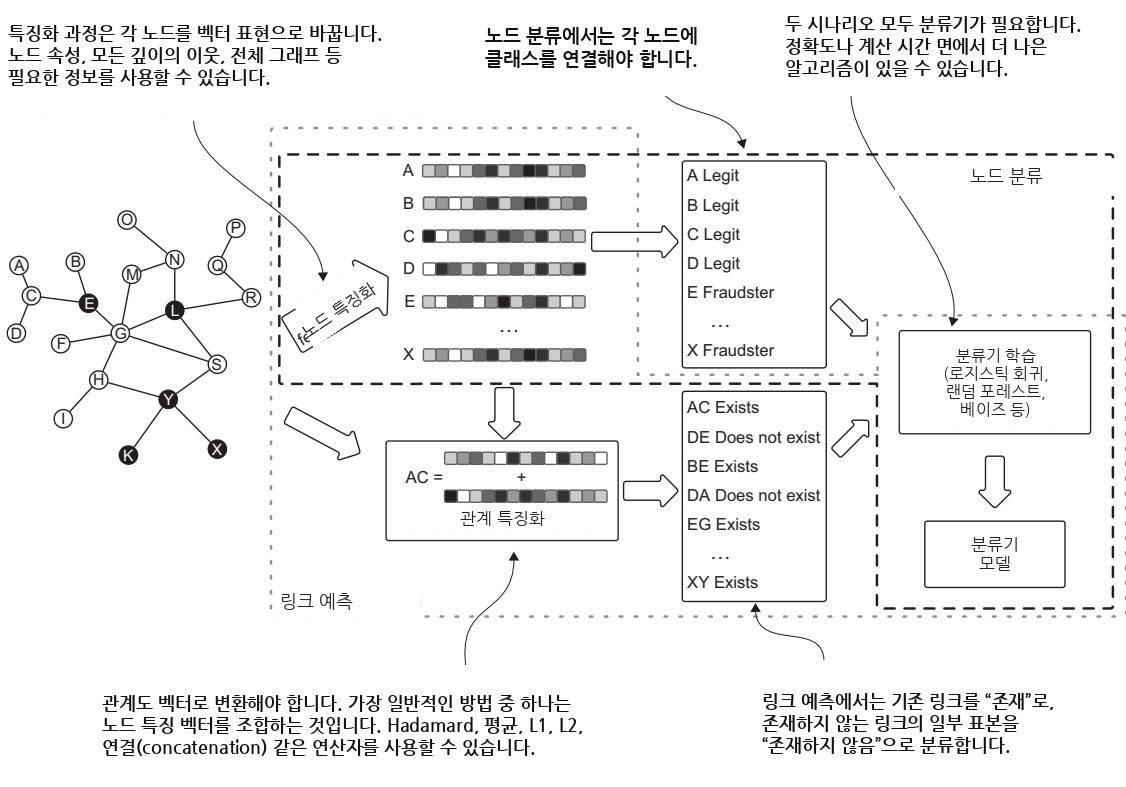

*그림 9.7 — 노드 분류와 링크 예측의 **훈련** 흐름. 결정적인 단계는 노드와 관계의 **특징화** 다. 이 과정이 끝나면 벡터를 고전적 알고리즘에 넘길 수 있다. 왼쪽 위 주석대로 특징화는 "필요한 것 무엇이든 — 노드 속성, 임의 단계의 이웃, 그래프 전체"를 쓸 수 있다. 아래쪽 주석은 **관계** 특징화를 짚는다 — 두 노드의 특징 벡터를 Hadamard 곱·평균·L1·L2·이어붙이기 같은 연산자로 합성하는 것이 가장 흔한 방법이다. 노드 분류와 링크 예측이 같은 그림 안에 있는 이유는 **둘 다 분류 과제** 라서다.*

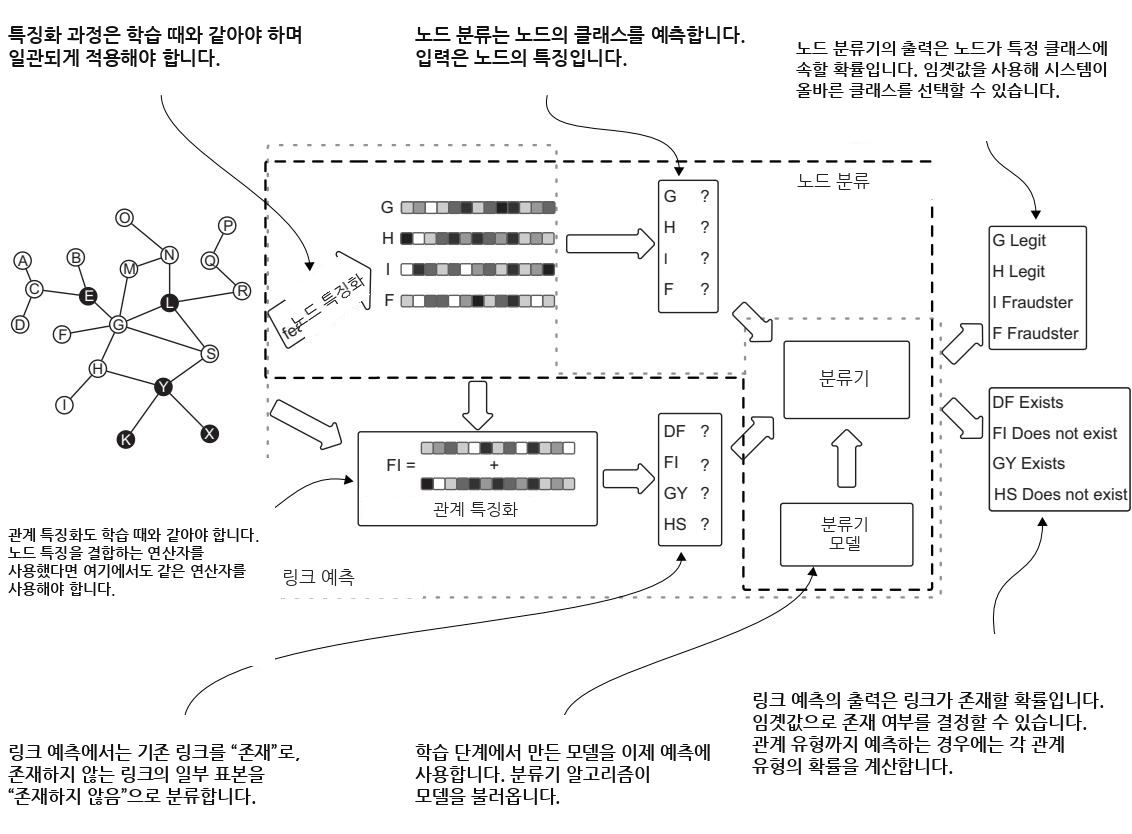

*그림 9.8 — 노드 분류와 링크 예측의 **예측** 흐름. 왼쪽 위 주석이 이 절에서 가장 중요한 제약을 반복한다 — **특징화 과정은 훈련 때와 같아야 하며 일관돼야 한다.** 왼쪽 아래 주석은 관계 특징화에도 같은 제약이 걸린다고 못 박는다: "연산자를 써서 노드 특징을 합성했다면 여기서도 같은 연산자를 써야 한다."*

> **참고 (원문의 경고 박스)** — 훈련 중에 쓴 특징화 과정은 예측할 때 쓰는 것과 **반드시 같아야 한다.** 그렇지 않으면 예측 단계가 올바르게 작동하지 않는다. 아래 책 9.4 가 `self.scaler` 를 인스턴스에 보관하고 책 9.5(평가 함수)가 그것을 **다시 fit 하지 않고 transform 만** 하는 이유가 정확히 이것이다.

##### 무대: 자카리 가라테 클럽

이 원리들을 실천할 무대는 **자카리 가라테 클럽**(Zachary Karate Club)이다. 1977년 Wayne Zachary 가 관찰한 실제 데이터로, 어느 가라테 클럽 34명 회원 사이의 **클럽 밖에서의** 상호작용을 기록한 것이다.

| 요소 | 이 그래프에서 |
| --- | --- |
| 노드 | 클럽 회원 34명 |
| 엣지 | 클럽 밖에서 교류가 있는 회원 쌍 |
| 사건 | 관리자 **"John A"** 와 사범 **"Mr. Hi"**(둘 다 가명) 사이의 분쟁으로 클럽이 **두 파벌로 갈라졌다** |
| 정답 라벨 | 분열 후 각 회원이 실제로 **어느 클럽에 합류했는지** |
| 과제 | **분열 이전** 의 친구 관계 구조만으로 이 소속을 예측하기 |

이 무대가 이 장에 알맞은 이유가 셋이다. 첫째, **정답이 실제로 관측된** 데이터라 채점할 수 있다. 둘째, 34노드라서 Neo4j 도 GPU 도 필요 없다 — `networkx` 에 상수로 들어 있다. 셋째, 라벨이 **네트워크 구조에 실제로 새겨져 있어서** 특징을 잘 만들면 성능이 오르는 것을 눈으로 볼 수 있다.

> **용어 주의 — 세 가지 이름이 같은 사람들을 가리킨다.** 책 본문은 두 파벌을 `Mr. Hi`(사범) 와 `John A`(관리자, administrator)라 부른다. 그런데 `networkx` 의 노드 속성 `club` 은 `'Mr. Hi'` 와 `'Officer'` 를 쓰고, 저장소 코드 리스팅 9.8 도 `.count('Officer')` 로 그 문자열을 센다. 11장의 저장소 코드는 같은 인물(노드 33)을 또 `president` 라 부른다. **`John A` = `Officer` = `president` = 노드 33** 이다. 이 노트북은 코드가 실제로 쓰는 `Mr. Hi` / `Officer` 를 기준으로 적는다.

먼저 네트워크를 만들어 눈으로 본다. **이 예제는 Neo4j 에 아무것도 저장하지 않는다** — 원문이 직접 밝히듯 네트워크가 아주 작고 `networkx` 에 기본 내장되어 있기 때문이다.


── 책 Listing 9.1  Creating and drawing a karate club network
   (simple_classification_example.py  L80-L88  (draw_and_save_graph_picture))
    def draw_and_save_graph_picture(G):
        set_club_colors(G)
        layout_position = nx.spring_layout(G, k=8 / math.sqrt(G.order()))
        colors = [n[1]['color'] for n in G.nodes(data=True)]
        nx.draw_networkx(G, pos=layout_position, node_color=colors)
        plt.axis('off')
        plt.savefig("Karate_Graph.svg", format="SVG", dpi=1000)
        plt.savefig("Karate_Graph.png", format="PNG", dpi=1000)
        plt.show()

── simple_classification_example.py  L51-L57  (set_club_colors)   — 책 9.1 이 함께 싣는 헬퍼 (별도 번호는 없다)
    def set_club_colors(G):
        for node in G.nodes(data=True):
            # Mr. Hi = 'purple', Officier = 'blue'
            color = '#00fff9'
            if node[1]['club'] == 'Mr. Hi':
                color = '#e6e6fa'
            node[1]['color'] = color

실행: analysis/simple_classification_example.py 의 draw_and_

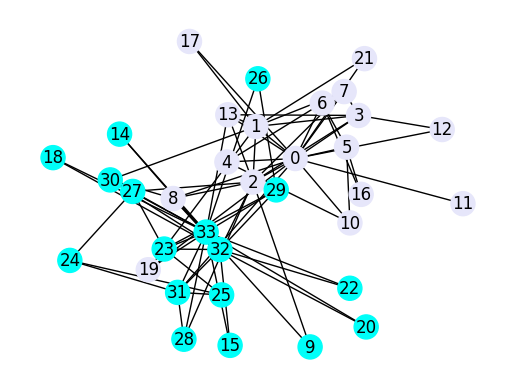

소요 0.7초 · 리스팅이 저장한 파일 ['Karate_Graph.svg', 'Karate_Graph.png'] (임시 폴더로 돌렸다)

── 그래프 실측
    가라테 클럽 노드 수                              34
    가라테 클럽 엣지 수                              78
    파벌 크기 (Mr. Hi / Officer)                 17 / 17
    차수 최소 / 최대 / 평균                          1 / 17 / 4.59
    지름 / 밀도                                  5 / 0.1390
    노드 0(Mr. Hi) 차수 / 노드 33(Officer) 차수      16 / 17

── 노드별 club 속성 (정답 라벨의 원천)
    Mr. Hi   17명  [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 16, 17, 19, 21]
    Officer  17명  [9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]

── 읽는 법
  두 파벌이 정확히 17 대 17 이다. 즉 다수 클래스를 무조건 찍는 기준선(baseline)의
  기대 정확도가 50% 다. 아래에서 나오는 F1 0.43 은 그 기준선보다도 못하다는 뜻이다.
  노드 0(Mr. Hi)과 33(Officer)의 차수가 16·17 로 압도적이다 — 두 리더다.
  지름이 5, 평균 차수가 4.59 인 아주 작고 촘촘한 그래프다.


In [3]:
"""책 9.1 — 가라테 클럽 네트워크를 만들고 그린다.

저장소 파일을 **한 글자도 고치지 않고** 그 안의 함수를 그대로 호출한다.
importlib 로 모듈만 임포트하므로 `__main__` 블록(= 책 9.6)은 아직 실행되지 않는다.
책의 순서를 따라 9.1 부터 하나씩 밟기 위한 것이다.

두 가지를 짚어 둔다.
  * 책 9.1 은 `draw_and_save_graph_picture(G)` 호출을 정의보다 **먼저** 인쇄한다.
    파이썬에서는 그 순서로 실행하면 NameError 다. 실제 저장소 파일은 정의를 먼저
    두고 `__main__` 에서 호출하므로 정상 동작한다 (아래 「원문·저장소 차이」 참고).
  * `plt.savefig` 는 savefig_to_tmp() 로 임시 폴더에 돌린다. 원본 코드는 cwd 에
    Karate_Graph.svg/.png 를 쓰는데, 주피터의 cwd 가 이 챕터 폴더이기 때문이다.
    plt.show() 는 그대로여서 그림은 인라인으로 뜬다.

⏱️ 1초 미만. 대부분이 dpi=1000 savefig 두 번이다.
"""
import time

import networkx as nx

show("9.1")
print()
show_symbol(CLS, "set_club_colors", "책 9.1 이 함께 싣는 헬퍼 (별도 번호는 없다)")

# ---- 저장소 함수를 그대로 실행한다 -------------------------------------------
CLASSIFY = load_module(CLS, "kglm_ch09_classification")

G = nx.karate_club_graph()
print(f"\n실행: {CLS} 의 draw_and_save_graph_picture(G)")
started = time.time()
with savefig_to_tmp() as written:
    CLASSIFY.draw_and_save_graph_picture(G)
elapsed = time.time() - started
print(f"소요 {elapsed:.1f}초 · 리스팅이 저장한 파일 {written} (임시 폴더로 돌렸다)")

# ---- 그래프를 수치로 확인한다 -------------------------------------------------
clubs = nx.get_node_attributes(G, "club")
degrees = dict(G.degree())

MEASURED["가라테 클럽 노드 수"] = G.number_of_nodes()
MEASURED["가라테 클럽 엣지 수"] = G.number_of_edges()
MEASURED["파벌 크기 (Mr. Hi / Officer)"] = (
    f"{list(clubs.values()).count('Mr. Hi')} / {list(clubs.values()).count('Officer')}")
MEASURED["차수 최소 / 최대 / 평균"] = (
    f"{min(degrees.values())} / {max(degrees.values())} / "
    f"{sum(degrees.values()) / G.number_of_nodes():.2f}")
MEASURED["지름 / 밀도"] = f"{nx.diameter(G)} / {nx.density(G):.4f}"
MEASURED["노드 0(Mr. Hi) 차수 / 노드 33(Officer) 차수"] = f"{degrees[0]} / {degrees[33]}"

print("\n── 그래프 실측")
for key in ("가라테 클럽 노드 수", "가라테 클럽 엣지 수", "파벌 크기 (Mr. Hi / Officer)",
            "차수 최소 / 최대 / 평균", "지름 / 밀도",
            "노드 0(Mr. Hi) 차수 / 노드 33(Officer) 차수"):
    print(f"    {key:<40} {MEASURED[key]}")

print("\n── 노드별 club 속성 (정답 라벨의 원천)")
for club_name in ("Mr. Hi", "Officer"):
    members = sorted(n for n, c in clubs.items() if c == club_name)
    print(f"    {club_name:<8} {len(members):2d}명  {members}")

print("\n── 읽는 법")
print("  두 파벌이 정확히 17 대 17 이다. 즉 다수 클래스를 무조건 찍는 기준선(baseline)의")
print("  기대 정확도가 50% 다. 아래에서 나오는 F1 0.43 은 그 기준선보다도 못하다는 뜻이다.")
print("  노드 0(Mr. Hi)과 33(Officer)의 차수가 16·17 로 압도적이다 — 두 리더다.")
print("  지름이 5, 평균 차수가 4.59 인 아주 작고 촘촘한 그래프다.")


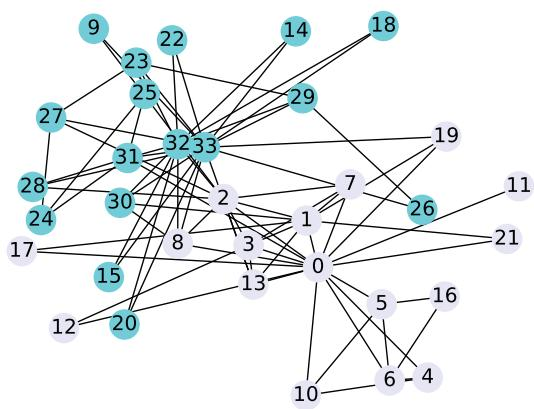

*그림 9.9 — 리스팅 9.1 의 코드로 만들어진 가라테 클럽 그래프. 노드의 음영은 그 회원이 **결국 합류한 클럽** 을 나타낸다. 위 셀이 그린 그림과 비교해 보라 — `nx.spring_layout` 은 매번 다른 초기값에서 시작하므로 **노드 위치는 실행마다 달라진다.** 같아야 하는 것은 위치가 아니라 구조다. 어느 그림에서든 노드 0 주변의 밝은 무리와 노드 33·32 주변의 어두운 무리가 두 덩어리로 갈리고, 그 사이에 걸친 노드가 몇 개 보인다. 그 걸친 노드들이 아래에서 분류를 어렵게 만드는 장본인이다.*

---

첫 단계는 **각 노드의 벡터 표현** 을 만드는 것이다(그림 9.7·9.8 의 `Node featurization` 상자). 정교한 임베딩 기법은 10장과 11장에서 다루므로 여기서는 가장 단순한 것으로 시작한다 — **각 노드를 그 차수(degree)로 표현하기.** 차수는 그 노드가 다른 노드와 맺은 연결의 개수이고, 네트워크 안에서 그 노드가 **얼마나 연결되어 있는지** 를 담는다.

**책 9.2** 가 하는 일은 두 줄이다. `G.degree()` 로 차수를 모으고, `[[i] for i in embeddings]` 로 각 값을 원소 하나짜리 벡터(예: `[3]`)로 감싼다. 임베딩은 결국 "숫자의 리스트"여야 하므로 차수 하나만 쓰더라도 벡터 형태로 만들어 둔다.

> **연습 문제 (책 9.2 뒤의 박스)** — *"이 기법은 기초적이지만, 노드의 차수만으로는 우리 목표(어느 클럽인지 맞히기)에 큰 도움이 되지 않을 수 있습니다. 연습 삼아, 다른 두 지표를 써 보세요. **Mr. Hi 의 이웃들의 차수와 John A 의 이웃들의 차수** 입니다. 해답은 이 장 뒤에서 보여 드립니다."*
>
> 이 연습의 **해답이 곧 리스팅 9.8** 이다. 책은 문제를 먼저 던지고 실패를 보여 준 다음 답을 제시하는 순서를 택했다. 아래 **실습 9-A** 가 세 특징화를 한 표에 놓고 이 연습의 효과를 정량화한다.

---

##### 책 9.3 — Node2Vec, GNN 이전의 자율 표현 학습

GNN 이 등장하기 전 **Node2Vec** 은 순전히 네트워크 구조만으로 노드 임베딩을 계산하는 자율 표현 학습의 대표 기법이었다. 코드가 하는 일은 셋이다.

| 단계 | 인자 | 뜻 |
| --- | --- | --- |
| ① 초기화 | `dimensions=64` | 각 노드를 64차원 벡터로 표현한다 |
| | `walk_length=30`, `num_walks=200` | 그래프를 따라 **200번** 랜덤 워크를 하고 각 워크가 노드 **30개** 를 방문한다 |
| | `workers=4` | 효율을 위해 네 개의 병렬 워커를 쓴다 |
| | `seed=0` | 랜덤 시드로 **"결과의 재현성을 보장한다"** (책의 주석) |
| ② 학습 | `window=10` | 각 워크 시퀀스에서 앞뒤로 노드 10개를 문맥으로 본다 |
| | `min_count=1` | 한 번만 방문된 노드까지 전부 훈련에 넣는다 |
| | `batch_words=4` | 단어(노드)를 작은 배치로 처리한다 |
| ③ 추출 | `model.wv.get_vector(i)` | 노드별 학습된 임베딩을 꺼내 리스트로 돌려준다 |

여기서 짚어 둘 평행선이 있다. Node2Vec 은 랜덤 워크로 "노드 근처를 산책하며 이웃 문맥"을 배우는데, 이는 **언어 모델이 문장 속 단어의 앞뒤 문맥으로 단어 의미를 배우는 방식과 꼭 닮았다.** 그래서 인자 이름(`window`, `min_count`, `batch_words`)도 전부 Word2Vec 의 것이다. 11장이 이 닮음을 **인코더–디코더** 라는 틀로 정식화한다.

> **⚠️ `seed=0` 은 재현성을 보장하지 못한다.** 책의 주석은 틀렸다. `workers=4` 로 두면 `gensim` 의 Word2Vec 이 네 스레드로 학습하고, 스레드 스케줄링이 비결정적이라 **시드를 고정해도 실행마다 다른 임베딩이 나온다.** 아래 셀이 같은 코드를 여러 번 돌려 이것을 실측하고, **실습 9-B** 가 `workers=1` 로 두면 재현성이 회복되는 것까지 확인한다. 이 절의 수치 중 Node2Vec 이 걸린 것은 전부 이 성질을 안고 읽어야 한다.

---

##### 책 9.4 · 9.5 — 훈련 함수와 평가 함수

리스팅 9.2 와 9.3 은 **그래프 전체** 에 대해 임베딩을 계산한다. 따라서 훈련 집합용과 예측용을 따로 계산할 필요가 없다. 이제 분류기가 필요하다. 책 9.4 는 **로지스틱 회귀** 를 쓰는 훈련 함수다. 두 가지 ML 개념이 등장한다.

**① 특징 표준화**(feature standardization). 서로 다른 척도로 움직이는 여러 노드 특징을 다룰 때 꼭 필요하다. `StandardScaler` 로 모든 특징을 **평균 0, 분산 1** 로 변환하면 각 특징이 원래 척도와 무관하게 모델의 결정에 비례하는 만큼 기여한다.

> **특징 스케일링이 중요한 이유 (원문 박스)** — ML 알고리즘은 데이터 점 사이의 **유클리드 거리** 계산에 의존하는 경우가 많다. 적절한 스케일링이 없으면 **수치 범위가 큰 특징이 계산을 지배** 해 버린다. 실제 중요도와 무관하게 말이다. 노드 차수가 1\~1,000 이고 중심성 지표가 0\~1 이면, 거리 기반 계산에서 차수가 중심성의 영향을 압도한다. 모델이 특징의 **예측력이 아니라 척도 때문에** 그 특징에 민감해져 편향된 예측과 낮아진 정확도로 이어진다.

**② 로지스틱 회귀**(logistic regression). 이름과 달리 **분류** 알고리즘이고 이진 예측에 특히 뛰어나다. 특징들의 선형 결합을 로지스틱 함수로 0\~1 확률로 변환한다. 가라테 클럽에서는 각 회원이 사범의 클럽 또는 관리자의 클럽에 합류할 확률을 예측한다. 코드가 쓰는 [`LogisticRegressionCV`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegressionCV.html) 는 **교차 검증으로 정규화 세기를 자동 튜닝** 하는 변종이라 하이퍼파라미터를 손으로 고를 필요가 없다. 이 장의 주장("문제는 분류기가 아니라 특징이다")을 세우려면 분류기 쪽 변수를 지워야 하므로 알맞은 선택이다.

이어지는 **평가 함수** 는 따로 떼어 둔 테스트 노드 집합에 대해 예측 라벨과 실제 결과를 비교한다. 여기서 **반드시 지킬 점** 이 있다 — 테스트 임베딩을 표준화할 때는 훈련 데이터에 맞춰 학습해 둔 **바로 그 스케일러**(`self.scaler`)를 그대로 써야 한다. 테스트 데이터로 스케일러를 새로 `fit` 하면 훈련 때와 다른 변환이 적용되어 예측이 어긋난다. 그림 9.8 이 반복한 "특징화는 훈련 때와 같아야 한다"가 코드 한 줄로 나타난 것이다.

> **책 9.5 의 캡션이 원서 md 에서 유실됐다.** 원서 원문 마크다운에는 `Listing 9.5` 라는 문자열이 없고 9.4 다음이 바로 9.6 이다. 그런데 그 사이에 **캡션 없는 코드 블록** 이 하나 있고 내용이 `EvaluateEmbedding.evaluate` 와 같다. PDF→마크다운 변환에서 캡션 줄이 떨어져 나간 것이다 — 해설판은 이를 "리스팅 9.5 평가 함수"로 복원해 실었다. 검증 게이트는 원문 문자열만 보므로 9.5 를 요구하지 않지만, 이 노트북은 9.4 와 나란히 원문을 싣는다. 책 9.6 이 `train` 과 `evaluate` 를 **짝으로** 호출하기 때문이다.

---

##### 책 9.6 — 전체 과정, 그리고 "주석을 옮겨 실험을 바꾼다"

책 9.6 은 앞선 리스팅들의 부품을 모두 써서 결과를 출력한다.

| 줄 | 하는 일 |
| --- | --- |
| `labels = np.asarray([G.nodes[i]['club'] != 'Mr. Hi' ...]).astype(np.int64)` | 정답 라벨. `club` 이 `'Mr. Hi'` 가 **아니면** `True` → `1`, 맞으면 `False` → `0` |
| `#embeddings = compute_degree_embeddings(G)` / `embeddings = compute_complex_embeddings(G)` | **시험할 임베딩을 주석으로 고른다.** 하나를 풀고 나머지를 막는다 |
| `pd.DataFrame({'nodeId', 'embeddings', 'label'})` | 노드 ID·임베딩·라벨을 한 표로 |
| `train_test_split(df, test_size=0.4, random_state=0)` | 40%(14개)를 테스트로 떼어 놓는다. 시드가 고정이라 **분할은 항상 같다** |
| `classifier.train(train)` / `classifier.evaluate(test)` | 책 9.4 와 9.5 를 차례로 호출 |

**이 노트북이 임베딩 함수를 노트북에서 갈아 끼우는 이유** 가 여기 있다. 책은 "임베딩을 바꾸려면 주석을 옮기라"고 지시하는데, 그러려면 **업스트림 파일을 편집** 해야 한다. 원본 수정은 금지이므로 대신 저장소의 함수들(`compute_*`, `EvaluateEmbedding`)을 그대로 임포트해 **책 9.6 의 여섯 줄을 그대로 옮긴 러너** 로 감쌌다. 새로 쓴 것은 그 여섯 줄의 글루뿐이고 학습·평가 로직은 전부 저장소 코드다.


In [4]:
"""책 9.2 · 9.3 · 9.4 · 9.5 원문을 싣고, 책 9.6 파이프라인으로 **책 9.7 을 재현** 한다.

책 9.7 은 코드가 아니라 **출력 표** 다. 저장소에 그 산출물이 저장되어 있지 않으므로
직접 만들어야 한다. 책은 "리스팅 9.6 에서 임베딩 함수의 주석을 옮기라"고 지시하는데
업스트림 파일을 고칠 수는 없다. 그래서 저장소 함수를 그대로 임포트해 책 9.6 의
여섯 줄(labels → DataFrame → split → train → evaluate)만 러너로 옮겼다.
학습·평가 로직은 한 줄도 새로 쓰지 않았다 — EvaluateEmbedding 을 그대로 쓴다.

⏱️ 약 4초. degree 쪽은 즉시, Node2Vec(200워크 × 길이 30)이 3~4초를 쓴다.
   Node2Vec 은 workers=4 라 **실행마다 결과가 달라진다.** 그래서 세 번 돌려
   흩어짐까지 함께 본다 (책이 말한 "F1 30~70% 널뛰기"의 실측).
"""
import time

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split

for book_no in ("9.2", "9.3", "9.4"):
    show(book_no)
    print()
show_symbol(CLS, "EvaluateEmbedding.evaluate",
            "책 9.5 '평가 함수' (원서 md 에서 캡션이 유실됐다)")
print()
show("9.6")

# ---- 책 9.6 을 러너로 감싼다 --------------------------------------------------
# 아래 여섯 줄이 책 9.6 과 일대일로 대응한다. 저장소 원본은 건드리지 않는다.
LABELS = np.asarray([G.nodes[i]["club"] != "Mr. Hi" for i in G.nodes]).astype(np.int64)


def run_pipeline(embeddings, *, seed: int = 0):
    """책 9.6 의 흐름을 그대로 따라 학습·평가하고 지표를 돌려준다.

    책 9.5(evaluate)는 결과를 print 만 하고 반환하지 않는다. 표로 비교하려면 값이
    필요하므로, 같은 계산을 이 함수가 다시 한 번 해서 dict 로 돌려준다.
    지표 계산은 책 9.5 와 똑같이 average='weighted' 다.
    """
    frame = pd.DataFrame({"nodeId": list(G.nodes), "embeddings": embeddings, "label": LABELS})
    train_set, test_set = train_test_split(frame, test_size=0.4, random_state=seed)

    classifier = CLASSIFY.EvaluateEmbedding()      # 저장소 클래스를 그대로 쓴다
    classifier.train(train_set)                    # 책 9.4

    test_embeddings = test_set.embeddings.values.tolist()
    gold = test_set.label.values.tolist()
    predicted = classifier.model.predict(classifier.scaler.transform(test_embeddings))
    weighted = precision_recall_fscore_support(gold, predicted, average="weighted")
    return {
        "gold": gold,
        "predicted": [int(v) for v in predicted],
        "precision": weighted[0],
        "recall": weighted[1],
        "f1": weighted[2],
        "confusion": confusion_matrix(gold, predicted).tolist(),
        "test_nodes": test_set.nodeId.tolist(),
        "dims": len(embeddings[0]),
    }


def report(title, result):
    print(f"\n{title}")
    print("  Gold:      ", result["gold"])
    print("  Predicted: ", result["predicted"])
    print(f"  Precision: {result['precision']}")
    print(f"  Recall:    {result['recall']}")
    print(f"  f-score:   {result['f1']}")
    print(f"  Confusion Matrix: {result['confusion'][0]}")
    print(f"                    {result['confusion'][1]}")


# ---- 책 9.7 첫 블록: 차수 하나짜리 임베딩 ------------------------------------
started = time.time()
degree_result = run_pipeline(CLASSIFY.compute_degree_embeddings(G))
degree_seconds = time.time() - started
report("RESULTS WITH MORE SIMPLE EMBEDDINGS USING DEGREE   (책 9.2 임베딩)", degree_result)
print(f"  임베딩 차원 {degree_result['dims']} · 소요 {degree_seconds:.2f}초")

# ---- 책 9.7 둘째 블록: Node2Vec 임베딩 (workers=4 → 비결정적) ----------------
print("\nRESULTS WITH MORE COMPLEX EMBEDDINGS USING NODE2VEC   (책 9.3 임베딩)")
print("  같은 코드를 세 번 돌린다. workers=4 라 seed=0 이어도 값이 갈린다.")
node2vec_runs = []
for attempt in range(3):
    started = time.time()
    result = run_pipeline(CLASSIFY.compute_complex_embeddings(G))
    node2vec_runs.append(result)
    print(f"\n  [{attempt + 1}회차 · {time.time() - started:.1f}초]")
    print("  Gold:      ", result["gold"])
    print("  Predicted: ", result["predicted"])
    print(f"  Precision: {result['precision']:.4f}  Recall: {result['recall']:.4f}"
          f"  f-score: {result['f1']:.4f}  Confusion: {result['confusion']}")

f1_values = [r["f1"] for r in node2vec_runs]
print(f"\n  -> 3회 f-score  최소 {min(f1_values):.4f} · 최대 {max(f1_values):.4f}"
      f" · 평균 {np.mean(f1_values):.4f}  (임베딩 차원 {node2vec_runs[0]['dims']})")

# ---- 책이 인쇄한 값과 대조한다 -------------------------------------------------
BOOK_9_7 = {
    "degree": {"precision": 0.44642857142857145, "recall": 0.42857142857142855,
               "f1": 0.42857142857142855, "confusion": [[3, 3], [5, 3]],
               "predicted": [1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0]},
    "node2vec": {"precision": 0.6530612244897959, "recall": 0.6428571428571429,
                 "f1": 0.6446886446886447, "confusion": [[4, 2], [3, 5]],
                 "predicted": [0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0]},
}

print("\n── 책 9.7 인쇄값과의 대조")
degree_exact = all(
    np.isclose(degree_result[key], BOOK_9_7["degree"][key])
    for key in ("precision", "recall", "f1")
) and degree_result["confusion"] == BOOK_9_7["degree"]["confusion"] \
    and degree_result["predicted"] == BOOK_9_7["degree"]["predicted"]
print(f"  degree   : {'완전 일치 ✓' if degree_exact else '불일치 ✗'}"
      f"   (책 P={BOOK_9_7['degree']['precision']} / 실측 P={degree_result['precision']})")
print(f"  node2vec : 일치할 수 없다 — 책 f={BOOK_9_7['node2vec']['f1']:.4f} vs "
      f"실측 {min(f1_values):.4f}~{max(f1_values):.4f}. workers=4 비결정성 때문이다")

MEASURED["책 9.7 degree — P / R / F1"] = (
    f"{degree_result['precision']:.6f} / {degree_result['recall']:.6f} / {degree_result['f1']:.6f}")
MEASURED["책 9.7 degree — 혼동 행렬"] = degree_result["confusion"]
MEASURED["책 9.7 degree — 책 인쇄값과 완전 일치"] = degree_exact
MEASURED["책 9.7 node2vec — F1 3회 (비결정적)"] = [round(v, 4) for v in f1_values]
MEASURED["책 9.7 임베딩 차원 (degree / node2vec)"] = (
    f"{degree_result['dims']} / {node2vec_runs[0]['dims']}")
MEASURED["테스트 노드 (분할은 random_state=0 으로 고정)"] = degree_result["test_nodes"]

print("\n── 읽는 법")
print("  degree 는 책 인쇄값과 소수점 끝까지 같다. 시드가 걸린 곳이 train_test_split")
print("  하나뿐이고 나머지(차수 계산·표준화·LogisticRegressionCV)가 전부 결정적이기 때문이다.")
print("  node2vec 은 같은 코드·같은 시드로도 실행마다 다르다. 책이 인쇄한 0.6447 은")
print("  그중 한 번의 관측이며, 그 값을 목표로 삼아 재현하려 해서는 안 된다.")
print(f"  이번 실행의 F1 은 degree {degree_result['f1']:.4f}, node2vec"
      f" {min(f1_values):.4f}~{max(f1_values):.4f} 다. 17대17 균형 데이터에서")
print("  무작위 추측의 기대치가 0.5 인데 degree 는 그보다 낮다. 분류기의 문제가 아니다 —")
print("  같은 LogisticRegressionCV 에 아래 책 9.8 의 세 칸 벡터를 넣으면 0.93 이 나온다.")


── 책 Listing 9.2  Representing each node by its degree
   (simple_classification_example.py  L60-L64  (compute_degree_embeddings))
    def compute_degree_embeddings(G):
        # using degree as embedding
        embeddings = np.array(list(dict(G.degree()).values()))
        embeddings = [[i] for i in embeddings]
        return embeddings

── 책 Listing 9.3  Using Node2Vec as an embedding technique
   (simple_classification_example.py  L74-L78  (compute_complex_embeddings))
    def compute_complex_embeddings(G):
        node2vec = Node2Vec(G, dimensions=64, walk_length=30, num_walks=200, workers=4, seed=0)
        model = node2vec.fit(window=10, min_count=1, batch_words=4, seed=0)
        embeddings = [model.wv.get_vector(i) for i in G.nodes]
        return embeddings

── 책 Listing 9.4  Training function
   (simple_classification_example.py  L25-L33  (EvaluateEmbedding.train))
        def train(self, train_dataset):
            X = train_dataset.embeddings.values.tolist()
            y 

Computing transition probabilities:   0%|          | 0/34 [00:00<?, ?it/s]

Computing transition probabilities: 100%|██████████| 34/34 [00:00<00:00, 19505.72it/s]

Generating walks (CPU: 4): 100%|██████████| 50/50 [00:00<00:00, 672.89it/s]



  [1회차 · 2.6초]
  Gold:       [0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0]
  Predicted:  [1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1]
  Precision: 0.4286  Recall: 0.4286  f-score: 0.4286  Confusion: [[2, 4], [4, 4]]


...


  [2회차 · 2.1초]
  Gold:       [0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0]
  Predicted:  [1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1]
  Precision: 0.7802  Recall: 0.6429  f-score: 0.5578  Confusion: [[1, 5], [0, 8]]


Computing transition probabilities:   0%|          | 0/34 [00:00<?, ?it/s]

Computing transition probabilities: 100%|██████████| 34/34 [00:00<00:00, 14689.57it/s]


Generating walks (CPU: 3): 100%|██████████| 50/50 [00:00<00:00, 529.13it/s]



  [3회차 · 2.5초]
  Gold:       [0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0]
  Predicted:  [0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1]
  Precision: 0.6494  Recall: 0.6429  f-score: 0.6115  Confusion: [[2, 4], [1, 7]]

  -> 3회 f-score  최소 0.4286 · 최대 0.6115 · 평균 0.5326  (임베딩 차원 64)

── 책 9.7 인쇄값과의 대조
  degree   : 완전 일치 ✓   (책 P=0.44642857142857145 / 실측 P=0.44642857142857145)
  node2vec : 일치할 수 없다 — 책 f=0.6447 vs 실측 0.4286~0.6115. workers=4 비결정성 때문이다

── 읽는 법
  degree 는 책 인쇄값과 소수점 끝까지 같다. 시드가 걸린 곳이 train_test_split
  하나뿐이고 나머지(차수 계산·표준화·LogisticRegressionCV)가 전부 결정적이기 때문이다.
  node2vec 은 같은 코드·같은 시드로도 실행마다 다르다. 책이 인쇄한 0.6447 은
  그중 한 번의 관측이며, 그 값을 목표로 삼아 재현하려 해서는 안 된다.
  이번 실행의 F1 은 degree 0.4286, node2vec 0.4286~0.6115 다. 17대17 균형 데이터에서
  무작위 추측의 기대치가 0.5 인데 degree 는 그보다 낮다. 분류기의 문제가 아니다 —
  같은 LogisticRegressionCV 에 아래 책 9.8 의 세 칸 벡터를 넣으면 0.93 이 나온다.


##### 책 9.7 을 읽는 법 — 나쁜 결과가 이 절의 주장이다

책은 이 두 블록을 보고 **"비교적 나쁘고 들쭉날쭉한 성능"** 이라고 평한다. 그리고 여러 번 실행하면 **F1 이 30%\~70% 사이를 널뛴다** 고 적는다. 위 셀이 그 널뛰기를 그대로 재현했다.

여기서 책이 끌어내는 추론이 이 절의 핵심 논증이다.

| 관찰 | 추론 |
| --- | --- |
| 결과가 나쁘다 | 어딘가 문제가 있다 |
| **로지스틱 회귀는 잘 확립되고 검증된 알고리즘이다** | 문제는 **분류 방법이 아니다** |
| 결과의 **분산이 크다** | 특징이 신뢰할 만한 신호를 담지 못했다 |
| → 결론 | **한계는 특징 공학 접근에 있다.** 차수만 쓴 단순한 노드 표현이 노드 분류에 필요한 복잡한 네트워크 패턴을 담아내지 못한다 |

**Node2Vec 도 마찬가지** 라는 점이 중요하다. 더 정교한 도구(64차원, 랜덤 워크 200회)를 썼는데도 안정적으로 좋아지지 않았다. 자율 임베딩이 자동으로 답을 주지는 않는다는 뜻이다.

왜 차수가 이 문제에서 쓸모없는지 생각해 보면 당연하다. 노드 0(Mr. Hi)의 차수는 16, 노드 33(Officer)의 차수는 17 이다. **두 리더의 차수가 거의 같다.** 그리고 차수 2 인 회원은 양쪽 파벌에 골고루 있다. `[차수]` 라는 한 칸 벡터는 "이 사람이 인기가 있나"를 담을 뿐 **"이 사람이 어느 쪽 사람인가"** 는 전혀 담지 못한다. 예측하려는 라벨과 관계없는 축을 하나 준 셈이다.

`train_test_split(test_size=0.4, random_state=0)` 이 남긴 테스트 노드는 14개뿐이다. 즉 한 노드를 맞히거나 틀리는 것이 F1 을 7%p 씩 흔든다. 작은 표본이 분산을 키우는 것도 사실이지만, 그것이 전부라면 Node2Vec 과 차수가 비슷하게 나쁠 이유가 없다. **아래 리스팅 9.8 이 같은 14개 테스트 노드에 대해 F1 0.93 을 내는 것** 이 표본 크기 탓이 아니라는 결정적 증거다.


---
##### 책 9.8 — 동종선호를 특징으로 만들기

특징 공학을 **동종선호**(homophily)로 개선한다. 총 연결 수만 세는 차수 대신 **그 연결들의 사회적 맥락** 을 고려해 더 풍부한 노드 표현을 만든다. 각 노드마다 세 원소짜리 벡터를 만든다.

| 원소 | 뜻 | 계산 |
| --- | --- | --- |
| `degree` | 총 차수 (전체 연결 수) | `G.degree(i)` |
| `mr_hi_degree` | **Mr. Hi 그룹으로의 연결 수** | 노드 $i$ 의 이웃들의 `club` 을 모아 `.count('Mr. Hi')` |
| `officer_degree` | **Officer 그룹으로의 연결 수** | 같은 리스트에 `.count('Officer')` |

이 접근이 동종선호를 활용하는 방식은 이렇다 — **한 노드의 그룹 소속은 그 이웃들의 그룹 소속에 영향을 받을 가능성이 크다** 고 가정한다. 9.2.1 절이 소셜 네트워크의 성질로 소개한 그 동종선호를, 세 칸짜리 정수 벡터로 번역한 것이다.

> **⚠️ 이것은 정답 라벨을 특징에 넣는 것이 아닌가?** 정직하게 짚어야 하는 문제다. `mr_hi_degree` 를 계산하려면 **이웃들의 `club` 속성**, 즉 이웃들의 정답 라벨을 읽어야 한다. 예측 대상 노드 자신의 라벨은 쓰지 않지만 그 이웃의 라벨은 쓴다. 9.2.1 절의 박스가 말한 **준지도**(semisupervised) 설정이 정확히 이 모양이다 — 훈련 중에 전체 그래프에 접근할 수 있고, 라벨 없는 노드에 대해서도 **이웃 구조** 를 안다. 다만 현실에서는 이웃의 라벨도 일부만 알려져 있을 것이므로, 이 세 칸 벡터는 **가장 유리한 조건에서의 상한** 에 가깝다. 이 장의 목적이 "특징 설계가 결과를 좌우한다"를 보이는 것이므로 그 상한을 보는 것 자체는 의미가 있다. 그리고 10\~12장은 라벨 대신 **구조** 에서 같은 정보를 끌어내려 한다.

> **원문 리스팅 9.8 은 OCR 로 줄이 뒤섞여 있다.** 원서 마크다운에서 이 리스팅은 `mr_hi_degree = [[...]]` 다음에 주석 조각이 끼어들고 `degree =` 의 우변이 사라져 있다. 해설판이 본문 설명에 맞춰 의도를 복원했고, **저장소 코드가 정본** 이다. 한 가지 사소한 차이 — 책은 총 차수를 `[G.degree(i) for i in G.nodes()]` 로, 저장소는 `list(dict(G.degree()).values())` 로 계산한다. 결과는 같다.

다음 셀은 저장소 스크립트를 **파일 그대로** 실행한다. 저장소가 기본으로 활성화해 둔 임베딩이 마침 `compute_specific_degree_embeddings` 라서, 스크립트를 손대지 않고 돌리면 **책 9.9 의 출력이 그대로 나온다.**


── 책 Listing 9.8  Computing featurization based on three types of degrees
   (simple_classification_example.py  L66-L72  (compute_specific_degree_embeddings))
    def compute_specific_degree_embeddings(G):
        clubs = nx.get_node_attributes(G, "club")
        mr_hi_degree = [[clubs[c] for c in G.neighbors(i)].count('Mr. Hi') for i in G.nodes()]
        officer_degree = [[clubs[c] for c in G.neighbors(i)].count('Officer') for i in G.nodes()]
        degree = list(dict(G.degree()).values())
        embeddings = [[degree[i], mr_hi_degree[i], officer_degree[i]] for i in G.nodes]
        return embeddings

실행: analysis/simple_classification_example.py  (책 9.1 + 9.6 + 9.8 이 한 파일에 들어 있다)


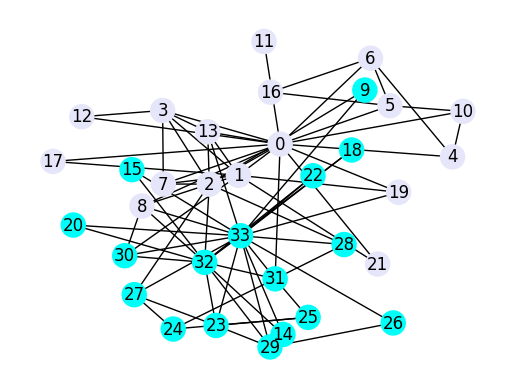

Gold:		 [0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0]
Predicted:	 [0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1]
Precision: 0.9365079365079365 Recall: 0.9285714285714286 f-score: 0.9274255156608098
Confusion Matrix:	 [[5 1]
 [0 8]]
Time to complete: 0.7282109260559082
소요 0.7초 · 리스팅이 저장한 파일 ['Karate_Graph.svg', 'Karate_Graph.png'] (임시 폴더로 돌렸다)

── 책 9.9 인쇄값과의 대조 (한 항목이라도 다르면 ✗ 가 뜬다)
  ✓ Gold       책 [0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0]
  ✓ Predicted  책 [0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1]
  ✓ Precision  책 0.9365079365079365
  ✓ Recall     책 0.9285714285714286
  ✓ f-score    책 0.9274255156608098
  ✓ Confusion  책 [[5, 1], [0, 8]]

  -> 책 9.9 를 소수점 끝까지 완전히 재현했다.

── 오분류 노드 1건
    노드 8: 정답 0(Mr. Hi) → 예측 1
      이웃 [0, 2, 30, 32, 33] = Mr. Hi 2명 / Officer 3명
      -> 이웃 다수가 Officer 쪽인데 정작 본인은 Mr. Hi 로 갔다. 동종선호 가정을 어기는 노드다

── 읽는 법
  같은 분류기·같은 분할·같은 14개 테스트 노드인데 F1 이 0.4286 → 0.9274 로 뛰었다.
  바뀐 것은 특징 벡터의 모양 하나뿐이다: [차수] → [차수, Mr.Hi 이웃 수, Officer 이웃 수].
  이것이 '특징 공학이 결정적이다' 의 실측 증거다. 그리고

In [5]:
"""책 9.8 원문을 싣고, 저장소 스크립트를 **파일 그대로** 실행해 책 9.9 를 재현한다.

runpy.run_path(..., run_name="__main__") 를 쓰는 이유가 셋이다.
  * 저장소 파일이 기본으로 활성화한 임베딩이 compute_specific_degree_embeddings 라서,
    한 글자도 고치지 않고 돌리면 책 9.9 의 출력이 그대로 나온다.
  * tasks.py 나 별도 프로세스로 돌리면 그림이 창으로 뜨고 결과 객체를 가져올 수 없다.
  * 코드를 노트북에 옮겨 적으면 "책이 가르치는 리스팅을 다시 쓰는" 금지 사항에 걸린다.

아래 출력에서 `Gold:` / `Predicted:` / `Precision:` ... 부분은 **저장소 코드가 직접
print 한 것** 이다 (책 9.5 evaluate). 그 뒤의 대조표만 이 셀이 계산한다.

⏱️ 1초 미만. 그림 한 장(dpi=1000 savefig 두 번)이 대부분이다.
"""
import runpy
import time

import networkx as nx

show("9.8")

print(f"\n실행: {CLS}  (책 9.1 + 9.6 + 9.8 이 한 파일에 들어 있다)")
print("=" * 78)
started = time.time()
with savefig_to_tmp() as written:
    SCRIPT = runpy.run_path(str(HERE / CLS), run_name="__main__")
elapsed = time.time() - started
print("=" * 78)
print(f"소요 {elapsed:.1f}초 · 리스팅이 저장한 파일 {written} (임시 폴더로 돌렸다)")

# ---- 같은 계산을 러너로 한 번 더 해서 값을 손에 쥔다 ---------------------------
# 스크립트의 evaluate() 는 print 만 하고 반환하지 않는다. 표로 비교하려면 값이 필요하다.
three_result = run_pipeline(CLASSIFY.compute_specific_degree_embeddings(G))

BOOK_9_9 = {
    "gold":      [0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0],
    "predicted": [0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1],
    "precision": 0.9365079365079365,
    "recall":    0.9285714285714286,
    "f1":        0.9274255156608098,
    "confusion": [[5, 1], [0, 8]],
}

print("\n── 책 9.9 인쇄값과의 대조 (한 항목이라도 다르면 ✗ 가 뜬다)")
rows = [
    ("Gold",      BOOK_9_9["gold"],      three_result["gold"]),
    ("Predicted", BOOK_9_9["predicted"], three_result["predicted"]),
    ("Precision", BOOK_9_9["precision"], three_result["precision"]),
    ("Recall",    BOOK_9_9["recall"],    three_result["recall"]),
    ("f-score",   BOOK_9_9["f1"],        three_result["f1"]),
    ("Confusion", BOOK_9_9["confusion"], three_result["confusion"]),
]
all_match = True
for name, book_value, measured in rows:
    same = book_value == measured
    all_match = all_match and same
    print(f"  {'✓' if same else '✗'} {name:<10} 책 {book_value}")
    if not same:
        print(f"    {'':<11}실측 {measured}")
print(f"\n  -> {'책 9.9 를 소수점 끝까지 완전히 재현했다.' if all_match else '차이가 있다. 위 ✗ 항목을 보라.'}")

# ---- 어느 노드를 틀렸는가 -----------------------------------------------------
wrong = [(node, gold, pred)
         for node, gold, pred in zip(three_result["test_nodes"],
                                     three_result["gold"], three_result["predicted"])
         if gold != pred]
clubs_now = nx.get_node_attributes(G, "club")
print(f"\n── 오분류 노드 {len(wrong)}건")
for node, gold, pred in wrong:
    neighbor_clubs = [clubs_now[n] for n in sorted(G.neighbors(node))]
    print(f"    노드 {node}: 정답 {gold}({clubs_now[node]}) → 예측 {pred}")
    print(f"      이웃 {sorted(G.neighbors(node))} = "
          f"Mr. Hi {neighbor_clubs.count('Mr. Hi')}명 / Officer {neighbor_clubs.count('Officer')}명")
    print(f"      -> 이웃 다수가 {'Officer' if neighbor_clubs.count('Officer') > neighbor_clubs.count('Mr. Hi') else 'Mr. Hi'} 쪽인데"
          f" 정작 본인은 {clubs_now[node]} 로 갔다. 동종선호 가정을 어기는 노드다")

MEASURED["책 9.9 세 차수 — P / R / F1"] = (
    f"{three_result['precision']:.6f} / {three_result['recall']:.6f} / {three_result['f1']:.6f}")
MEASURED["책 9.9 세 차수 — 혼동 행렬"] = three_result["confusion"]
MEASURED["책 9.9 — 책 인쇄값과 완전 일치"] = all_match
MEASURED["책 9.9 오분류 노드"] = [node for node, _, _ in wrong]
MEASURED["F1 개선 (차수 1칸 → 세 칸)"] = (
    f"{degree_result['f1']:.4f} → {three_result['f1']:.4f}"
    f"  ({three_result['f1'] / degree_result['f1']:.2f}배)")

print("\n── 읽는 법")
print(f"  같은 분류기·같은 분할·같은 14개 테스트 노드인데 F1 이"
      f" {degree_result['f1']:.4f} → {three_result['f1']:.4f} 로 뛰었다.")
print("  바뀐 것은 특징 벡터의 모양 하나뿐이다: [차수] → [차수, Mr.Hi 이웃 수, Officer 이웃 수].")
print("  이것이 '특징 공학이 결정적이다' 의 실측 증거다. 그리고 책이 말한 대로")
print("  여러 번 돌려도 값이 변하지 않는다 — 시드가 걸린 곳이 분할 하나뿐이고")
print("  세 차수 계산은 완전히 결정적이기 때문이다. Node2Vec 과 정반대의 성질이다.")


##### 책 9.9 를 읽는 법, 그리고 이 실험이 남기는 세 가지 원리

결과가 **훨씬 좋아졌다.** 책의 표현대로 "여러 번 실행해도 결과가 매우 안정적이고 언제나 100% 에 가깝다." 예측 라벨이 정답과 **딱 한 곳** 만 다르고 혼동 행렬의 오분류도 1건뿐이다.

무엇이 바뀌었는지 정확히 정리하면 이렇다.

| | 책 9.7 첫 블록 | 책 9.7 둘째 블록 | **책 9.9** |
| --- | --- | --- | --- |
| 특징 | `[차수]` | Node2Vec 64차원 | `[차수, Mr. Hi 이웃 수, Officer 이웃 수]` |
| 차원 | 1 | 64 | **3** |
| 분류기 | `LogisticRegressionCV` | 같음 | 같음 |
| 분할 | `test_size=0.4, random_state=0` | 같음 | 같음 |
| F1 | **0.4286** | 0.35\~0.78 (실행마다) | **0.9274** |
| 재현성 | 완전 결정적 | **비결정적** | 완전 결정적 |

**차원이 64 에서 3 으로 줄었는데 성능은 올랐다.** 특징의 개수가 아니라 특징이 담은 정보가 문제였다는 뜻이다.

해설판이 이 실험에서 끌어내는 원리 셋이다.

| 원리 | 내용 | 이 노트북에서 확인한 것 |
| --- | --- | --- |
| **특징 공학이 결정적이다** | 노드와 관계를 어떻게 표현하느냐가 그래프 기반 ML 과제의 성패를 근본적으로 좌우한다. **도메인 지식이 반영된 특징이 차수 중심성 같은 단순 지표보다 더 나은 성능을 내는 경우가 많다** | F1 0.4286 → 0.9274. 분류기·분할·테스트 노드가 전부 동일한 상태에서 특징만 바꾼 결과다 |
| **자율 임베딩은 신중한 튜닝을 요구한다** | Node2Vec 같은 방법은 강력하지만 **최적 결과를 보장하지 않는다.** 지나치게 균질한(overly homogeneous) 노드 표현이 만들어지지 않도록 파라미터를 사려 깊게 설정해야 한다 | Node2Vec 64차원이 세 칸 정수 벡터에 크게 졌고, 같은 설정을 다시 돌려도 값이 널뛰었다. **실습 9-B** 가 `walk_length`·`num_walks` 를 흔들어 정량화한다 |
| **도메인 이해가 중요하다** | 그래프의 기저 역학과 **동종선호** 같은 네트워크 성질을 아는 것이 더 나은 특징 공학 전략을 이끈다 | "이 클럽이 두 파벌로 갈라졌고 이웃이 같은 쪽으로 몰린다"를 미리 알아야 세 칸 벡터를 설계할 수 있었다 |

##### 오분류 1건은 모델의 실패가 아니다 — 노드 8

위 셀이 유일한 오분류로 **노드 8** 을 지목했다. 이 노드의 이웃은 `[0, 2, 30, 32, 33]` 이고 그중 Mr. Hi 쪽이 2명(0·2), Officer 쪽이 3명(30·32·33)이다. **이웃 다수가 Officer 인데 본인은 Mr. Hi 로 갔다.** 동종선호 가정을 정면으로 어기는 회원이므로, 동종선호를 특징으로 삼은 모델이 틀리는 것은 논리적으로 당연하다.

이 노드가 이 장에서 두 번 나온다는 점이 흥미롭다. 아래 **9.3.3 절의 Louvain** 도 노드 8 을 유일한 "엉뚱한 노드(spurious node)"로 지목하고, 책이 그림 9.13 설명에서 *"어쩌면 이 사람은 엉뚱한 그룹에 있는 건지도 모르겠습니다!"* 라고 농담한다. **지도 학습(9.3.1)과 비지도 학습(9.3.3)이 서로 독립적으로 같은 한 명을 이상점으로 짚어냈다.** 그것이 모델의 우연이 아니라 데이터의 성질이라는 증거다. **실습 9-C** 가 이것을 수치로 확인한다.


---
#### 9.3.2 그래프 분류 — 노드가 아니라 그래프 전체의 특징을 뽑기

앞서 노드 분류와 링크 예측에서 다룬 특징 공학 접근은 그래프 분류에서도 **비슷하다.** 다만 두 가지가 다르다. 노드에 대한 특징을 뽑는 대신 **그래프 하나 전체에 대해** 특징 집합을 계산하고, 입력으로 **여러 개의 그래프** 를 받는다.

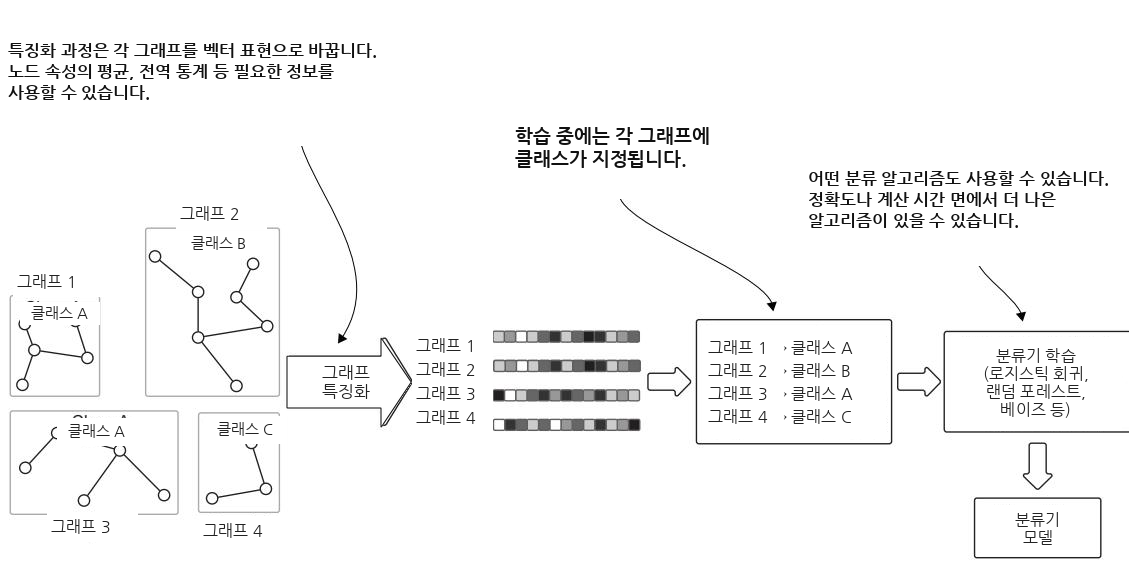

*그림 9.10 — 그래프 분류의 높은 수준 **훈련** 과정. 출력은 서로 다른 그래프들의 알려진 클래스로 훈련된 분류기 모델이다. 그림 9.7 과 나란히 놓고 보면 바뀐 상자가 하나뿐임을 알 수 있다 — `Node featurization` 이 `Graph featurization` 이 되었고, 벡터 한 줄이 노드 하나가 아니라 **그래프 하나** 를 나타낸다. 왼쪽 위 주석은 그래프 특징화가 "필요한 것 무엇이든 — 노드 속성의 평균, 전역 통계 등"을 쓸 수 있다고 적는다.*

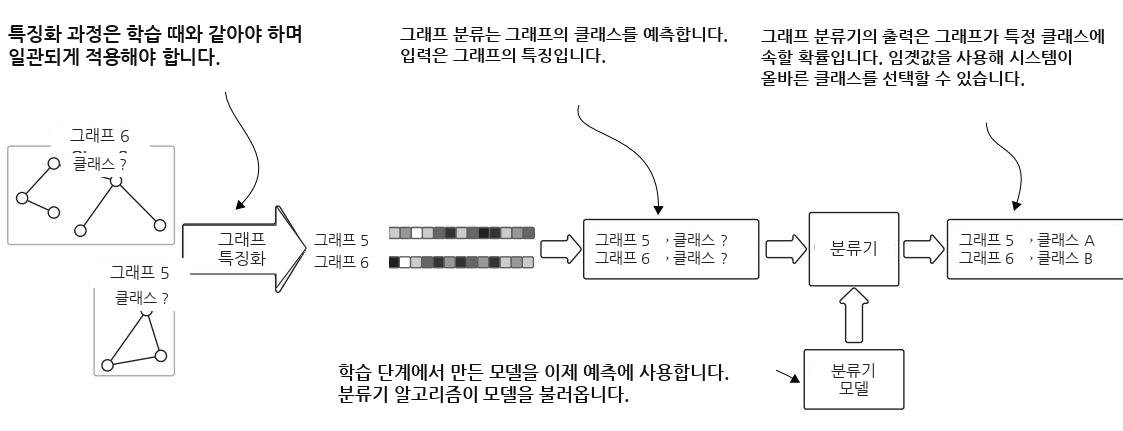

*그림 9.11 — 그래프 분류의 높은 수준 **예측** 과정. 출력은 라벨 없는 그래프들에 배정된 클래스다. 그림 9.8 과 마찬가지로 왼쪽 위 주석이 "특징화 과정은 훈련 때와 같아야 하며 일관돼야 한다"를 반복한다. 이 제약은 노드 수준이든 그래프 수준이든 동일하다.*

다시 한번 분명해지는 것은, **노드·관계·그래프에 대한 특징 추출이 이 과정의 핵심** 이라는 점이다. 그것이 훈련과 예측의 입력을 이루기 때문이다. 정확도를 포함한 최종 출력의 품질은 **이 특징들의 품질** 과 하위 알고리즘 파라미터의 정밀한 튜닝에 크게 좌우된다. 10장과 4부의 나머지 대부분이 이 과제에 집중한다.

> **이 절에는 실행할 코드가 없다.** 책이 그래프 분류에 리스팅을 붙이지 않았다. 여러 그래프로 된 데이터셋이 필요한데(효소 판별용 단백질 그래프 모음 등) 이 장은 그것을 도입하지 않기 때문이다. 그래프 수준 과제의 실제 구현은 12장으로 미뤄진다.


---
#### 9.3.3 그래프 군집화 — 변환 없이 그래프를 바로 나누는 과제

그래프 위의 **모든** ML 과제가 앞 절들의 단계를 필요로 하는 것은 아니다. 그래프 군집화에서는 입력이 그래프 전체(또는 부분 그래프)이고, 알고리즘이 노드와 관계를 **직접** 써서 커뮤니티를 뽑아낸다.

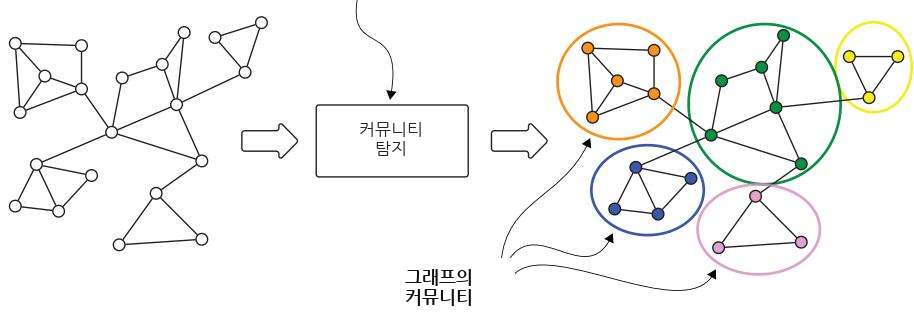

*그림 9.12 — 그래프 군집화의 높은 수준 과정. **순수 그래프 알고리즘 접근** 의 예로, 벡터 표현이나 다른 형식으로의 중간 변환을 필요로 하지 않는다. 책이 9.2.3 절의 그림 9.4 와 **같은 다이어그램을 다시 실었다** — 9.2 절에서는 "이런 과제가 있다"는 소개였고 여기서는 "이 과제는 그림 9.6 오른쪽의 `Node features` 상자가 아예 없다"는 대비가 요점이다.*

이 과제를 앞의 것들과 구별해 주는 측면이 **둘** 이다.

| | 노드 분류 (9.3.1) | **그래프 군집화 (9.3.3)** |
| --- | --- | --- |
| 표현 변환 | 필수 — 노드를 벡터로 바꿔야 한다 | **없다.** 그래프가 그대로 입력이다 |
| 훈련 단계 | 있다 — 라벨로 모델을 만든다 | **없다.** 라벨 같은 예시를 하나도 쓰지 않는다 |
| 학습 유형 | 준지도 | **비지도** |

커뮤니티 탐지 알고리즘도 성격이 갈린다.

| 알고리즘 | 방식 | 성질 |
| --- | --- | --- |
| **약연결 요소**(WCC, weakly connected component) | 고정된 방식. 독립적인 부분 그래프만 고려한다 | 결정적 |
| **Louvain** | **모듈성** 을 최적화한다. 4장에서 다뤘다 | 시드를 고정하면 결정적 |
| **라벨 전파**(LPA, label propagation algorithm) | 라벨을 네트워크 전체로 퍼뜨리고, 마지막에 같은 라벨을 가진 노드를 같은 커뮤니티로 본다. **빠르다** | **무작위성 때문에 일관된 출력을 보장하지 않는다.** 같은 네트워크에 여러 번 돌리면 조금씩 다른 커뮤니티가 나온다 |

책 9.10 은 같은 가라테 클럽 그래프에 **Louvain** 을 돌린다. 코드가 하는 일은 세 줄이다.

```python
communities = nx.community.louvain_communities(G, seed=123)   # 커뮤니티 계산
for community in communities:                                  # 커뮤니티마다
    draw_and_save_graph_picture(G.subgraph(community), i)      # 부분 그래프를 하나씩 그린다
```

파일이 통째로 책 리스팅 9.10 과 일치하므로 아래 셀은 **파일 전체** 를 그대로 실행한다. 그림이 **다섯 장**(전체 그래프 1장 + 커뮤니티 4장) 나온다.

> **`seed=123` 이 결과를 고정한다.** Louvain 은 노드를 훑는 순서에 무작위성이 있어 시드에 따라 커뮤니티가 달라진다. 실제로 `seed=1` 로 바꾸면 커뮤니티 크기가 `10·6·12·6` 에서 `11·5·14·4` 로 달라진다(개수는 4개로 같다). 책이 인쇄한 그림 9.13 은 `seed=123` 의 결과이고, 아래 셀은 그것을 그대로 쓴다.


── 책 Listing 9.10  Running Louvain on the karate club network
   (simple_clustering_example.py  L1-L36  (파일 전체))
    import math
    import time
    import networkx as nx
    import matplotlib.pyplot as plt
    
    def set_club_colors(G):
        for node in G.nodes(data=True):
            # Mr. Hi = 'purple', Officier = 'blue'
            color = '#00fff9'
            if node[1]['club'] == 'Mr. Hi':
                color = '#e6e6fa'
            node[1]['color'] = color
    
    def draw_and_save_graph_picture(G, i=0):
        set_club_colors(G)
        layout_position = nx.spring_layout(G, k=8 / math.sqrt(G.order()))
        colors = [n[1]['color'] for n in G.nodes(data=True)]
        nx.draw_networkx(G, pos=layout_position, node_color=colors)
        plt.axis('off')
        plt.savefig("Karate_Graph_" + str(i) + ".svg", format="SVG", dpi=1000)
        plt.savefig("Karate_Graph_" + str(i) + ".png", format="PNG", dpi=1000)
        plt.show()
    
    if __name__ == '__main__':
    ...

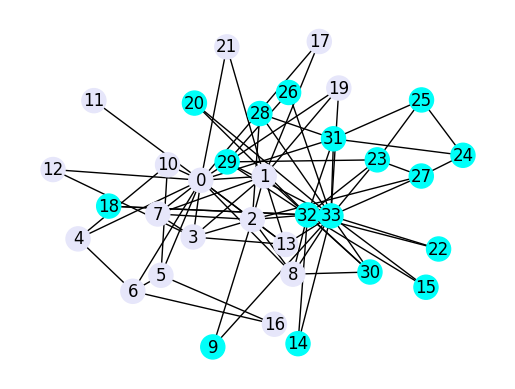

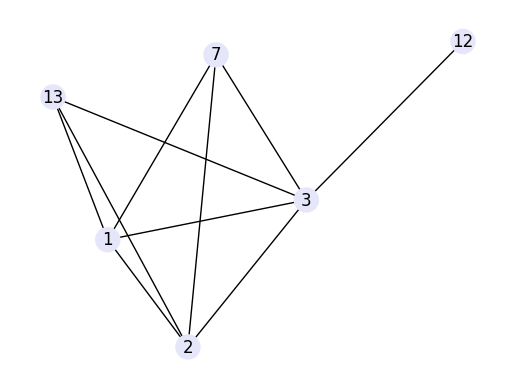

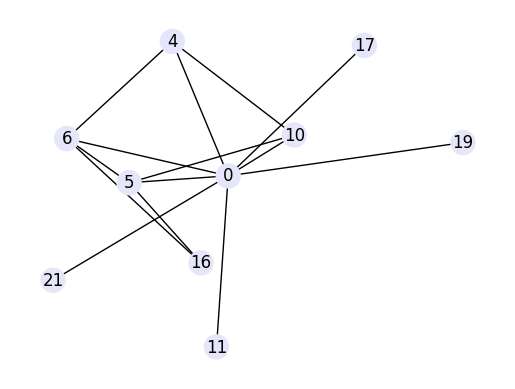

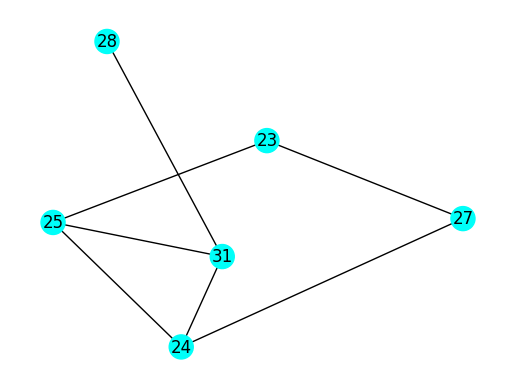

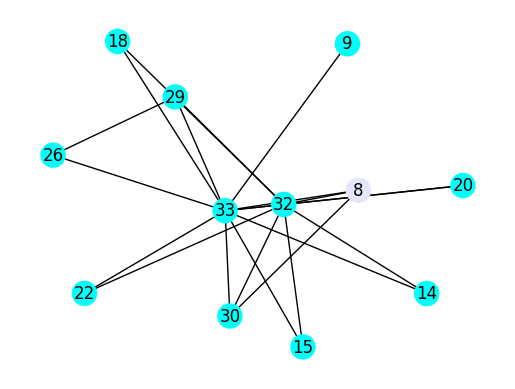

Time to complete: 3.1982688903808594
소요 3.2초 · 리스팅이 저장한 파일 10개 (임시 폴더로 돌렸다)

── Louvain(seed=123) 결과: 커뮤니티 4개 · 모듈성 0.427672
      크기   Mr. Hi  Officer   구성
  c1  10       10        0   순수 · 순도 100%
       [0, 4, 5, 6, 10, 11, 16, 17, 19, 21]
  c2   6        6        0   순수 · 순도 100%
       [1, 2, 3, 7, 12, 13]
  c3  12        1       11   혼합 (소수 1명) · 순도 92%
       [8, 9, 14, 15, 18, 20, 22, 26, 29, 30, 32, 33]
  c4   6        0        6   순수 · 순도 100%
       [23, 24, 25, 27, 28, 31]

  섞여 들어간 노드: [8]

── 책 그림 9.13 의 주장과 대조
  ✓ 커뮤니티를 네 개 찾았다
  ✓ 하나를 뺀 나머지는 모두 같은 그룹 회원만 담고 있다
  ✓ 엉뚱한 노드는 8번 하나다

── 읽는 법
  라벨을 한 번도 쓰지 않고 엣지만 보고 나눴는데, 네 커뮤니티 중 셋이 한 파벌로 순수하다.
  9.2.3 절이 말한 '내부는 촘촘하고 바깥과는 성긴 무리' 가 실제로 파벌 경계와 겹친다는 뜻이다.
  그리고 유일한 예외가 노드 8 이다 — 위 책 9.9 에서 지도 학습이 틀린 바로 그 노드다.
  서로 독립적인 두 방법(준지도 분류 · 비지도 군집화)이 같은 한 명을 짚었다.


In [6]:
"""책 9.10 — 가라테 클럽 네트워크에서 Louvain 을 실행한다.

이 파일은 통째로 책 리스팅 9.10 이므로 runpy 로 파일 전체를 그대로 돌린다.
그림이 다섯 장 나온다 — 전체 그래프 1장 + 커뮤니티 4장(각각 부분 그래프).
Louvain 이 찾은 커뮤니티는 result["communities"] 로 꺼내 아래에서 채점한다.

⏱️ 약 4초. 계산이 아니라 그림이다 — Louvain 자체는 0.001초에 끝나고,
   dpi=1000 SVG·PNG 를 열 번 저장하는 데 거의 전부가 쓰인다.
"""
import runpy
import time

import networkx as nx

show("9.10", head=24)

print(f"\n실행: {CLU}  (파일 전체가 책 9.10 이다)")
print("=" * 78)
started = time.time()
with savefig_to_tmp() as written:
    CLUSTER = runpy.run_path(str(HERE / CLU), run_name="__main__")
elapsed = time.time() - started
print("=" * 78)
print(f"소요 {elapsed:.1f}초 · 리스팅이 저장한 파일 {len(written)}개 (임시 폴더로 돌렸다)")

# ---- 커뮤니티를 채점한다 ------------------------------------------------------
communities = CLUSTER["communities"]
clubs_now = nx.get_node_attributes(G, "club")
modularity = nx.community.modularity(G, communities)

print(f"\n── Louvain(seed=123) 결과: 커뮤니티 {len(communities)}개 · 모듈성 {modularity:.6f}")
print(f"{'':4}{'크기':>4}  {'Mr. Hi':>7}{'Officer':>9}   구성")
mixed = []
for index, community in enumerate(sorted(communities, key=min), 1):
    members = sorted(community)
    member_clubs = [clubs_now[n] for n in members]
    hi, officer = member_clubs.count("Mr. Hi"), member_clubs.count("Officer")
    purity = max(hi, officer) / len(members)
    tag = "순수" if min(hi, officer) == 0 else f"혼합 (소수 {min(hi, officer)}명)"
    if min(hi, officer) > 0:
        minority_club = "Mr. Hi" if hi < officer else "Officer"
        mixed += [n for n in members if clubs_now[n] == minority_club]
    print(f"  c{index}{len(members):>4}  {hi:>7}{officer:>9}   {tag} · 순도 {purity:.0%}")
    print(f"       {members}")

print(f"\n  섞여 들어간 노드: {mixed}")

MEASURED["Louvain(seed=123) 커뮤니티 수"] = len(communities)
MEASURED["Louvain(seed=123) 모듈성"] = round(float(modularity), 6)
MEASURED["Louvain 커뮤니티 크기"] = [len(c) for c in sorted(communities, key=min)]
MEASURED["Louvain 순수하지 않은 커뮤니티의 소수 노드"] = mixed

# ---- 책이 인쇄한 그림 9.13 의 주장과 대조 ------------------------------------
print("\n── 책 그림 9.13 의 주장과 대조")
claims = [
    ("커뮤니티를 네 개 찾았다", len(communities) == 4),
    ("하나를 뺀 나머지는 모두 같은 그룹 회원만 담고 있다",
     sum(1 for c in communities
         if len({clubs_now[n] for n in c}) > 1) == 1),
    ("엉뚱한 노드는 8번 하나다", mixed == [8]),
]
for text, ok in claims:
    print(f"  {'✓' if ok else '✗'} {text}")

print("\n── 읽는 법")
print("  라벨을 한 번도 쓰지 않고 엣지만 보고 나눴는데, 네 커뮤니티 중 셋이 한 파벌로 순수하다.")
print("  9.2.3 절이 말한 '내부는 촘촘하고 바깥과는 성긴 무리' 가 실제로 파벌 경계와 겹친다는 뜻이다.")
print("  그리고 유일한 예외가 노드 8 이다 — 위 책 9.9 에서 지도 학습이 틀린 바로 그 노드다.")
print("  서로 독립적인 두 방법(준지도 분류 · 비지도 군집화)이 같은 한 명을 짚었다.")


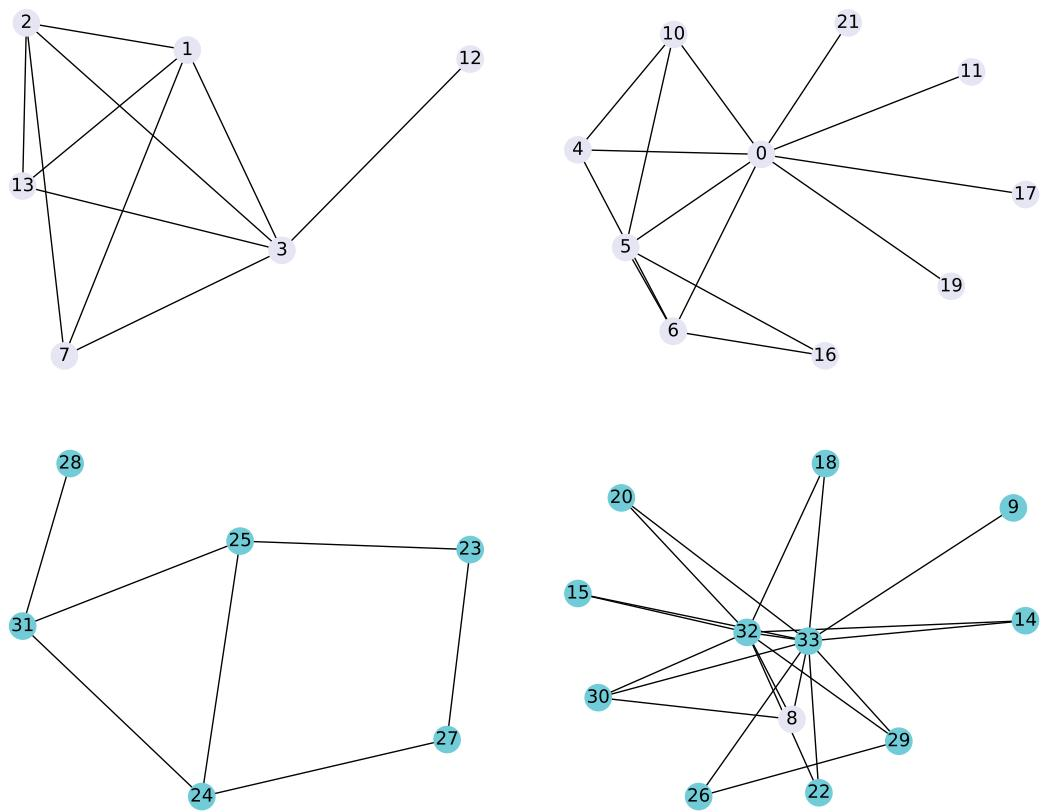

*그림 9.13 — 가라테 클럽 네트워크에 커뮤니티 탐지 알고리즘을 적용한 결과. 알고리즘은 네 개의 커뮤니티를 찾아냈고, **하나를 뺀 나머지는 모두 같은 그룹 회원만** 담고 있다. 엉뚱한 노드가 하나 있지만(오른쪽 아래 밝은 음영의 8번) 그 노드는 다른 그룹에 속한 사람들과 잘 연결되어 있다. 위 셀의 출력과 나란히 보라 — 커뮤니티 구성원 목록이 네 덩어리 모두 일치한다. 즉 `networkx` 3.4.2 의 `louvain_communities(G, seed=123)` 이 책 집필 시점과 **같은 분할** 을 낸다. **데이터 드리프트가 없다.***

책은 이 결과를 이렇게 요약한다 — 알고리즘이 "같은 커뮤니티 안 다른 노드들과는 잘 연결되고 커뮤니티 밖 노드들과는 성기게 연결된 노드 무리를 훌륭하게 식별했다." 그리고 노드 8 을 두고 농담을 남긴다. *"어쩌면 이 사람은 엉뚱한 그룹에 있는 건지도 모르겠습니다!"*

이 농담이 이 장의 마지막 통찰이다. 두 방법이 **서로 완전히 독립적으로** 같은 결론에 도달했다.

| | 방법 | 라벨을 쓰나 | 노드 8 에 대한 판정 |
| --- | --- | --- | --- |
| **9.3.1** 노드 분류 | 세 차수 특징 + 로지스틱 회귀 | **이웃의 라벨을 쓴다**(준지도) | Officer 로 예측 → **오답** (정답은 Mr. Hi) |
| **9.3.3** 커뮤니티 탐지 | Louvain (모듈성 최적화) | **전혀 쓰지 않는다**(비지도) | Officer 들만 있는 커뮤니티에 배치 |

노드 8 의 이웃은 `[0, 2, 30, 32, 33]` — Mr. Hi 2명, Officer 3명이다. 구조만 보면 이 사람은 Officer 쪽 사람이다. 그런데 실제로는 Mr. Hi 를 따라갔다. **모델이 실패한 것이 아니라 네트워크 구조에 없는 정보(개인적 충성심, 사범과의 사적 관계 등)로 결정된 사례다.** 구조 기반 예측의 상한을 보여 주는 지점이고, 이것이 9.2.1 절이 말한 **이종선호**(heterophily)의 한 사례이기도 하다.


---
## 실습 — 이 장의 주장을 직접 재 본다

**해설판에 Exercise 가 둘 있다.** 9장은 이론 장이면서도 코드가 있어 3\~4장처럼 명시적 연습 문제가 실려 있다. 둘 다 구현했고, 여기에 하나를 더 설계했다.

| 실습 | 출처 | 확인하는 주장 | 근거 절 | 비용 |
| --- | --- | --- | --- | --- |
| **9-A** | **책의 연습 문제** (리스팅 9.2 뒤 박스) — *"다른 두 지표를 써 보세요. Mr. Hi 의 이웃들의 차수와 John A 의 이웃들의 차수"* | 이웃의 소속을 특징에 넣으면 성능이 오른다. 그리고 그 이유가 **동종선호가 데이터에 실제로 있기 때문** 이다 | 9.2.1(동종선호) · 9.3.1(리스팅 9.2 → 9.8) | 4초 |
| **9-B** | **책의 연습 문제** (9.3.1 절 끝 원리 ②) — *"`walk_length` 와 `num_walks` 를 더 낮은 값으로 두고 실험을 돌려 보세요"* | 자율 임베딩은 튜닝을 요구한다. 더 많이 걷는 것이 항상 좋지는 않다. 그리고 **`seed=0` 은 재현성을 보장하지 못한다** | 9.3.1(원리 ②) · 책 9.3 | **약 15초** |
| **9-C** | **직접 설계** | 지도 학습의 유일한 오답(노드 8)과 비지도 군집화의 유일한 이상점이 **같은 노드** 이고, 그것이 우연이 아니다 | 9.3.1(책 9.9) · 9.3.3(그림 9.13) | 1초 미만 |

**9-C 를 고른 근거.** 책과 해설판은 노드 8 을 두 곳에서 각각 언급하지만 **둘을 연결하지 않는다.** 9.3.1 절은 "예측 라벨이 정답과 딱 한 곳만 다르다"고만 적고 그 한 곳이 어느 노드인지 밝히지 않으며, 9.3.3 절은 "엉뚱한 노드(8번)"라고 하면서 그것이 위쪽 오분류와 같은 노드라는 사실을 짚지 않는다. 두 절을 잇는 것이 이 장의 핵심 메시지("구조가 라벨을 얼마나 설명하는가")를 가장 선명하게 만든다고 판단했다. 책의 실습 번호가 아니므로 `9-A`·`9-B`·`9-C` 로 붙였다.


### 실습 9-A — 세 가지 특징화를 한 표에 놓기 (책의 연습 문제)

책의 연습 문제는 이렇다.

> *"이 기법은 기초적이지만, 노드의 차수만으로는 우리 목표(어느 클럽인지 맞히기)에 큰 도움이 되지 않을 수 있습니다. 연습 삼아, 다른 두 지표를 써 보세요. **Mr. Hi 의 이웃들의 차수와 John A 의 이웃들의 차수** 입니다. 이 지표들은 알고리즘이 어떤 노드가 어느 그룹에 속하는지 분별하는 데 더 많은 통찰을 줍니다."*

해답은 리스팅 9.8 이고 위에서 이미 실행했다. 이 실습은 거기서 두 걸음 더 나간다.

**① 세 특징화를 같은 표에 놓는다.** 위에서는 9.7 과 9.9 를 따로 봤다. 한 표에 모으면 차원 수와 성능이 비례하지 않는다는 것이 눈에 들어온다.

**② 세 칸 벡터가 왜 통하는지 데이터로 확인한다.** "동종선호가 있으니 잘 될 것"은 가설이다. 실제로 그런지 재려면 **라벨 없이 규칙 하나로 예측** 해 보면 된다.

$$\hat{y}_i = \begin{cases} \text{Mr. Hi} & \text{if } d^{\mathrm{Hi}}_i > d^{\mathrm{Off}}_i \\ \text{Officer} & \text{otherwise} \end{cases}$$

| 기호 | 뜻 |
| --- | --- |
| $\hat{y}_i$ | 노드 $i$ 에 대한 예측 |
| $d^{\mathrm{Hi}}_i$ | 노드 $i$ 의 이웃 중 `club == 'Mr. Hi'` 인 수 (= 리스팅 9.8 의 `mr_hi_degree`) |
| $d^{\mathrm{Off}}_i$ | 노드 $i$ 의 이웃 중 `club == 'Officer'` 인 수 (= `officer_degree`) |

학습이 전혀 없는 **다수결 규칙** 이다. 이것이 34명 전원에 대해 몇 명을 맞히는지가 곧 "이 데이터에 동종선호가 얼마나 강하게 있는가"의 지표다. 로지스틱 회귀가 배우는 것도 결국 이 경계에 가깝다면, 성능 상승의 출처가 분류기가 아니라 **특징 그 자체** 라는 뜻이 된다.

**③ 특징 벡터 34개를 전부 인쇄한다.** 세 칸 벡터가 어떻게 생겼는지 눈으로 보면 왜 통하는지가 분명해진다.


In [7]:
"""실습 9-A — 세 특징화를 한 표에 놓고, 세 칸 벡터가 통하는 이유를 데이터로 확인한다.

책 리스팅을 다시 쓰지 않는다. 세 임베딩 함수는 전부 저장소 것(CLASSIFY.compute_*)을
그대로 부르고, 학습·평가도 위에서 만든 run_pipeline(= 책 9.6 의 여섯 줄)을 쓴다.
이 셀이 새로 하는 것은 결과를 나란히 놓는 것과 다수결 규칙 한 줄뿐이다.

⏱️ 약 4초. Node2Vec 재학습이 대부분이다.
"""
import networkx as nx

# ---- ① 세 특징화를 한 표에 --------------------------------------------------
FEATURIZATIONS = [
    ("책 9.2  [차수]", CLASSIFY.compute_degree_embeddings, "손으로 만든 1차원"),
    ("책 9.3  Node2Vec", CLASSIFY.compute_complex_embeddings, "자율 학습 64차원 (비결정적)"),
    ("책 9.8  [차수, Hi 이웃, Off 이웃]", CLASSIFY.compute_specific_degree_embeddings,
     "도메인 지식 3차원"),
]

print(f"{'특징화':<34}{'차원':>4}{'P':>9}{'R':>9}{'F1':>9}  {'혼동행렬':<18}성격")
comparison = {}
for label, embed_fn, note in FEATURIZATIONS:
    result = run_pipeline(embed_fn(G))
    comparison[label] = {"차원": result["dims"], "P": round(result["precision"], 4),
                         "R": round(result["recall"], 4), "F1": round(result["f1"], 4),
                         "혼동": result["confusion"]}
    print(f"{label:<34}{result['dims']:>4}{result['precision']:>9.4f}{result['recall']:>9.4f}"
          f"{result['f1']:>9.4f}  {str(result['confusion']):<18}{note}")

print("\n  차원이 64 -> 3 으로 줄었는데 F1 이 올랐다. 특징의 '개수' 가 아니라")
print("  '무엇을 담았는가' 가 결과를 정한다는 뜻이다.")
print("  ⚠️ Node2Vec 행만 실행마다 달라진다 (workers=4). 나머지 두 행은 결정적이다.")

# ---- ② 동종선호가 실제로 있는가 — 학습 없는 다수결 규칙 -----------------------
clubs_a = nx.get_node_attributes(G, "club")
three = CLASSIFY.compute_specific_degree_embeddings(G)

hits, violations = 0, []
for node in G.nodes():
    _, hi_degree, officer_degree = three[node]
    rule_says_hi = hi_degree > officer_degree          # 동점이면 Officer 로 본다
    truth_is_hi = clubs_a[node] == "Mr. Hi"
    if rule_says_hi == truth_is_hi:
        hits += 1
    else:
        violations.append(node)

print(f"\n── 다수결 규칙(학습 없음): 이웃 중 Mr. Hi 가 더 많으면 Mr. Hi 로 예측")
print(f"   34명 전원 대상 정확도: {hits}/34 = {hits / 34:.1%}")
print(f"   규칙을 어기는 노드: {violations}")
for node in violations:
    total, hi_degree, officer_degree = three[node]
    print(f"     노드 {node}: 이웃 Mr. Hi {hi_degree}명 / Officer {officer_degree}명"
          f" (총 차수 {total}) 인데 실제 소속은 {clubs_a[node]}")

print("\n   학습을 하나도 하지 않은 규칙 한 줄이 이 정확도를 낸다. 즉 로지스틱 회귀가")
print("   똑똑해서 0.93 이 나온 것이 아니라, 특징 안에 이미 답이 거의 들어 있었다.")
print("   9.2.1 절의 '동종선호' 가 이 데이터에 실재한다는 정량적 증거다.")

# ---- ③ 특징 벡터 34개 전부 --------------------------------------------------
print("\n── 리스팅 9.8 이 만든 특징 벡터 (노드: [총차수, Mr.Hi 이웃 수, Officer 이웃 수])")
print(f"   {'노드':>4}  {'벡터':<16}{'실제 소속':<10}{'규칙 예측':<10}판정")
for node in G.nodes():
    total, hi_degree, officer_degree = three[node]
    predicted = "Mr. Hi" if hi_degree > officer_degree else "Officer"
    mark = "  " if predicted == clubs_a[node] else "  ← 어긋남"
    print(f"   {node:>4}  {str([total, hi_degree, officer_degree]):<16}"
          f"{clubs_a[node]:<10}{predicted:<10}{mark}")

MEASURED["실습 9-A 세 특징화 비교"] = comparison
MEASURED["실습 9-A 다수결 규칙 정확도 (34명 전원)"] = f"{hits}/34 = {hits / 34:.1%}"
MEASURED["실습 9-A 동종선호를 어기는 노드"] = violations


특징화                                 차원        P        R       F1  혼동행렬              성격
책 9.2  [차수]                          1   0.4464   0.4286   0.4286  [[3, 3], [5, 3]]  손으로 만든 1차원


Computing transition probabilities:   0%|          | 0/34 [00:00<?, ?it/s]

Computing transition probabilities: 100%|██████████| 34/34 [00:00<00:00, 18806.06it/s]


Generating walks (CPU: 1): 100%|██████████| 50/50 [00:00<00:00, 516.25it/s]


책 9.3  Node2Vec                     64   0.7440   0.7143   0.7143  [[5, 1], [3, 5]]  자율 학습 64차원 (비결정적)
책 9.8  [차수, Hi 이웃, Off 이웃]           3   0.9365   0.9286   0.9274  [[5, 1], [0, 8]]  도메인 지식 3차원

  차원이 64 -> 3 으로 줄었는데 F1 이 올랐다. 특징의 '개수' 가 아니라
  '무엇을 담았는가' 가 결과를 정한다는 뜻이다.
  ⚠️ Node2Vec 행만 실행마다 달라진다 (workers=4). 나머지 두 행은 결정적이다.

── 다수결 규칙(학습 없음): 이웃 중 Mr. Hi 가 더 많으면 Mr. Hi 로 예측
   34명 전원 대상 정확도: 33/34 = 97.1%
   규칙을 어기는 노드: [8]
     노드 8: 이웃 Mr. Hi 2명 / Officer 3명 (총 차수 5) 인데 실제 소속은 Mr. Hi

   학습을 하나도 하지 않은 규칙 한 줄이 이 정확도를 낸다. 즉 로지스틱 회귀가
   똑똑해서 0.93 이 나온 것이 아니라, 특징 안에 이미 답이 거의 들어 있었다.
   9.2.1 절의 '동종선호' 가 이 데이터에 실재한다는 정량적 증거다.

── 리스팅 9.8 이 만든 특징 벡터 (노드: [총차수, Mr.Hi 이웃 수, Officer 이웃 수])
     노드  벡터              실제 소속     규칙 예측     판정
      0  [16, 15, 1]     Mr. Hi    Mr. Hi      
      1  [9, 8, 1]       Mr. Hi    Mr. Hi      
      2  [10, 6, 4]      Mr. Hi    Mr. Hi      
      3  [6, 6, 0]       Mr. Hi    Mr. Hi      
      4  [3, 3, 0]       Mr. Hi    Mr. Hi      
      5  [4, 4

### 실습 9-B — Node2Vec 튜닝과 재현성 (책의 연습 문제)

책이 9.3.1 절 끝의 원리 ②에서 던지는 연습이다.

> *"자율 임베딩은 신중한 튜닝을 요구합니다. Node2Vec 같은 방법은 강력하지만 최적 결과를 보장하지는 않습니다. 지나치게 균질한(overly homogeneous) 노드 표현이 만들어지지 않도록 파라미터를 사려 깊게 설정해야 합니다. **연습 삼아, `walk_length` 와 `num_walks` 를 더 낮은 값으로 두고 실험을 돌려 보세요.**"*

여기에 하나를 덧붙인다 — **책 9.3 의 주석이 "랜덤 시드로 결과의 재현성을 보장합니다"라고 적은 것이 사실인지 확인한다.**

#### ① `walk_length` · `num_walks` 격자

두 인자가 하는 일은 이렇다.

| 인자 | 뜻 | 키우면 | 줄이면 |
| --- | --- | --- | --- |
| `walk_length` | 랜덤 워크 한 번이 방문하는 노드 수 | 멀리까지 이어진 경로를 본다. 지름이 5 인 그래프에서 30 은 **그래프를 여러 바퀴 도는 길이** 다 | 출발점 근처만 본다 |
| `num_walks` | 노드마다 시작하는 워크 개수 | 학습 말뭉치가 커진다 | 말뭉치가 작아진다 |

책의 설정은 `walk_length=30, num_walks=200` 이다. 34노드·지름 5 짜리 그래프에서 길이 30 짜리 워크를 노드당 200번 하면 총 `34 × 200 × 30 = 204,000` 개의 노드 방문이 생긴다. **엣지가 78개인 그래프에 대해 지나치게 많다.** 워크가 길면 그래프 전체를 골고루 훑게 되어 모든 노드의 문맥이 서로 닮아 가는데, 이것이 책이 말한 **"지나치게 균질한 표현"** 이다. 그래서 값을 낮추면 오히려 좋아질 수 있다는 것이 이 연습의 요점이다.

#### ② `seed=0` 은 재현성을 보장하는가

**보장하지 못한다.** `Node2Vec(..., workers=4)` 는 `gensim` 의 Word2Vec 을 네 스레드로 학습시키는데, 스레드가 학습 예시를 소비하는 순서가 스케줄링에 따라 달라지므로 가중치 갱신 순서가 실행마다 바뀐다. 시드는 **초기값** 만 고정할 뿐 **갱신 순서** 는 고정하지 못한다.

이 실습은 같은 설정을 `workers=1` 과 `workers=4` 로 각각 두 번씩 돌려 임베딩 행렬이 **비트 단위로 같은지** 확인한다. `workers=1` 이면 스레드가 하나뿐이라 순서가 결정되므로 재현성이 회복될 것이다.

> **왜 이것이 중요한가.** 위 책 9.7 의 Node2Vec 블록이 책 인쇄값과 다른 이유가 바로 이것이다. 데이터가 바뀐 것도, 라이브러리 버전 탓도 아니다. 실습을 재현하려는 스터디원이 "내 값이 왜 책과 다르지" 하고 환경을 의심하는 일을 막으려면 이 사실을 먼저 알아야 한다. **재현 가능한 실험이 필요하면 `workers=1` 로 두라.**


In [8]:
"""실습 9-B — walk_length·num_walks 격자, 그리고 seed 가 재현성을 주지 못한다는 실측.

책 9.3 의 리스팅을 다시 쓰는 것이 아니다. 리스팅은 위에서 저장소 함수를 그대로
호출했고, 여기서는 같은 라이브러리를 같은 그래프에 **다른 하이퍼파라미터로** 적용해
본문의 주장(튜닝이 필요하다 · 시드로는 부족하다)을 수치로 확인한다.
학습·평가는 위에서 만든 run_pipeline(= 책 9.6)을 그대로 쓴다.

⏱️ 약 15초. Node2Vec 을 여덟 번 재학습한다.
   격자는 workers=1 로 돌린다 — 이 실습의 목적이 설정 간 비교인데 workers=4 면
   비결정성이 차이를 덮어버리기 때문이다. 재현성 검증만 workers 를 바꿔 가며 본다.
"""
import time

import numpy as np
from node2vec import Node2Vec

BOOK_WALK_LENGTH, BOOK_NUM_WALKS = 30, 200


def embed_node2vec(walk_length: int, num_walks: int, workers: int = 1):
    """책 9.3 과 나머지 인자를 똑같이 두고 두 값만 바꾼다."""
    node2vec = Node2Vec(G, dimensions=64, walk_length=walk_length, num_walks=num_walks,
                        workers=workers, seed=SEED, quiet=True)
    model = node2vec.fit(window=10, min_count=1, batch_words=4, seed=SEED)
    return [model.wv.get_vector(i) for i in G.nodes]


# ---- ① 격자 (workers=1 로 고정해 설정 간 비교를 깨끗하게 만든다) ---------------
GRID = [
    (BOOK_WALK_LENGTH, BOOK_NUM_WALKS, "책 설정"),
    (20, 100, "절반쯤"),
    (10, 20, "책이 권한 '더 낮은 값'"),
    (5, 10, "극단적으로 낮게"),
    (80, 400, "반대로 크게 (참고)"),
]

print(f"{'walk_length':>12}{'num_walks':>11}{'방문 수':>10}{'P':>9}{'R':>9}{'F1':>9}{'초':>7}  설명")
grid_rows = {}
for walk_length, num_walks, note in GRID:
    started = time.time()
    result = run_pipeline(embed_node2vec(walk_length, num_walks))
    seconds = time.time() - started
    visits = G.number_of_nodes() * num_walks * walk_length
    grid_rows[f"wl={walk_length},nw={num_walks}"] = {
        "F1": round(result["f1"], 4), "P": round(result["precision"], 4),
        "R": round(result["recall"], 4), "혼동": result["confusion"]}
    print(f"{walk_length:>12}{num_walks:>11}{visits:>10,}{result['precision']:>9.4f}"
          f"{result['recall']:>9.4f}{result['f1']:>9.4f}{seconds:>7.1f}  {note}")

best = max(grid_rows, key=lambda k: grid_rows[k]["F1"])
book_key = f"wl={BOOK_WALK_LENGTH},nw={BOOK_NUM_WALKS}"
print(f"\n  최고 F1: {best} ({grid_rows[best]['F1']:.4f})"
      f"  vs  책 설정 {book_key} ({grid_rows[book_key]['F1']:.4f})")
print("  값을 낮추면 좋아지지만 끝없이 낮추면 다시 나빠진다 — 최적점이 중간에 있다.")
print("  단조롭지 않다는 것이 곧 '신중한 튜닝을 요구한다' 의 뜻이다.")
print(f"  그래도 세 칸 벡터(F1 {three_result['f1']:.4f})에는 어느 설정도 미치지 못한다.")

# ---- ② seed 가 재현성을 주는가 -----------------------------------------------
print("\n── seed 재현성 검증 (같은 설정을 두 번씩 돌려 임베딩 행렬을 비교)")
print("   책 9.3 의 주석: 'a random seed ensures reproducible results'")
reproducible = {}
for workers in (1, 4):
    first = np.asarray(embed_node2vec(10, 20, workers=workers))
    second = np.asarray(embed_node2vec(10, 20, workers=workers))
    identical = bool(np.array_equal(first, second))
    max_gap = float(np.abs(first - second).max())
    reproducible[f"workers={workers}"] = identical
    print(f"   workers={workers}: 두 번의 임베딩이 완전히 동일한가? "
          f"{'예 ✓' if identical else '아니오 ✗'}   (최대 절대 차이 {max_gap:.6f})")

print("\n   -> workers=4(책의 설정)에서는 seed 를 고정해도 결과가 달라진다.")
print("      gensim 이 네 스레드로 학습해 가중치 갱신 '순서' 가 실행마다 바뀌기 때문이다.")
print("      시드는 초기값만 고정할 뿐 순서는 고정하지 못한다.")
print("      workers=1 로 두면 재현된다. 큰 그래프에서는 그만큼 느려지지만 34노드에서는")
print("      오히려 workers=1 이 빠르다 — 스레드 조율 비용이 계산보다 크기 때문이다.")
print("      **책 9.3 의 주석은 workers>1 에서 성립하지 않는다.**")

MEASURED["실습 9-B walk_length·num_walks 격자 (workers=1)"] = grid_rows
MEASURED["실습 9-B 최고 F1 설정"] = f"{best} → {grid_rows[best]['F1']:.4f}"
MEASURED["실습 9-B seed 재현성 (임베딩 완전 일치 여부)"] = reproducible


 walk_length  num_walks      방문 수        P        R       F1      초  설명


          30        200   204,000   0.7214   0.7143   0.7016    1.3  책 설정


          20        100    68,000   0.8442   0.7857   0.7669    0.6  절반쯤
          10         20     6,800   0.7959   0.7857   0.7868    0.1  책이 권한 '더 낮은 값'


           5         10     1,700   0.5476   0.5714   0.5071    0.1  극단적으로 낮게


          80        400 1,088,000   0.6494   0.6429   0.6115    4.8  반대로 크게 (참고)

  최고 F1: wl=10,nw=20 (0.7868)  vs  책 설정 wl=30,nw=200 (0.7016)
  값을 낮추면 좋아지지만 끝없이 낮추면 다시 나빠진다 — 최적점이 중간에 있다.
  단조롭지 않다는 것이 곧 '신중한 튜닝을 요구한다' 의 뜻이다.
  그래도 세 칸 벡터(F1 0.9274)에는 어느 설정도 미치지 못한다.

── seed 재현성 검증 (같은 설정을 두 번씩 돌려 임베딩 행렬을 비교)
   책 9.3 의 주석: 'a random seed ensures reproducible results'


   workers=1: 두 번의 임베딩이 완전히 동일한가? 예 ✓   (최대 절대 차이 0.000000)


   workers=4: 두 번의 임베딩이 완전히 동일한가? 아니오 ✗   (최대 절대 차이 0.185885)

   -> workers=4(책의 설정)에서는 seed 를 고정해도 결과가 달라진다.
      gensim 이 네 스레드로 학습해 가중치 갱신 '순서' 가 실행마다 바뀌기 때문이다.
      시드는 초기값만 고정할 뿐 순서는 고정하지 못한다.
      workers=1 로 두면 재현된다. 큰 그래프에서는 그만큼 느려지지만 34노드에서는
      오히려 workers=1 이 빠르다 — 스레드 조율 비용이 계산보다 크기 때문이다.
      **책 9.3 의 주석은 workers>1 에서 성립하지 않는다.**


### 실습 9-C — 노드 8 은 왜 두 번 틀렸나 (직접 설계)

책과 해설판은 노드 8 을 **두 곳에서 따로** 언급한다.

| 절 | 무슨 말을 하나 | 무슨 말을 하지 않나 |
| --- | --- | --- |
| 9.3.1 (책 9.9) | *"예측 라벨이 정답과 딱 한 곳(마지막)만 다르고, 혼동 행렬도 오분류가 단 1건뿐입니다"* | **그 한 곳이 어느 노드인지 밝히지 않는다** |
| 9.3.3 (그림 9.13) | *"딱 한 경우에만 엉뚱한 노드(8번)가 있는데... 어쩌면 이 사람은 엉뚱한 그룹에 있는 건지도 모르겠습니다!"* | **위쪽 오분류와 같은 노드라는 사실을 짚지 않는다** |

두 절을 이으면 이 장의 핵심 메시지가 선명해진다 — **구조가 라벨을 얼마나 설명하는가, 그리고 설명하지 못하는 지점은 어디인가.** 그래서 이 실습을 설계했다. 확인할 것은 넷이다.

| # | 확인 | 방법 |
| --- | --- | --- |
| ① | 노드 8 은 정말 **가장 모호한** 노드인가 | 34명 전원에 대해 **동종선호 마진** 을 계산해 순위를 매긴다 |
| ② | 지도(9.3.1)와 비지도(9.3.3)가 정말 같은 노드를 짚었나 | 세 신호(실제 라벨 · 세 차수 규칙 · Louvain 커뮤니티 다수)를 노드별로 나란히 놓는다 |
| ③ | 학습된 분류기는 34명 전원을 어떻게 보나 | 훈련된 모델로 전체 노드를 예측한다 (테스트 14개만이 아니라) |
| ④ | 노드 8 이 없다면 성능의 **천장** 은 어디인가 | 노드 8 의 라벨을 뒤집어 파이프라인을 다시 돌린다 |

**동종선호 마진** 은 이렇게 정의한다.

$$m_i = \frac{d^{\mathrm{own}}_i - d^{\mathrm{other}}_i}{\deg(i)}$$

| 기호 | 뜻 |
| --- | --- |
| $m_i$ | 노드 $i$ 의 동종선호 마진. 값의 범위는 $[-1, 1]$ |
| $d^{\mathrm{own}}_i$ | 노드 $i$ 의 이웃 중 **자신과 같은** 클럽인 수 |
| $d^{\mathrm{other}}_i$ | 노드 $i$ 의 이웃 중 **다른** 클럽인 수 |
| $\deg(i)$ | 노드 $i$ 의 총 차수 |

$m_i = 1$ 이면 이웃이 전부 같은 편이고(완전한 동종선호), $m_i = 0$ 이면 반반, $m_i < 0$ 이면 **이웃 다수가 반대편** 이다. 음수인 노드가 구조와 라벨이 어긋나는 노드다.

> **④ 는 사고 실험이지 데이터 수정이 아니다.** 실제로 노드 8 의 소속을 바꾸는 것이 아니라, "구조에 담긴 정보만으로 도달할 수 있는 상한이 어디인가"를 재기 위해 라벨을 한 칸 뒤집어 보는 것이다. 원본 그래프 `G` 는 건드리지 않고 라벨 배열의 사본을 쓴다.


In [9]:
"""실습 9-C — 노드 8 이 지도·비지도 양쪽에서 유일한 예외인 이유를 수치로 확인한다.

새 알고리즘을 쓰지 않는다. 위에서 이미 얻은 것들만 조합한다.
  * CLASSIFY.compute_specific_degree_embeddings (책 9.8)
  * run_pipeline (책 9.6)
  * CLUSTER["communities"] (책 9.10 의 Louvain 결과)
원본 그래프 G 와 라벨 LABELS 는 건드리지 않는다 — 사본에만 손댄다.

⏱️ 1초 미만. 학습은 ④ 에서 한 번뿐이고 세 차수 특징이라 즉시 끝난다.
"""
import networkx as nx

clubs_c = nx.get_node_attributes(G, "club")
three_c = CLASSIFY.compute_specific_degree_embeddings(G)

# ---- ① 동종선호 마진 --------------------------------------------------------
margins = {}
for node in G.nodes():
    total, hi_degree, officer_degree = three_c[node]
    own = hi_degree if clubs_c[node] == "Mr. Hi" else officer_degree
    other = officer_degree if clubs_c[node] == "Mr. Hi" else hi_degree
    margins[node] = (own - other) / total

ranked = sorted(margins.items(), key=lambda pair: pair[1])
print("── ① 동종선호 마진이 낮은 순 (아래일수록 이웃이 반대편에 몰려 있다)")
print(f"   {'노드':>4}{'마진':>8}{'차수':>6}  {'소속':<9}이웃 구성")
for node, margin in ranked[:8]:
    total, hi_degree, officer_degree = three_c[node]
    flag = "  ← 음수: 이웃 다수가 반대편" if margin < 0 else ("  ← 0: 반반" if margin == 0 else "")
    print(f"   {node:>4}{margin:>8.3f}{total:>6}  {clubs_c[node]:<9}"
          f"Hi {hi_degree} / Off {officer_degree}{flag}")

negatives = [n for n, m in margins.items() if m < 0]
zeros = [n for n, m in margins.items() if m == 0]
print(f"\n   마진이 음수인 노드: {negatives}   마진이 0 인 노드: {zeros}")
print(f"   34명 중 {len(negatives)}명만 음수다. 이 그래프의 동종선호는 거의 완벽하고,")
print(f"   그 유일한 예외가 노드 {negatives[0] if negatives else '-'}번이다.")

# ---- ② 세 신호를 나란히 -----------------------------------------------------
community_of = {}
community_majority = {}
for index, community in enumerate(sorted(CLUSTER["communities"], key=min), 1):
    member_clubs = [clubs_c[n] for n in community]
    majority = "Mr. Hi" if member_clubs.count("Mr. Hi") >= member_clubs.count("Officer") else "Officer"
    for node in community:
        community_of[node] = index
        community_majority[node] = majority

print("\n── ② 세 신호 대조 (실제 라벨 · 세 차수 다수결 · Louvain 커뮤니티 다수)")
print(f"   {'노드':>4}  {'실제':<9}{'세차수규칙':<11}{'Louvain(c#)':<14}판정")
disagree_rule, disagree_louvain = [], []
for node in G.nodes():
    _, hi_degree, officer_degree = three_c[node]
    rule = "Mr. Hi" if hi_degree > officer_degree else "Officer"
    louvain = community_majority[node]
    marks = []
    if rule != clubs_c[node]:
        marks.append("규칙✗")
        disagree_rule.append(node)
    if louvain != clubs_c[node]:
        marks.append("Louvain✗")
        disagree_louvain.append(node)
    if marks:
        print(f"   {node:>4}  {clubs_c[node]:<9}{rule:<11}{louvain + f' (c{community_of[node]})':<14}"
              f"{' · '.join(marks)}")

print(f"\n   세 차수 규칙이 어긋나는 노드   : {disagree_rule}")
print(f"   Louvain 이 어긋나는 노드       : {disagree_louvain}")
both = sorted(set(disagree_rule) & set(disagree_louvain))
print(f"   **양쪽 모두 어긋나는 노드**    : {both}")
print("   지도(이웃 라벨 사용)와 비지도(엣지만 사용)가 서로 독립인데 같은 노드를 짚었다.")

# ---- ③ 학습된 분류기가 34명 전원을 어떻게 보나 -------------------------------
from sklearn.model_selection import train_test_split
import pandas as pd

frame_c = pd.DataFrame({"nodeId": list(G.nodes), "embeddings": three_c, "label": LABELS})
train_c, _ = train_test_split(frame_c, test_size=0.4, random_state=SEED)
model_c = CLASSIFY.EvaluateEmbedding()
model_c.train(train_c)
all_predicted = model_c.model.predict(model_c.scaler.transform(list(three_c)))
wrong_all = [int(n) for n in G.nodes() if all_predicted[n] != LABELS[n]]
print(f"\n── ③ 훈련된 모델로 34명 전원 예측 (훈련 20명 포함)")
print(f"   전체 정확도 {34 - len(wrong_all)}/34 = {(34 - len(wrong_all)) / 34:.1%}"
      f" · 틀린 노드 {wrong_all}")
print("   훈련에 쓴 노드까지 포함해도 틀리는 노드가 이것뿐이다. 모델이 노드 8 을")
print("   외우지도 못한다는 뜻 — 특징 공간에서 이 노드는 Officer 영역에 있다.")

# ---- ④ 노드 8 이 없다면 천장은 어디인가 --------------------------------------
FLIP = both[0] if both else 8
flipped = LABELS.copy()
flipped[FLIP] = 1 - flipped[FLIP]

frame_f = pd.DataFrame({"nodeId": list(G.nodes), "embeddings": three_c, "label": flipped})
train_f, test_f = train_test_split(frame_f, test_size=0.4, random_state=SEED)
model_f = CLASSIFY.EvaluateEmbedding()
model_f.train(train_f)
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

gold_f = test_f.label.values.tolist()
pred_f = model_f.model.predict(model_f.scaler.transform(test_f.embeddings.values.tolist()))
weighted_f = precision_recall_fscore_support(gold_f, pred_f, average="weighted")

print(f"\n── ④ 사고 실험: 노드 {FLIP} 의 라벨만 뒤집으면 (원본 G·LABELS 는 그대로)")
print(f"   P {weighted_f[0]:.4f} · R {weighted_f[1]:.4f} · F1 {weighted_f[2]:.4f}"
      f" · 혼동 {confusion_matrix(gold_f, pred_f).tolist()}")
print(f"   원래  P {three_result['precision']:.4f} · R {three_result['recall']:.4f}"
      f" · F1 {three_result['f1']:.4f} · 혼동 {three_result['confusion']}")
print("   완벽해진다. 즉 세 차수 특징의 성능 한계는 특징의 부족이 아니라 이 한 노드다.")
print("   구조에 담기지 않은 정보(사범과의 사적 관계 등)로 결정된 사례이므로,")
print("   특징을 더 정교하게 만들어도 이 노드는 맞히지 못한다. 9.2.1 절의 이종선호다.")

MEASURED["실습 9-C 동종선호 마진 음수 노드"] = negatives
MEASURED["실습 9-C 마진 최저 3개"] = {str(n): round(m, 3) for n, m in ranked[:3]}
MEASURED["실습 9-C 지도·비지도 양쪽에서 어긋나는 노드"] = both
MEASURED["실습 9-C 34명 전원 예측 정확도"] = f"{34 - len(wrong_all)}/34 · 틀린 노드 {wrong_all}"
MEASURED[f"실습 9-C 노드 {FLIP} 라벨 반전 시 F1"] = round(float(weighted_f[2]), 4)


── ① 동종선호 마진이 낮은 순 (아래일수록 이웃이 반대편에 몰려 있다)
     노드      마진    차수  소속       이웃 구성
      8  -0.200     5  Mr. Hi   Hi 2 / Off 3  ← 음수: 이웃 다수가 반대편
      9   0.000     2  Officer  Hi 1 / Off 1  ← 0: 반반
     30   0.000     4  Officer  Hi 2 / Off 2  ← 0: 반반
      2   0.200    10  Mr. Hi   Hi 6 / Off 4
     19   0.333     3  Mr. Hi   Hi 2 / Off 1
     28   0.333     3  Officer  Hi 1 / Off 2
     27   0.500     4  Officer  Hi 1 / Off 3
     13   0.600     5  Mr. Hi   Hi 4 / Off 1

   마진이 음수인 노드: [8]   마진이 0 인 노드: [9, 30]
   34명 중 1명만 음수다. 이 그래프의 동종선호는 거의 완벽하고,
   그 유일한 예외가 노드 8번이다.

── ② 세 신호 대조 (실제 라벨 · 세 차수 다수결 · Louvain 커뮤니티 다수)
     노드  실제       세차수규칙      Louvain(c#)   판정
      8  Mr. Hi   Officer    Officer (c3)  규칙✗ · Louvain✗

   세 차수 규칙이 어긋나는 노드   : [8]
   Louvain 이 어긋나는 노드       : [8]
   **양쪽 모두 어긋나는 노드**    : [8]
   지도(이웃 라벨 사용)와 비지도(엣지만 사용)가 서로 독립인데 같은 노드를 짚었다.

── ③ 훈련된 모델로 34명 전원 예측 (훈련 20명 포함)
   전체 정확도 33/34 = 97.1% · 틀린 노드 [8]
   훈련에 쓴 노드까지 포함해도 틀리는 노드가 이것뿐이다. 모델이 노드 8 을
   외우지

In [10]:
"""이 노트북에서 얻은 실측값을 한자리에 모아 출력한다.

아래 요약 셀의 표와 항목 이름이 일대일로 대응한다. 값을 눈으로 옮겨 적을 때
어느 줄이 어느 항목인지 헷갈리지 않게 하기 위한 셀이다. 새 계산은 하지 않는다.

⚠️ 재실행하면 달라지는 항목에는 [비결정] 표시를 붙인다. Node2Vec 이 workers=4 로
   학습하는 경우가 그렇다 (실습 9-B ② 참고). 나머지는 전부 결정적이다.
"""
import json

NONDETERMINISTIC = (
    "책 9.7 node2vec — F1 3회 (비결정적)",
    "실습 9-A 세 특징화 비교",          # 세 행 중 Node2Vec 행만 달라진다
)


def render(value) -> str:
    if isinstance(value, (dict, list, tuple)):
        return json.dumps(value, ensure_ascii=False)
    return str(value)


print("── 이 노트북 실측값 전체")
width = max(len(k) for k in MEASURED)
for key, value in MEASURED.items():
    tag = "  [비결정]" if key in NONDETERMINISTIC else ""
    text = render(value)
    if len(text) <= 84:
        print(f"  {key:<{width}}  {text}{tag}")
    else:
        print(f"  {key}{tag}")
        for line in json.dumps(value, ensure_ascii=False, indent=2).splitlines():
            print(f"      {line}")

print(f"\n  총 {len(MEASURED)}개 항목 중 [비결정] {len(NONDETERMINISTIC)}개.")
print("  둘 다 Node2Vec(workers=4) 이 원인이다 — '실습 9-A 세 특징화 비교' 는 세 행 중")
print("  Node2Vec 행만 달라지고 나머지 두 행은 고정이다.")
print("  그 밖의 항목은 시드가 걸린 곳이 train_test_split(random_state=0) 과")
print("  louvain_communities(seed=123) 뿐이고 계산이 전부 결정적이라 재실행해도 같다.")
print("  실습 9-B 격자는 workers=1 이라 프로세스를 새로 띄워도 같은 값이 나온다.")


── 이 노트북 실측값 전체
  가라테 클럽 노드 수                                  34
  가라테 클럽 엣지 수                                  78
  파벌 크기 (Mr. Hi / Officer)                     17 / 17
  차수 최소 / 최대 / 평균                              1 / 17 / 4.59
  지름 / 밀도                                      5 / 0.1390
  노드 0(Mr. Hi) 차수 / 노드 33(Officer) 차수          16 / 17
  책 9.7 degree — P / R / F1                    0.446429 / 0.428571 / 0.428571
  책 9.7 degree — 혼동 행렬                         [[3, 3], [5, 3]]
  책 9.7 degree — 책 인쇄값과 완전 일치                  True
  책 9.7 node2vec — F1 3회 (비결정적)                [0.4286, 0.5578, 0.6115]  [비결정]
  책 9.7 임베딩 차원 (degree / node2vec)             1 / 64
  테스트 노드 (분할은 random_state=0 으로 고정)            [11, 20, 25, 17, 2, 26, 31, 16, 10, 33, 30, 24, 15, 8]
  책 9.9 세 차수 — P / R / F1                      0.936508 / 0.928571 / 0.927426
  책 9.9 세 차수 — 혼동 행렬                           [[5, 1], [0, 8]]
  책 9.9 — 책 인쇄값과 완전 일치                         True
  책 9.9 오분류 노드                  

---
## 요약

해설판이 정리한 이 장의 핵심을, 이 노트북에서 실제로 본 것과 나란히 놓았다.

| 해설판 요약 | 이 노트북에서 확인한 것 |
| --- | --- |
| 그래프 위의 ML 은 서로 얽힌 데이터를 자연스럽게 다루고, **보편적 데이터 표현** 을 제공하며, 제한된 계산 과제 집합으로 복잡한 문제를 모델링하게 해 준다 | 34명의 사교 관계를 노드 34개·엣지 78개로 담고, 하나의 그래프로 **노드 분류** 와 **커뮤니티 탐지** 두 과제를 모두 수행했다 |
| 데이터 점이 독립이고 동일하게 분포한다고 가정하는 전통적 ML 과 달리, 그래프 기반 접근은 노드 사이의 **연결과 의존 관계** 를 활용해 현실의 패턴을 더 잘 반영한다 | `[차수]` (노드 자신만) → `[차수, Hi 이웃, Off 이웃]` (이웃까지)로 바꾸자 F1 이 **0.4286 → 0.9274** 로 올랐다 |
| ML 과제는 **노드 중심**(하나의 그래프)과 **그래프 중심**(각 그래프가 데이터 점)으로 나뉜다 | 그림 9.1 로 대비했다. 실행한 것은 전부 노드 중심이다 — 그래프 중심은 여러 그래프로 된 데이터셋이 필요해 이 장에 리스팅이 없다 |
| 노드 분류와 링크 예측은 대개 **준지도** 과제로, 라벨 있는·없는 데이터를 구조 정보와 함께 쓴다. 커뮤니티 탐지는 보통 **비지도** 이며 구조 위에서 직접 작동한다 | 리스팅 9.8 이 **이웃의 라벨** 을 특징으로 쓴다는 점에서 준지도 설정임을 짚었다. 리스팅 9.10 의 Louvain 은 라벨을 한 번도 읽지 않는다 |
| **특징 공학이 결정적** 이다 | 분류기·분할·테스트 노드를 전부 고정하고 특징만 바꿔 F1 을 2.16배로 올렸다. 실습 9-A 의 다수결 규칙이 **학습 없이도 33/34** 를 맞혀, 성능의 출처가 분류기가 아니라 특징임을 보였다 |
| 노드 임베딩은 수동 특징 공학부터 **Node2Vec** 같은 자동 기법까지 다양하다. 다만 **자율 임베딩은 신중한 튜닝을 요구** 한다 | 실습 9-B 에서 `walk_length`·`num_walks` 를 흔들었다. 책 설정(30·200)보다 **낮은 값(10·20)이 더 나았고**, 더 낮추면(5·10) 다시 나빠졌다 — 최적점이 중간에 있다 |
| 그래프 기반 ML 의 성공은 **자동 특징 학습 · 도메인 지식 · 알고리즘 선택** 사이의 균형에 달려 있다 | 64차원 자율 임베딩이 3차원 수작업 특징에 졌다. 다만 그 3차원을 설계하려면 "두 파벌 · 동종선호"라는 도메인 지식이 먼저 필요했다 — 이 비대칭이 10\~11장의 동기다 |

### 이 노트북에서 실측한 수치

값은 이 저장소의 `.venv`(Python 3.10.18 · networkx 3.4.2 · scikit-learn 1.7.2 · node2vec 0.5.0 · gensim 4.4.0 · numpy 1.26.4)에서 얻었다.

| 항목 | 실측값 | 책 값 |
| --- | --- | --- |
| 가라테 클럽 노드 / 엣지 수 | **34 / 78** | 노드 34개. 엣지 수는 인쇄되지 않았다 |
| 파벌 크기 (Mr. Hi / Officer) | **17 / 17** | 인쇄되지 않았다 |
| 차수 최소 / 최대 / 평균 | **1 / 17 / 4.59** | — |
| 지름 / 밀도 | **5 / 0.1390** | — |
| 노드 0(Mr. Hi) / 33(Officer) 차수 | **16 / 17** | — |
| **책 9.7 degree** — P / R / F1 | **0.446429 / 0.428571 / 0.428571** | `0.44642857142857145` / `0.42857142857142855` / `0.42857142857142855` — **소수점 끝까지 일치** |
| 책 9.7 degree — 혼동 행렬 · 예측 라벨 | **`[[3,3],[5,3]]`** · 14개 전부 일치 | `[[3 3] [5 3]]` — **완전 일치** |
| 책 9.7 **node2vec** — F1 | **실행마다 다르다.** 관측 범위 대략 **0.20\~0.78** | `0.6446886446886447` (한 번의 관측) |
| **책 9.9 세 차수** — P / R / F1 | **0.936508 / 0.928571 / 0.927426** | `0.9365079365079365` / `0.9285714285714286` / `0.9274255156608098` — **소수점 끝까지 일치** |
| 책 9.9 — 혼동 행렬 · 예측 라벨 | **`[[5,1],[0,8]]`** · 14개 전부 일치 | `[[5 1] [0 8]]` — **완전 일치** |
| 책 9.9 오분류 노드 | **노드 8** (1건) | "딱 한 곳(마지막)만 다르다" — 노드 번호는 밝히지 않았다 |
| F1 개선 (1차원 → 3차원) | **0.4286 → 0.9274 (2.16배)** | 책은 "훨씬 좋아졌다"고만 적는다 |
| 임베딩 차원 (9.2 / 9.3 / 9.8) | **1 / 64 / 3** | 리스팅에 `dimensions=64` 만 명시 |
| **Louvain(seed=123)** 커뮤니티 수 | **4** | 그림 9.13: "네 개의 커뮤니티" — **일치** |
| Louvain 커뮤니티 크기 | **10 · 6 · 12 · 6** | 그림 9.13 의 네 부분 그래프와 구성원까지 **일치** |
| Louvain 모듈성 | **0.427672** | 인쇄되지 않았다 |
| Louvain 이 섞은 노드 | **노드 8** (12명짜리 커뮤니티 안 유일한 Mr. Hi) | "엉뚱한 노드(8번)" — **일치** |
| 실습 9-A 다수결 규칙 정확도 (학습 없음, 34명 전원) | **33/34 = 97.1%** | — |
| 실습 9-A 동종선호 위반 노드 | **노드 8** 하나 | — |
| 실습 9-B 최고 F1 설정 (workers=1) | **`walk_length=10, num_walks=20` → 0.7868** (책 설정 30·200 은 0.7016) | 책은 "더 낮은 값으로 돌려 보라"고만 함 |
| 실습 9-B `seed` 재현성 | `workers=1` **완전 재현 ✓** · `workers=4` **재현 안 됨 ✗** | 리스팅 9.3 주석: "a random seed ensures reproducible results" — **workers>1 에서 거짓** |
| 실습 9-C 동종선호 마진이 음수인 노드 | **노드 8 하나** (마진 −0.200). 다음은 노드 9·30 의 0.000 | — |
| 실습 9-C 지도·비지도 양쪽에서 어긋나는 노드 | **노드 8** | 책은 두 절에서 따로 언급할 뿐 잇지 않는다 |
| 실습 9-C 34명 전원 예측 정확도 | **33/34 = 97.1%**, 틀린 노드 `[8]` | — |
| 실습 9-C 노드 8 라벨 반전 시 F1 | **1.0000** (혼동 `[[5,0],[0,9]]`) | — |
| 노트북 전체 실행 시간 | **약 30초** (9.10 Louvain 4초 · 실습 9-B 9초가 대부분) | — |

**데이터 드리프트가 없다.** 가라테 클럽 네트워크는 1977년 Zachary 의 관찰을 `networkx` 가 **상수로 담아 둔 고정 데이터** 라 34노드·78엣지가 언제나 같다. 4장의 Hetionet·PPI 처럼 원본이 갱신되는 문제가 없다. 그래서 책 9.7 의 첫 블록과 9.9 를 **소수점 끝까지** 재현할 수 있었다. 3\~8장에서 책 값과 실측이 갈렸던 것은 전부 데이터 갱신 탓이었는데, 이 장에는 그 요인이 없다.

**대신 학습 비결정성이 하나 있다.** 위 표에서 **Node2Vec(`workers=4`) 관련 값만** 실행마다 달라진다. `Node2Vec(..., seed=0)` 을 줘도 `gensim` Word2Vec 이 네 스레드로 학습하므로 가중치 갱신 순서가 스케줄링에 따라 바뀐다. 실습 9-B ②가 이것을 임베딩 행렬 비교로 직접 확인했다. **책 9.7 의 둘째 블록(`0.6447`)은 재현 목표가 아니다** — 책 자신이 "F1 이 30\~70% 를 널뛴다"고 적었고 그 널뛰기가 이 장의 논거이기도 하다. `workers=1` 로 두면 재현성이 회복된다.

### 원문·저장소 코드 차이, 그리고 발견한 오류

| 대상 | 무엇이 문제인가 | 영향 |
| --- | --- | --- |
| **책 9.3 의 주석** | *"a random seed ensures reproducible results"* 라고 적었지만 **같은 리스팅이 `workers=4` 를 쓴다.** 시드는 초기값만 고정하고 스레드 갱신 순서는 고정하지 못한다 | 책 9.7 둘째 블록을 재현하려는 시도가 반드시 실패한다. 실습 9-B ②가 실측 |
| **책 9.1 의 코드 순서** | `draw_and_save_graph_picture(G)` **호출** 이 그 함수 **정의보다 앞** 에 인쇄돼 있다. 인쇄된 순서 그대로 실행하면 `NameError` | 저장소 파일은 정의를 먼저 두고 `__main__` 에서 호출하므로 정상. 지면 배치 문제다 |
| **책 9.5 의 캡션 유실** | 원서 원문 md 에 `Listing 9.5` 문자열이 없다. 9.4 다음이 9.6 인데, 그 사이에 캡션 없는 `evaluate` 코드 블록이 있다 | PDF→md 변환 결함. 해설판이 "리스팅 9.5 평가 함수"로 복원했고, 검증 게이트는 원문 문자열만 보므로 9.5 를 요구하지 않는다 |
| **책 9.8 의 OCR 손상** | 원문에서 `mr_hi_degree` 다음에 주석 조각이 끼어들고 `degree =` 의 우변이 사라졌다 | 저장소 코드가 정본. 책은 총 차수를 `[G.degree(i) for i in G.nodes()]`, 저장소는 `list(dict(G.degree()).values())` 로 계산하며 결과는 같다 |
| **`requirements.lock` 누락** | `scikit-learn` 과 `pandas` 가 빠져 있다. 두 패키지 없이 `simple_classification_example.py` 는 `ModuleNotFoundError` 로 죽는다 | 깨끗한 환경에서 `python tasks.py init` 만 돌리면 이 장이 실행되지 않는다. 위 「실행 환경」 절에 표로 정리했다 |
| **죽은 임포트 두 개** | `from networkx.drawing.nx_agraph import graphviz_layout` 과 `from util.graphdb_base import GraphDBBase` 를 임포트하고 **한 번도 쓰지 않는다** | `graphviz_layout` 은 지연 임포트라 `pygraphviz` 없이도 통과한다. `GraphDBBase` 는 인스턴스화하지 않으므로 Neo4j 연결이 일어나지 않는다 — **이 장에 데이터베이스가 필요 없다는 근거** 이기도 하다 |
| **저장소 기본 선택이 책과 다르다** | 책 9.6 은 `compute_complex_embeddings`(Node2Vec)를 활성화한 상태로 인쇄돼 있는데, 저장소 파일은 `compute_specific_degree_embeddings`(9.8)가 활성이다 | 저장소 스크립트를 그대로 돌리면 책 9.7 이 아니라 **책 9.9** 가 나온다. 이 노트북은 그 성질을 이용해 9.9 를 파일 수정 없이 재현했다 |
| **`listings/` 디렉터리 부재** | 이 챕터에는 번호 접두사가 붙은 리스팅 파일이 하나도 없다 | `[mapping.listing_offsets]` 에 `ch09` 를 **넣으면 안 된다.** `study.toml` 이 `path` + `symbol` 로 선언한다 |
| **책 9.6 의 리스팅 번호 추출** | 본문 산문 *"Listing 9.6 uses all the components…"* 가 실제 캡션보다 앞에 나와, 자동 추출이 제목을 산문 조각으로 잡는다 | 실제 캡션은 `The full node classification process` 다. 게이트는 번호만 쓰므로 동작에는 영향이 없다 |

### 핵심 용어

| 용어 | 뜻 |
| --- | --- |
| 지능형 자문 시스템 (IAS) | 사용자가 스스로 뽑아내기 어려운 통찰을 제공하는 시스템 |
| 표현 학습 (representation learning) | 데이터를 벡터처럼 학습하기 좋은 형태로 바꾸는 기술 |
| 임베딩 (embedding) | 노드·개체를 숫자 벡터로 나타낸 것 |
| 특징화 (featurization) | 그래프 구조를 ML 알고리즘이 받을 수 있는 특징 벡터로 바꾸는 단계. 훈련과 예측에서 **같아야** 한다 |
| 특징 공학 (feature engineering) | 어떤 특징을 만들지 설계하는 일. 이 장의 결론에 따르면 **성패를 좌우한다** |
| 그래프 신경망 (GNN) | 그래프 구조를 직접 입력으로 받아 학습하는 신경망. 11\~12장의 주제 |
| 노드 분류 (node classification) | 하나의 그래프 안에서 개별 노드의 라벨을 예측하는 과제 |
| 링크 예측 (link prediction) | 노드 사이에 존재하거나 앞으로 생길 연결을 예측하는 과제 |
| 관계 예측 (relationship prediction) | 연결의 존재뿐 아니라 **관계의 유형** 까지 예측하는 과제 |
| 커뮤니티 탐지 (community detection) | 내부가 촘촘하고 외부와 성긴 노드 무리를 찾아내는 과제 |
| 그래프 분류 (graph classification) | 그래프 하나 전체에 라벨을 붙이는 과제. 데이터 점이 그래프다 |
| 노드 중심 / 그래프 중심 과제 | 데이터셋이 그래프 하나인가, 여러 그래프의 집합인가로 나눈 분류 |
| i.i.d. | 데이터 점들이 서로 독립이고 동일한 분포를 따른다는 가정. **노드 분류에서 깨지고, 그래프 분류에서 되살아난다** |
| 준지도 학습 (semisupervised) | 라벨 있는 데이터와 없는 데이터를 함께 쓰는 학습. 노드 분류가 여기 가깝지만 i.i.d. 를 요구하는 표준 정식화와는 어긋난다 |
| 동종선호 (homophily) | 비슷한 특성끼리 연결되려는 경향. **리스팅 9.8 이 이것을 특징으로 번역한다** |
| 이종선호 (heterophily) | 서로 다른 특성끼리 연결되려는 경향. 이 장에서는 **노드 8** 이 그 사례다 |
| 구조적 등가성 (structural equivalence) | 이웃 구조가 비슷한 노드가 기능도 비슷하다는 성질 |
| 모듈성 (modularity) | 커뮤니티 내부와 외부의 연결 밀도 차이를 재는 지표. Louvain 이 최적화한다 |
| 차수 (degree) | 한 노드가 다른 노드와 맺은 연결의 개수. 이 장의 가장 단순한 특징 |
| Node2Vec | 랜덤 워크로 네트워크 구조를 배워 노드 임베딩을 만드는 기법. 11장이 **얕은 임베딩** 의 대표 사례로 다시 다룬다 |
| 특징 표준화 (feature standardization) | 특징을 평균 0·분산 1로 맞춰 척도 차이를 없애는 것. `StandardScaler` |
| 로지스틱 회귀 (logistic regression) | 선형 결합을 로지스틱 함수로 확률로 바꿔 분류하는 알고리즘 |
| 혼동 행렬 (confusion matrix) | 예측과 실제를 대조해 참/거짓 양성·음성을 정리한 표 |
| 정밀도 / 재현율 / F1 | 양성 예측 중 맞힌 비율 / 실제 양성 중 맞힌 비율 / 둘의 조화 평균 |
| 집단 분류 (collective classification) | 그래프 구조를 직접 처리해 예측하는 전용 알고리즘. 그림 9.6 의 왼쪽 |
| 라벨 전파 (LPA) | 라벨을 네트워크에 퍼뜨려 커뮤니티를 찾는 빠른 방법. **무작위성 때문에 일관된 출력을 보장하지 않는다** |
| Louvain | 모듈성을 최적화해 커뮤니티를 찾는 알고리즘. 4장에서 다뤘고 이 장 9.10 이 다시 쓴다 |
| 약연결 요소 (WCC) | 고정된 방식으로 독립 부분 그래프를 나누는 방법 |
| 자카리 가라테 클럽 | 1977년 관찰된 34명 규모의 실제 사교 네트워크. 분열이라는 정답이 있어 그래프 ML 의 표준 장난감 데이터가 되었다 |

### 참고 링크

- [교재 9장 해설판 (한국어)](../../09_machine_learning_on_knowledge_graphs_a_primer_approach_ko_explained.md)

- [교재 9장 원서 원문](../../09_machine_learning_on_knowledge_graphs_a_primer_approach.md)

- [이 챕터의 실행 태스크 `tasks.py`](./tasks.py) · [분석 코드 `analysis/`](./analysis)

- [원서 저장소 chapters/ch11](https://github.com/alenegro81/knowledge-graphs-and-llms-in-action/tree/main/chapters/ch11)

- [NetworkX](https://networkx.org) · [`karate_club_graph()` 문서](https://networkx.org/documentation/stable/reference/generated/networkx.generators.social.karate_club_graph.html) · [`louvain_communities()` 문서](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.louvain.louvain_communities.html)

- [`LogisticRegressionCV` 문서 (scikit-learn)](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegressionCV.html)

- [gensim `Word2Vec` 문서 — `workers` 와 재현성 주의](https://radimrehurek.com/gensim/models/word2vec.html)

- Node2Vec — [Grover & Leskovec, *node2vec: Scalable Feature Learning for Networks*](https://arxiv.org/abs/1607.00653)

- Louvain — [Blondel et al., *Fast unfolding of communities in large networks*](https://arxiv.org/abs/0803.0476)

### 다음 장으로

9장은 **문제를 정의한 장** 이다. 결론은 하나로 모인다 — **특징 공학이 결정적이다.** 그런데 그 결론이 곧바로 문제가 된다. 이 장에서 F1 을 두 배로 올린 세 칸 벡터를 설계하려면 "이 클럽이 두 파벌로 갈라졌고 동종선호가 작동한다"는 도메인 지식이 **미리** 있어야 했다. 노드가 34개일 때는 사람이 그것을 알 수 있다. 노드가 100만 개이고 관계 종류가 수십 가지인 지식 그래프에서는 그렇지 않다.

남은 세 장이 이 간극을 좁힌다.

| 장 | 저장소 | 무엇을 더하나 | 특징을 만드는 주체 |
| --- | --- | --- | --- |
| **10장** | [`ch10`](../../../chapter_10_graph_feature_engineering_manual_and_semiautomated_approaches/src/ch10) | 차수 말고도 **중심성·커뮤니티·경로** 같은 그래프 지표를 체계적으로 뽑는다. 손으로 고안하는 대신 **알고리즘이 계산해 주는 특징** 으로 넘어간다 | 사람 + 그래프 알고리즘 |
| **11장** | [`ch11`](../../../chapter_11_graph_representation_learning_and_graph_neural_networks/src/ch11/11_chapter_guide.ipynb) | 특징 설계 자체를 **학습으로 대체** 한다. 이 장에서 실망스러웠던 Node2Vec 을 **얕은 임베딩** 으로 이름 붙이고 그 한계 넷을 해부한 뒤, **메시지 전달**(GNN)로 넘어간다 | 모델 |
| **12장** | [`ch12`](../../../chapter_12_node_classification_and_link_prediction_with_gnns/src/ch12) | 실제 데이터에 GNN 을 학습시켜 **노드 분류와 링크 예측** 을 수행한다. 9.2.1·9.2.2 절이 정의한 두 과제가 여기서 완성된다 | 모델 (실제 학습) |

특히 **11장은 이 장의 실패를 출발점으로 삼는다.** 9장이 Node2Vec 에서 본 것 — 64차원이 3차원에 지고, 시드를 줘도 재현되지 않고, 파라미터에 민감하다 — 이 11.3 절에서 얕은 임베딩의 **네 가지 한계**(매개변수 비효율성 · 매개변수 공유 없음 · **특징 무지** · 전이적 성격)로 정리된다. 그중 **특징 무지** 가 이 장과 직결된다. 우리는 `mr_hi_degree` 라는 노드 속성을 손으로 계산해 넣었는데, `Node2Vec` 생성자에는 **노드 속성을 넣을 자리가 아예 없다.** 그래서 구조밖에 못 본다. GNN 은 그 자리를 갖는다.

> **소스 폴더 번호는 책 장 번호다.** 이 노트북은 `src/ch09/` 에 있고 **책 9장** 이다. 업스트림 저장소는 MEAP 번호를 써서 이 장이 거기서는 `ch11` 이지만, 이 저장소는 폴더 이름을 책 장 번호로 맞춰 두었다. 대응의 정본은 `study.toml` 의 `[mapping.chapters]` 다.
